## Phase 2: Generalize Linear Probes across Multiple Datasets: LLaMA-2-7B

* Train probes on [D1,D2,D3,D4]'s Acc/binarized SE, and test on D5's Acc; upper-bound should be training and testing on D5's Acc;
* Train probes on D1's Acc/binarized SE, and test on [D2,D3,D4,D5]'s Acc.


In [24]:
%load_ext autoreload
%autoreload 2

import os
import pickle
import yaml
import json

from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import torch

from copy import deepcopy
import seaborn as sns
from sklearn.linear_model import LogisticRegression, LinearRegression

import wandb

d1_path = '/scratch-ssd/ms23jh/uncertainty/wandb-ref/run-20240422_125709-vjb2jtnx/files'  # path for llama2-7b on trivia_qa (2k)
d2_path = '/scratch-ssd/ms23jh/uncertainty/wandb-ref/run-20240501_122139-p2dmjswm/files'  # path for llama2-7b on nq (3.61k) - take the first 2k.
d3_path = '/scratch-ssd/ms23jh/uncertainty/wandb-ref/run-20240502_040140-j48o601d/files'  # path for llama2-7b on squad (5k)
d4_path = '/scratch-ssd/ms23jh/uncertainty/wandb-ref/run-20240502_214227-xntoccm9/files'  # path for llama2-7b on bioasq (2k)
d5_path = '/scratch-ssd/ms23jh/uncertainty/wandb-ref/run-20240503_160306-kjm2fmi0/files'  # path for llama2-7b on svamp (1k)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Data Preparation

In [23]:
# Utility functions
def binarize_entropy(entropy, thres=0.0):  # 0.0 means even splits for normalized entropy scores
    """Binarize entropy scores into 0's and 1's"""
    binary_entropy = torch.full_like(entropy, -1, dtype=torch.float)
    binary_entropy[entropy < thres] = 0
    binary_entropy[entropy > thres] = 1

    return binary_entropy

def load_dataset(path, n_sample=2000):
    os.chdir(path)  # path for llama2-7b on dataset
    
    # Read validation generated embeddings
    f = open('validation_generations.pkl', 'rb')
    generations = pickle.load(f)
    f.close()
    
    # Read uncertainty measures (p-true, predictive/semantic uncertainties)
    g = open('uncertainty_measures.pkl', 'rb')
    measures = pickle.load(g)
    g.close()
    
    entropy = torch.tensor(measures['uncertainty_measures']['cluster_assignment_entropy']).to(torch.float32) 
    ca_entropy = entropy.clone()
    ca_entropy = (ca_entropy - ca_entropy.mean()) / ca_entropy.std()
    
    accuracies = torch.tensor([record['most_likely_answer']['accuracy'] for record in generations.values()])
    
    # TBG
    tbg_dataset = torch.stack([record['most_likely_answer']['emb_last_tok_before_gen'] 
                                       for record in generations.values()]).squeeze(-2).transpose(0, 1).to(torch.float32)
    # SLT
    slt_dataset = torch.stack([record['most_likely_answer']['emb_tok_before_eos'] 
                                       for record in generations.values()]).squeeze(-2).transpose(0, 1).to(torch.float32)

    return (tbg_dataset[:,:n_sample,:], 
            slt_dataset[:,:n_sample,:], 
            entropy[:,:n_sample,:], 
            ca_entropy[:,:n_sample,:], 
            accuracies[:,:n_sample,:])

In [30]:
class Dataset:
    def __init__(self, values):
        self.tbg_dataset = values[0]
        self.slt_dataset = values[1]
        self.entropy = values[2]
        self.ca_entropy = values[3]
        self.accuracies = values[4]

In [ ]:
D1 = Dataset(load_dataset(d1_path))
D2 = Dataset(load_dataset(d2_path))
D3 = Dataset(load_dataset(d3_path))
D4 = Dataset(load_dataset(d4_path))
D5 = Dataset(load_dataset(d5_path))

In [32]:
Ds = [D1, D2, D3, D4, D5]  # all datasets

In [40]:
D1.name = 'trivia_qa'
D2.name = 'nq'
D3.name = 'squad'
D4.name = 'bioasq'
D5.name = 'svamp'

# Set total size for splits
for D in Ds:
    D.total_size = D.entropy.shape[0]

In [165]:
for i, D in enumerate(Ds):
    D.other_ids = [j for j in range(len(Ds)) if j != i]
    D.other_names = [Ds[j].name for j in D.other_ids]

## Test Acc/SE -> Acc/SE individually (and plot together)

### Helper methods

In [41]:
# Train/val/test splits for sklearn lr
from sklearn.model_selection import train_test_split

def create_Xs_and_ys(tok_bef_gen_layered_datasets, ca_entropy, total_size, val_test_splits=[0.2, 0.1]):
    # Data splitting for sklearn linear models
    X = tok_bef_gen_layered_datasets.numpy()
    y = ca_entropy.numpy()

    valid_size = val_test_splits[0]
    test_size = val_test_splits[1]

    X_trains = []
    X_vals = []
    X_tests = []
    y_trains = []
    y_vals = []
    y_tests = []

    for i in range(X.shape[0]):
        # Split data into train, validation, and test sets
        X_train_val, X_test, y_train_val, y_test = train_test_split(X[i], y, test_size=test_size, random_state=42)
        X_tests.append(X_test)
        y_tests.append(y_test)
        X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=valid_size, random_state=42) 
        X_trains.append(X_train)
        y_trains.append(y_train)
        X_vals.append(X_val)
        y_vals.append(y_val)

    return X_trains, X_vals, X_tests, y_trains, y_vals, y_tests

In [189]:
# Training and testing helper function.
import matplotlib.pyplot as plt
from sklearn.metrics import log_loss, roc_auc_score, mean_squared_error

# Use verbose=1 for model loss tracking.
def sklearn_train_and_evaluate(model, X_train, y_train, X_valid, y_valid, binary_cls=False, title="", silent=False):
    model.fit(X_train, y_train)
    
    # Calculate training loss and score
    if binary_cls:
        train_probs = model.predict_proba(X_train)
        train_loss = log_loss(y_train, train_probs)
    else:
        train_preds = model.predict(X_train)
        train_loss = mean_squared_error(y_train, train_preds)

    # Calculate validation loss
    valid_preds = model.predict(X_valid)
    if binary_cls:
        valid_probs = model.predict_proba(X_valid)
        valid_loss = log_loss(y_valid, valid_probs)
        val_accuracy = np.mean((valid_preds == y_valid).astype(int))
        auroc_score = roc_auc_score(y_valid, valid_probs[:,1])
        if not silent:
            print(f"Validation Accuracy: {val_accuracy:.4f}, AUROC: {auroc_score:.4f}")
    else:
        valid_loss = mean_squared_error(y_valid, valid_preds)

    if not silent:
        print(f"Training Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}")

def sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=False, silent=False):
    test_preds = model.predict(X_test)
    if binary_cls:
        test_probs = model.predict_proba(X_test)
        test_loss = log_loss(y_test, test_probs)
    else:
        test_loss = mean_squared_error(y_test, test_preds)
        
    if binary_cls:
        test_probs = test_probs[:, 1]  # Probabilities for the positive class
        test_accuracy = np.mean((test_preds == y_test).astype(int))
        auroc_score = roc_auc_score(y_test, test_probs)
        if not silent:
            print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}, AUROC: {auroc_score:.4f}")
        return test_loss, test_accuracy, auroc_score
    else:
        test_score = model.score(X_test, y_test)
        if not silent:
            print(f"Test Loss: {test_loss:.4f}, Test R-squared: {test_score:.4f}")
        return test_loss

In [220]:
# Plotting methods
from datetime import datetime

def plot_metrics(test_metrics_list, model_names, metric_name="MSE Losses", save_fig=False, use_logarithm=False, preset_layer_indices=None, legend_outside=False):
    plt.figure(figsize=(10, 5))
    
    # Make sure that model_names array and test_metrics_list have the same length.
    if len(test_metrics_list) != len(model_names):
        raise ValueError("The length of test_metrics_list and model_names must be the same.")
    
    for test_metrics, model_name in zip(test_metrics_list, model_names):
        test_metrics = torch.tensor(test_metrics, dtype=torch.float32)
        if use_logarithm:
            test_metrics = torch.log(test_metrics + 1e-6)
        if preset_layer_indices is not None:
            layer_indices = preset_layer_indices
        else:
            layer_indices = torch.arange(len(test_metrics)) + 1  # +1 if layer indexing starts at 1
        plt.plot(layer_indices, test_metrics, marker='o', linestyle='-', label=model_name)
    
    plt.title(f'Test {metric_name}')
    plt.xlabel('Layer')
    plt.ylabel(f'{metric_name}')
    plt.xticks(layer_indices) 
    if legend_outside:
        plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    else:
        plt.legend()
    plt.grid(True)
    formatted_time = datetime.now().strftime("%Y%m%d-%H%M%S")
    full_path = '~/Downloads/oatml/semantic_uncertainty/figures'
    full_path = os.path.expanduser(full_path)
    if save_fig:
        plt.savefig(f'{full_path}/{formatted_time}_test_{metric_name}_for_{"_".join(model_names)}.jpg')
    plt.show()

def plot_metrics_w_constant(prev_best, topk_test_aucs: dict, token='TBG'):
    """
    Plots the test AUROC scores for top-k inputs alongside a horizontal line indicating
    the previous best score.
    """
    topk_test_aucs_scores = list(topk_test_aucs.values())
    x_labels = ['layer ' + ','.join(map(str, key)) for key in topk_test_aucs.keys()]
    
    # Set up the plot
    plt.figure(figsize=(10, 5)) 
    plt.plot(x_labels, topk_test_aucs_scores, label='Test AUROC for top-k Inputs', marker='o', linestyle='-')
    
    # Plot the previous best score as a horizontal line
    plt.axhline(y=prev_best, color='r', linestyle='--', label='Previous Best Test AUROC')
    
    # Adding labels and title
    plt.xlabel('Top-k Best Layers')  # Label for the X-axis
    plt.ylabel('AUROC Score')  # Label for the Y-axis
    plt.title(f'AUROC Scores for Linear Probes Trained on Concatenated Inputs from {token}') 
    plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
    plt.legend()  # Add a legend to identify the lines
    
    plt.grid(True)
    
    # Display the plot
    plt.tight_layout()
    plt.show()

In [49]:
# Best split for SE binarization.
def best_split(entropy: torch.Tensor, label="Dx"):
    ents = entropy.numpy()
    splits = np.linspace(1e-10, ents.max(), 100)
    split_mses = []
    for split in splits:
        low_idxs, high_idxs = ents < split, ents >= split
    
        low_mean = np.mean(ents[low_idxs])
        high_mean = np.mean(ents[high_idxs])
    
        mse = np.sum((ents[low_idxs] - low_mean)**2) + np.sum((ents[high_idxs] - high_mean)**2)
        mse = np.sum(mse)
    
        split_mses.append(mse)
    
    split_mses = np.array(split_mses)
    
    plt.plot(splits, split_mses, label=label)
    return splits[np.argmin(split_mses)]

def binarize_entropy(entropy, thres=0.0):  # 0.0 means even splits for normalized entropy scores
    """Binarize entropy scores into 0's and 1's"""
    binary_entropy = torch.full_like(entropy, -1, dtype=torch.float)
    binary_entropy[entropy < thres] = 0
    binary_entropy[entropy > thres] = 1

    return binary_entropy

In [181]:
def best_metric(metrics_list, token="TBG", train="Binarized SE", test="Binarized SE", ds=[["train_ds", "test_ds"]], topk=5):
    for i, metrics in enumerate(metrics_list):
        sorted_metrics = np.sort(metrics)[::-1]
        indices = np.argsort(metrics)[::-1]
        print(f"{token}: max AUROC for LR trained on {ds[i][0]}'s {train} and tested on {ds[i][1]}'s {test}:\n\t" 
              + "\n\t".join([f"- {sorted_metrics[k]:.4f} at layer {indices[k]+1}" for k in range(topk)]))

### Binarize Semantic Entropy (SE)

Dummy accuracy for trivia_qa: 0.6035
Dummy accuracy for nq: 0.6230
Dummy accuracy for squad: 0.7340
Dummy accuracy for bioasq: 0.5335
Dummy accuracy for svamp: 0.6740


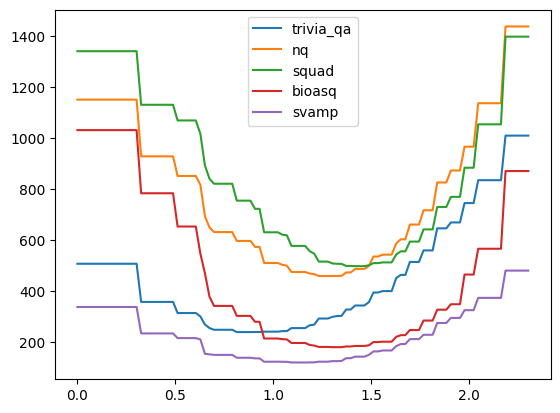

In [50]:
# Binarize SE by best split
for D in Ds:
    split = best_split(D.entropy, D.name)
    plt.legend()
    D.b_entropy = binarize_entropy(D.entropy, split)
    print(f"Dummy accuracy for {D.name}: {max(torch.mean(D.b_entropy).item(), 1-torch.mean(D.b_entropy).item()):.4f}")

### Use linear probes to predict Binarized SE

In [101]:
for D in Ds:
    
    # TBG
    X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(D.tbg_dataset, D.b_entropy, D.total_size)
    tb_accs = []
    tb_aucs = []
    
    for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
        print(f"Training on {D.name}-TBG {i+1}/{len(X_trains)}")
        model = LogisticRegression()
        sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on {D.name}-TBG {i+1} layer")
        test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
        tb_accs.append(test_acc)
        tb_aucs.append(test_auc)

    D.tb_accs = tb_accs
    D.tb_aucs = tb_aucs

    # SLT
    X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(D.slt_dataset, D.b_entropy, D.total_size)
    sb_accs = []
    sb_aucs = []
    sb_models = []
    
    for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
        print(f"Training on {D.name}-SLT {i+1}/{len(X_trains)}")
        model = LogisticRegression()
        sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on {D.name}-SLT {i+1} layer")
        test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
        sb_accs.append(test_acc)
        sb_aucs.append(test_auc)
        sb_models.append(model)

    D.sb_accs = sb_accs
    D.sb_aucs = sb_aucs
    D.sb_models = sb_models
    
    plot_metrics([tb_aucs, sb_aucs], ['TBG Binarized SE', 'SLT Binarized SE'], f'AUROC on {D.name}')

Training on trivia_qa-SLT 1/33
Validation Accuracy: 0.6278, AUROC: 0.5000
Training Loss: 0.6738, Validation Loss: 0.6620
Test Loss: 0.6730, Test Accuracy: 0.6000, AUROC: 0.5000
Training on trivia_qa-SLT 2/33
Validation Accuracy: 0.6278, AUROC: 0.6346
Training Loss: 0.6652, Validation Loss: 0.6529
Test Loss: 0.6682, Test Accuracy: 0.6050, AUROC: 0.5642
Training on trivia_qa-SLT 3/33
Validation Accuracy: 0.6361, AUROC: 0.5926
Training Loss: 0.6573, Validation Loss: 0.6511
Test Loss: 0.6658, Test Accuracy: 0.6050, AUROC: 0.5641
Training on trivia_qa-SLT 4/33
Validation Accuracy: 0.6472, AUROC: 0.6322
Training Loss: 0.6387, Validation Loss: 0.6368
Test Loss: 0.6532, Test Accuracy: 0.6200, AUROC: 0.6090
Training on trivia_qa-SLT 5/33
Validation Accuracy: 0.6417, AUROC: 0.6540
Training Loss: 0.6210, Validation Loss: 0.6259
Test Loss: 0.6361, Test Accuracy: 0.6600, AUROC: 0.6509
Training on trivia_qa-SLT 6/33
Validation Accuracy: 0.6639, AUROC: 0.6959
Training Loss: 0.5736, Validation Loss: 0

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7111, AUROC: 0.7431
Training Loss: 0.4124, Validation Loss: 0.5817
Test Loss: 0.5744, Test Accuracy: 0.7100, AUROC: 0.7501
Training on trivia_qa-SLT 10/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7306, AUROC: 0.7744
Training Loss: 0.3566, Validation Loss: 0.5555
Test Loss: 0.5413, Test Accuracy: 0.7050, AUROC: 0.7809
Training on trivia_qa-SLT 11/33


...

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.8389, AUROC: 0.9028
Training Loss: 0.0136, Validation Loss: 0.6448
Test Loss: 0.9483, Test Accuracy: 0.8000, AUROC: 0.8527
Training on svamp-SLT 32/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.8444, AUROC: 0.8985
Training Loss: 0.0123, Validation Loss: 0.7008
Test Loss: 1.0735, Test Accuracy: 0.7900, AUROC: 0.8442
Training on svamp-SLT 33/33
Validation Accuracy: 0.8389, AUROC: 0.9012
Training Loss: 0.0200, Validation Loss: 0.5956
Test Loss: 0.8640, Test Accuracy: 0.8100, AUROC: 0.8548


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


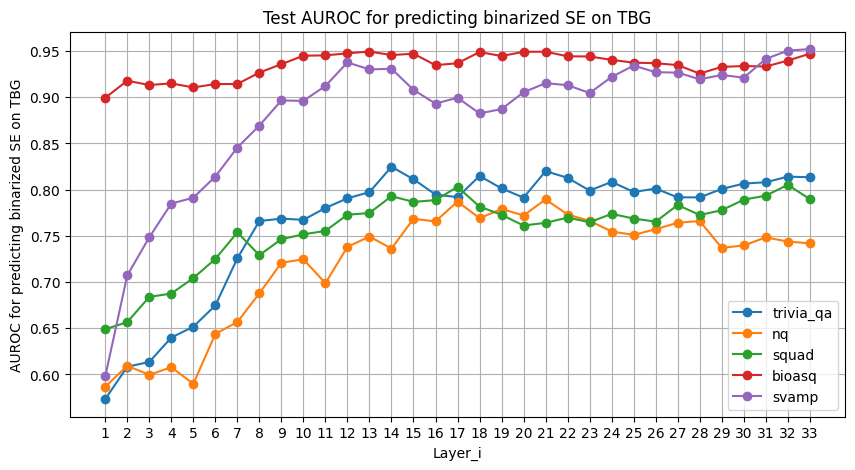

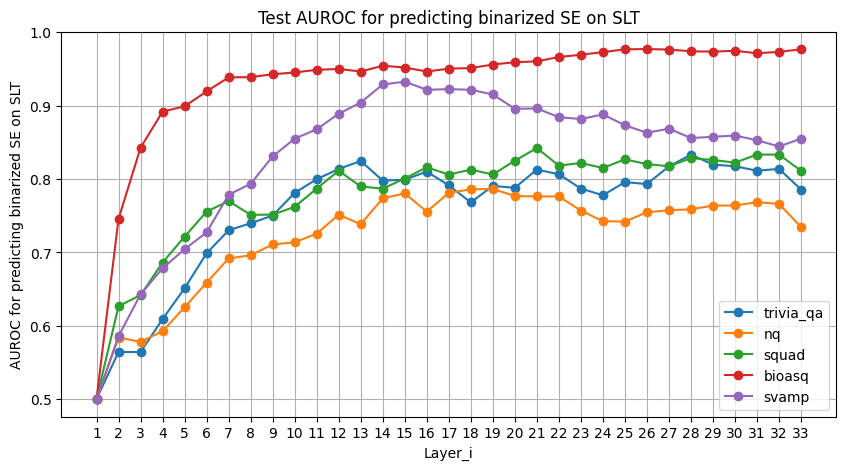

In [77]:
# Plot test AUROC curves for all on predicting binarized SE
plot_metrics([D.tb_aucs for D in Ds], [f"{D.name}" for D in Ds], f'AUROC for predicting binarized SE on TBG')
plot_metrics([D.sb_aucs for D in Ds], [f"{D.name}" for D in Ds], f'AUROC for predicting binarized SE on SLT')

In [71]:
# Report best metrics
best_metric([D.tb_aucs for D in Ds], ds=[[D.name]*2 for D in Ds])
best_metric([D.sb_aucs for D in Ds], "SLT", ds=[[D.name]*2 for D in Ds])

TBG: max AUROC for LR trained on trivia_qa's Binarized SE and
	 tested on trivia_qa's Binarized SE:
		 - 0.8247 at 14 layer
TBG: max AUROC for LR trained on nq's Binarized SE and
	 tested on nq's Binarized SE:
		 - 0.7893 at 21 layer
TBG: max AUROC for LR trained on squad's Binarized SE and
	 tested on squad's Binarized SE:
		 - 0.8051 at 32 layer
TBG: max AUROC for LR trained on bioasq's Binarized SE and
	 tested on bioasq's Binarized SE:
		 - 0.9494 at 13 layer
TBG: max AUROC for LR trained on svamp's Binarized SE and
	 tested on svamp's Binarized SE:
		 - 0.9520 at 33 layer
SLT: max AUROC for LR trained on trivia_qa's Binarized SE and
	 tested on trivia_qa's Binarized SE:
		 - 0.8330 at 28 layer
SLT: max AUROC for LR trained on nq's Binarized SE and
	 tested on nq's Binarized SE:
		 - 0.7863 at 19 layer
SLT: max AUROC for LR trained on squad's Binarized SE and
	 tested on squad's Binarized SE:
		 - 0.8421 at 21 layer
SLT: max AUROC for LR trained on bioasq's Binarized SE and
	 teste

### Use linear probes to predict Accuracy

In [100]:
for D in Ds:
    
    # TBG
    X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(D.tbg_dataset, D.accuracies, D.total_size)
    ta_accs = []
    ta_aucs = []
    
    for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
        print(f"Training on {D.name}-TBG {i+1}/{len(X_trains)}")
        model = LogisticRegression()
        sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on {D.name}-TBG {i+1} layer")
        test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
        ta_accs.append(test_acc)
        ta_aucs.append(test_auc)

    D.ta_accs = ta_accs
    D.ta_aucs = ta_aucs

    # SLT
    X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(D.slt_dataset, D.accuracies, D.total_size)
    sa_accs = []
    sa_aucs = []
    sa_models = []
    
    for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
        print(f"Training on {D.name}-SLT {i+1}/{len(X_trains)}")
        model = LogisticRegression()
        sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on {D.name}-SLT {i+1} layer")
        test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
        sa_accs.append(test_acc)
        sa_aucs.append(test_auc)
        sa_models.append(model)

    D.sa_accs = sa_accs
    D.sa_aucs = sa_aucs
    D.sa_models = sa_models
    
    plot_metrics([ta_aucs, sa_aucs], ['TBG for Predicting Accuracy', 'SLT for Predicting Accuracy'], f'AUROC on {D.name}')

Training on trivia_qa-SLT 1/33
Validation Accuracy: 0.6750, AUROC: 0.5000
Training Loss: 0.6500, Validation Loss: 0.6325
Test Loss: 0.6625, Test Accuracy: 0.6250, AUROC: 0.5000
Training on trivia_qa-SLT 2/33
Validation Accuracy: 0.6750, AUROC: 0.5260
Training Loss: 0.6418, Validation Loss: 0.6296
Test Loss: 0.6586, Test Accuracy: 0.6250, AUROC: 0.5854
Training on trivia_qa-SLT 3/33
Validation Accuracy: 0.6750, AUROC: 0.5365
Training Loss: 0.6363, Validation Loss: 0.6278
Test Loss: 0.6569, Test Accuracy: 0.6250, AUROC: 0.5854
Training on trivia_qa-SLT 4/33
Validation Accuracy: 0.6806, AUROC: 0.5851
Training Loss: 0.6211, Validation Loss: 0.6200
Test Loss: 0.6554, Test Accuracy: 0.6200, AUROC: 0.5707
Training on trivia_qa-SLT 5/33
Validation Accuracy: 0.6833, AUROC: 0.6016
Training Loss: 0.6086, Validation Loss: 0.6144
Test Loss: 0.6486, Test Accuracy: 0.6300, AUROC: 0.5939
Training on trivia_qa-SLT 6/33
Validation Accuracy: 0.6861, AUROC: 0.6098
Training Loss: 0.5703, Validation Loss: 0

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6667, AUROC: 0.6430
Training Loss: 0.5342, Validation Loss: 0.6019
Test Loss: 0.6203, Test Accuracy: 0.6800, AUROC: 0.6640
Training on trivia_qa-SLT 8/33
Validation Accuracy: 0.6778, AUROC: 0.6666
Training Loss: 0.4737, Validation Loss: 0.5984
Test Loss: 0.6193, Test Accuracy: 0.6700, AUROC: 0.6729
Training on trivia_qa-SLT 9/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6944, AUROC: 0.6943
Training Loss: 0.4289, Validation Loss: 0.5838
Test Loss: 0.5890, Test Accuracy: 0.6800, AUROC: 0.7126
Training on trivia_qa-SLT 10/33


...

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6944, AUROC: 0.7678
Training Loss: 0.0172, Validation Loss: 1.4452
Test Loss: 1.1832, Test Accuracy: 0.7300, AUROC: 0.8163
Training on svamp-SLT 32/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7167, AUROC: 0.7785
Training Loss: 0.0259, Validation Loss: 1.5797
Test Loss: 1.6357, Test Accuracy: 0.7200, AUROC: 0.7935
Training on svamp-SLT 33/33
Validation Accuracy: 0.7389, AUROC: 0.7710
Training Loss: 0.0665, Validation Loss: 1.5451
Test Loss: 1.6574, Test Accuracy: 0.6800, AUROC: 0.7647


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


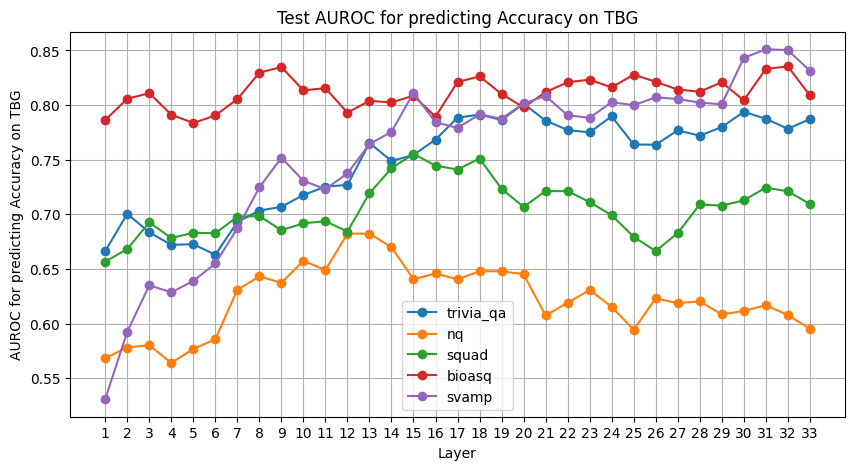

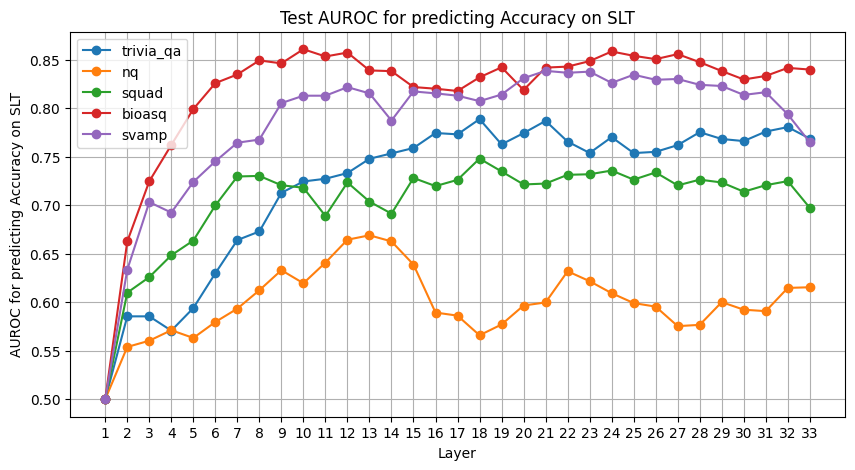

In [221]:
# Plot test AUROC curves for all on predicting Accuracy
plot_metrics([D.ta_aucs for D in Ds], [f"{D.name}" for D in Ds], f'AUROC for predicting Accuracy on TBG')
plot_metrics([D.sa_aucs for D in Ds], [f"{D.name}" for D in Ds], f'AUROC for predicting Accuracy on SLT')

In [76]:
# Report best metrics
best_metric([D.ta_aucs for D in Ds], train="Accuracy", test="Accuracy", ds=[[D.name]*2 for D in Ds])
best_metric([D.sa_aucs for D in Ds], token="SLT", train="Accuracy", test="Accuracy", ds=[[D.name]*2 for D in Ds])

TBG: max AUROC for LR trained on trivia_qa's Accuracy and
	 tested on trivia_qa's Accuracy:
		 - 0.8013 at 20 layer
TBG: max AUROC for LR trained on nq's Accuracy and
	 tested on nq's Accuracy:
		 - 0.6824 at 13 layer
TBG: max AUROC for LR trained on squad's Accuracy and
	 tested on squad's Accuracy:
		 - 0.7552 at 15 layer
TBG: max AUROC for LR trained on bioasq's Accuracy and
	 tested on bioasq's Accuracy:
		 - 0.8355 at 32 layer
TBG: max AUROC for LR trained on svamp's Accuracy and
	 tested on svamp's Accuracy:
		 - 0.8511 at 31 layer
SLT: max AUROC for LR trained on trivia_qa's Accuracy and
	 tested on trivia_qa's Accuracy:
		 - 0.7886 at 18 layer
SLT: max AUROC for LR trained on nq's Accuracy and
	 tested on nq's Accuracy:
		 - 0.6689 at 13 layer
SLT: max AUROC for LR trained on squad's Accuracy and
	 tested on squad's Accuracy:
		 - 0.7479 at 18 layer
SLT: max AUROC for LR trained on bioasq's Accuracy and
	 tested on bioasq's Accuracy:
		 - 0.8606 at 10 layer
SLT: max AUROC for L

### Use linear probe trained on Binarized SE to predict Accuracy

Testing on trivia_qa-TBG 1/33
Test Loss: 0.6548, Test Accuracy: 0.6150, AUROC: 0.5627
Testing on trivia_qa-TBG 2/33
Test Loss: 0.6653, Test Accuracy: 0.5800, AUROC: 0.5558
Testing on trivia_qa-TBG 3/33
Test Loss: 0.6846, Test Accuracy: 0.6150, AUROC: 0.5892
Testing on trivia_qa-TBG 4/33
Test Loss: 0.6939, Test Accuracy: 0.6300, AUROC: 0.6063
Testing on trivia_qa-TBG 5/33
Test Loss: 0.7187, Test Accuracy: 0.6250, AUROC: 0.6121
Testing on trivia_qa-TBG 6/33
Test Loss: 0.7456, Test Accuracy: 0.6450, AUROC: 0.6207
Testing on trivia_qa-TBG 7/33
Test Loss: 0.7259, Test Accuracy: 0.6650, AUROC: 0.6683
Testing on trivia_qa-TBG 8/33
Test Loss: 0.7420, Test Accuracy: 0.6950, AUROC: 0.6759
Testing on trivia_qa-TBG 9/33
Test Loss: 0.8066, Test Accuracy: 0.6850, AUROC: 0.6736
Testing on trivia_qa-TBG 10/33
Test Loss: 0.8870, Test Accuracy: 0.6700, AUROC: 0.6746
Testing on trivia_qa-TBG 11/33
Test Loss: 0.8871, Test Accuracy: 0.6650, AUROC: 0.6948
Testing on trivia_qa-TBG 12/33
Test Loss: 1.0223, Te

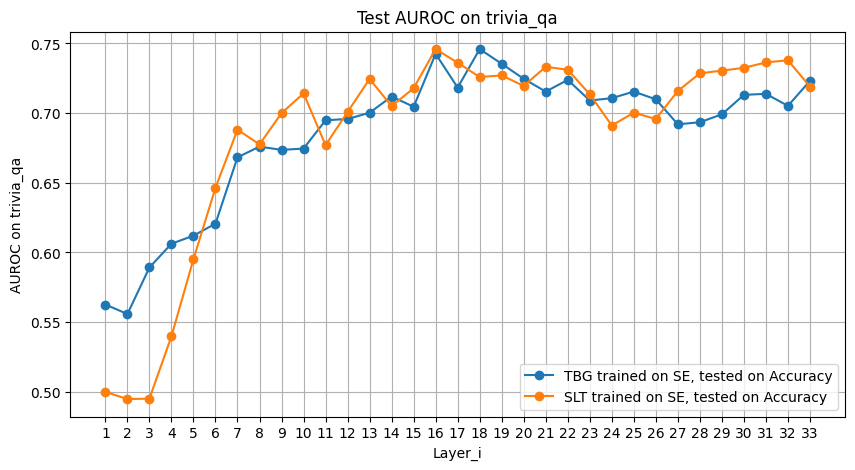

Testing on nq-TBG 1/33
Test Loss: 0.6943, Test Accuracy: 0.5956, AUROC: 0.5077
Testing on nq-TBG 2/33
Test Loss: 0.7040, Test Accuracy: 0.5817, AUROC: 0.5213
Testing on nq-TBG 3/33
Test Loss: 0.7301, Test Accuracy: 0.5512, AUROC: 0.5316
Testing on nq-TBG 4/33
Test Loss: 0.7736, Test Accuracy: 0.5734, AUROC: 0.5301
Testing on nq-TBG 5/33
Test Loss: 0.8192, Test Accuracy: 0.5512, AUROC: 0.5262
Testing on nq-TBG 6/33
Test Loss: 0.8587, Test Accuracy: 0.5928, AUROC: 0.5587
Testing on nq-TBG 7/33
Test Loss: 0.8763, Test Accuracy: 0.6094, AUROC: 0.5883
Testing on nq-TBG 8/33
Test Loss: 0.9202, Test Accuracy: 0.6094, AUROC: 0.6035
Testing on nq-TBG 9/33
Test Loss: 0.9906, Test Accuracy: 0.6094, AUROC: 0.6013
Testing on nq-TBG 10/33
Test Loss: 1.0776, Test Accuracy: 0.6039, AUROC: 0.6151
Testing on nq-TBG 11/33
Test Loss: 1.2348, Test Accuracy: 0.5789, AUROC: 0.5997
Testing on nq-TBG 12/33
Test Loss: 1.2114, Test Accuracy: 0.6205, AUROC: 0.6621
Testing on nq-TBG 13/33
Test Loss: 1.2653, Test A

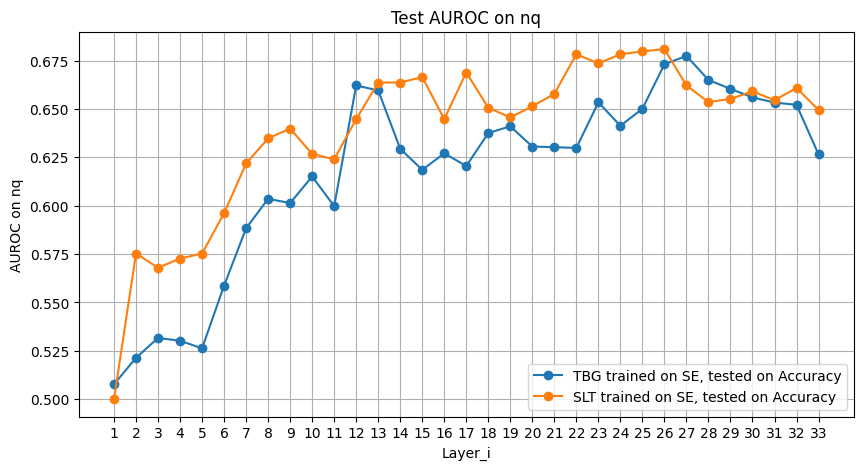

Testing on squad-TBG 1/33
Test Loss: 0.5221, Test Accuracy: 0.7720, AUROC: 0.6400
Testing on squad-TBG 2/33
Test Loss: 0.5179, Test Accuracy: 0.7540, AUROC: 0.6557
Testing on squad-TBG 3/33
Test Loss: 0.5012, Test Accuracy: 0.7620, AUROC: 0.7023
Testing on squad-TBG 4/33
Test Loss: 0.5310, Test Accuracy: 0.7500, AUROC: 0.6813
Testing on squad-TBG 5/33
Test Loss: 0.5478, Test Accuracy: 0.7360, AUROC: 0.6863
Testing on squad-TBG 6/33
Test Loss: 0.5774, Test Accuracy: 0.7460, AUROC: 0.6949
Testing on squad-TBG 7/33
Test Loss: 0.5972, Test Accuracy: 0.7420, AUROC: 0.7087
Testing on squad-TBG 8/33
Test Loss: 0.7202, Test Accuracy: 0.7260, AUROC: 0.6903
Testing on squad-TBG 9/33
Test Loss: 0.7939, Test Accuracy: 0.7200, AUROC: 0.6866
Testing on squad-TBG 10/33
Test Loss: 0.8012, Test Accuracy: 0.7280, AUROC: 0.6906
Testing on squad-TBG 11/33
Test Loss: 0.8870, Test Accuracy: 0.7140, AUROC: 0.6934
Testing on squad-TBG 12/33
Test Loss: 0.9865, Test Accuracy: 0.7040, AUROC: 0.7026
Testing on sq

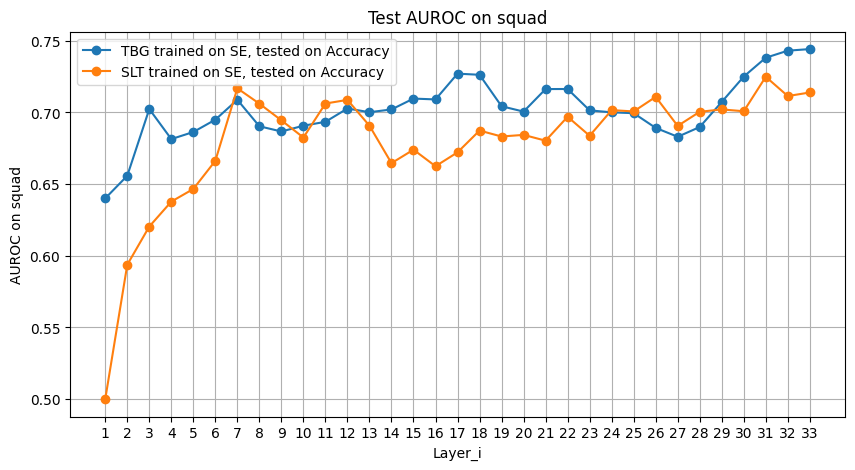

Testing on bioasq-TBG 1/33
Test Loss: 0.5552, Test Accuracy: 0.7850, AUROC: 0.8036
Testing on bioasq-TBG 2/33
Test Loss: 0.5641, Test Accuracy: 0.7850, AUROC: 0.8249
Testing on bioasq-TBG 3/33
Test Loss: 0.5953, Test Accuracy: 0.7900, AUROC: 0.8151
Testing on bioasq-TBG 4/33
Test Loss: 0.6044, Test Accuracy: 0.7850, AUROC: 0.8181
Testing on bioasq-TBG 5/33
Test Loss: 0.6453, Test Accuracy: 0.7850, AUROC: 0.8133
Testing on bioasq-TBG 6/33
Test Loss: 0.6888, Test Accuracy: 0.7850, AUROC: 0.8017
Testing on bioasq-TBG 7/33
Test Loss: 0.7516, Test Accuracy: 0.7800, AUROC: 0.7987
Testing on bioasq-TBG 8/33
Test Loss: 0.8252, Test Accuracy: 0.7850, AUROC: 0.7977
Testing on bioasq-TBG 9/33
Test Loss: 0.8554, Test Accuracy: 0.7750, AUROC: 0.8152
Testing on bioasq-TBG 10/33
Test Loss: 0.9178, Test Accuracy: 0.7800, AUROC: 0.8032
Testing on bioasq-TBG 11/33
Test Loss: 1.0033, Test Accuracy: 0.7850, AUROC: 0.8071
Testing on bioasq-TBG 12/33
Test Loss: 1.1579, Test Accuracy: 0.7650, AUROC: 0.7987
T

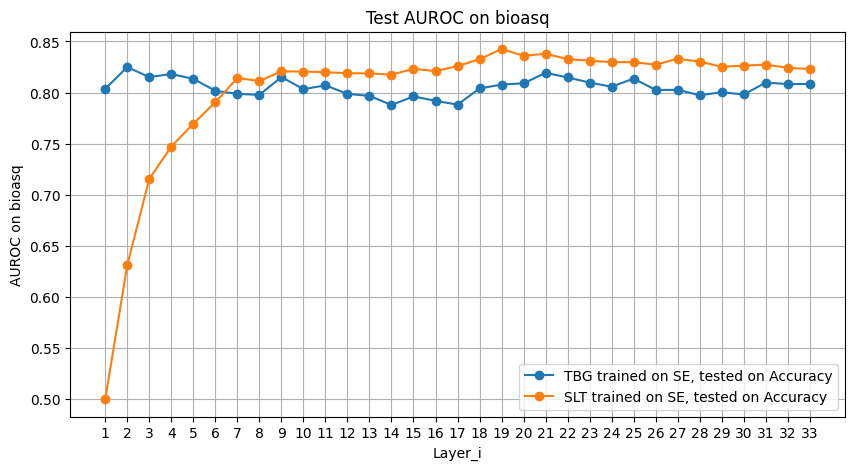

Testing on svamp-TBG 1/33
Test Loss: 0.7539, Test Accuracy: 0.4900, AUROC: 0.5392
Testing on svamp-TBG 2/33
Test Loss: 0.7336, Test Accuracy: 0.5000, AUROC: 0.6198
Testing on svamp-TBG 3/33
Test Loss: 0.7154, Test Accuracy: 0.5200, AUROC: 0.6283
Testing on svamp-TBG 4/33
Test Loss: 0.7171, Test Accuracy: 0.5400, AUROC: 0.6242
Testing on svamp-TBG 5/33
Test Loss: 0.7182, Test Accuracy: 0.5000, AUROC: 0.6379
Testing on svamp-TBG 6/33
Test Loss: 0.7041, Test Accuracy: 0.5400, AUROC: 0.6563
Testing on svamp-TBG 7/33
Test Loss: 0.7172, Test Accuracy: 0.5900, AUROC: 0.6803
Testing on svamp-TBG 8/33
Test Loss: 0.7136, Test Accuracy: 0.6300, AUROC: 0.7059
Testing on svamp-TBG 9/33
Test Loss: 0.6864, Test Accuracy: 0.6500, AUROC: 0.7451
Testing on svamp-TBG 10/33
Test Loss: 0.7592, Test Accuracy: 0.6400, AUROC: 0.7275
Testing on svamp-TBG 11/33
Test Loss: 0.8685, Test Accuracy: 0.6200, AUROC: 0.7091
Testing on svamp-TBG 12/33
Test Loss: 0.9066, Test Accuracy: 0.6200, AUROC: 0.7411
Testing on sv

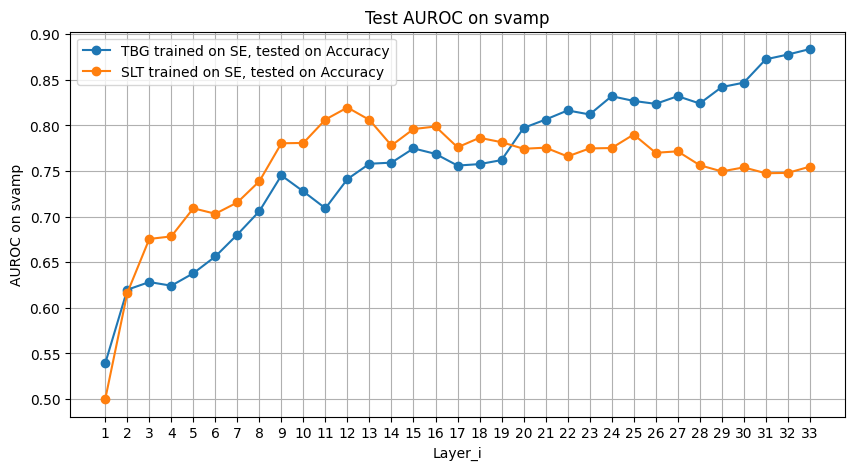

In [90]:
for D in Ds:
    r_acc = 1 - D.accuracies
    
    # TBG
    # X_trains, X_vals, _, y_trains, y_vals, _ = create_Xs_and_ys(D.tbg_dataset, D.b_entropy, D.total_size)
    _, _, X_tests, _, _, y_tests = create_Xs_and_ys(D.tbg_dataset, r_acc, D.total_size) 
    tab_accs = []
    tab_aucs = []
    
    for i, (X_test, y_test) in enumerate(zip(X_tests, y_tests)):
        print(f"Testing on {D.name}-TBG {i+1}/{len(X_tests)}")
        model = D.tb_models[i]
        test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
        tab_accs.append(test_acc)
        tab_aucs.append(test_auc)

    D.tab_accs = tab_accs
    D.tab_aucs = tab_aucs

    # SLT
    # X_trains, X_vals, _, y_trains, y_vals, _ = create_Xs_and_ys(D.slt_dataset, D.b_entropy, D.total_size)
    _, _, X_tests, _, _, y_tests = create_Xs_and_ys(D.slt_dataset, r_acc, D.total_size)     
    sab_accs = []
    sab_aucs = []
    
    for i, (X_test, y_test) in enumerate(zip(X_tests, y_tests)):
        print(f"Testing on {D.name}-SLT {i+1}/{len(X_tests)}")
        model = D.sb_models[i]
        test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
        sab_accs.append(test_acc)
        sab_aucs.append(test_auc)

    D.sab_accs = sab_accs
    D.sab_aucs = sab_aucs
    
    plot_metrics([tab_aucs, sab_aucs], ['TBG trained on SE, tested on Accuracy', 'SLT trained on SE, tested on Accuracy'], f'AUROC on {D.name}')

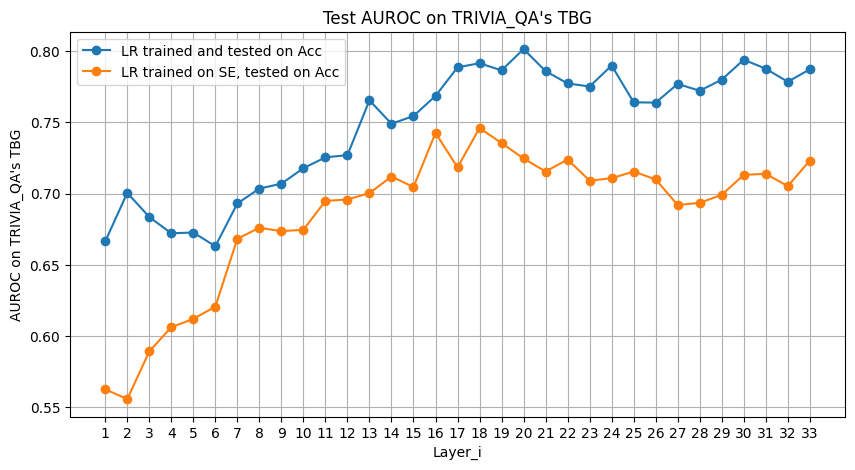

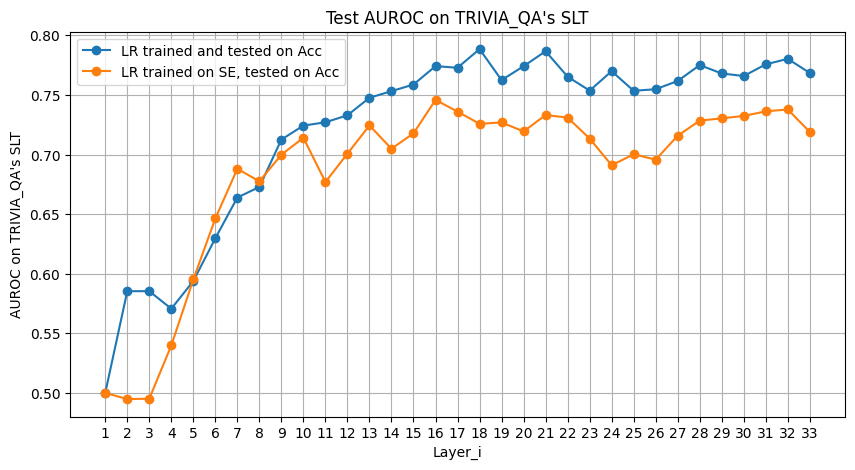

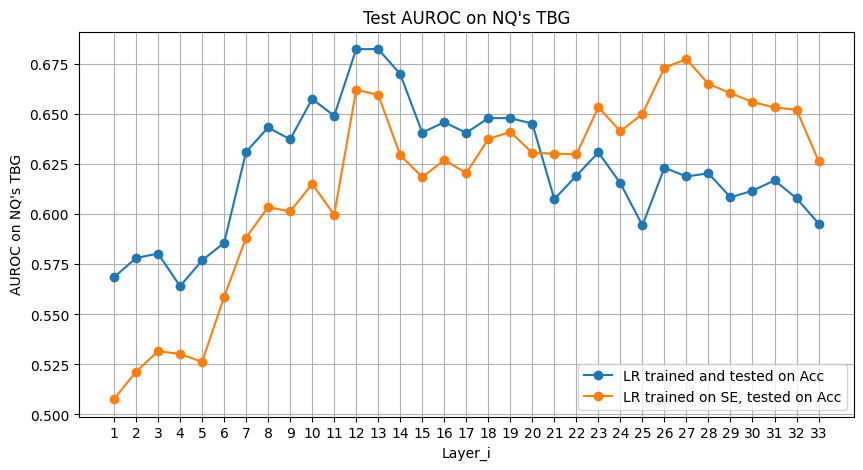

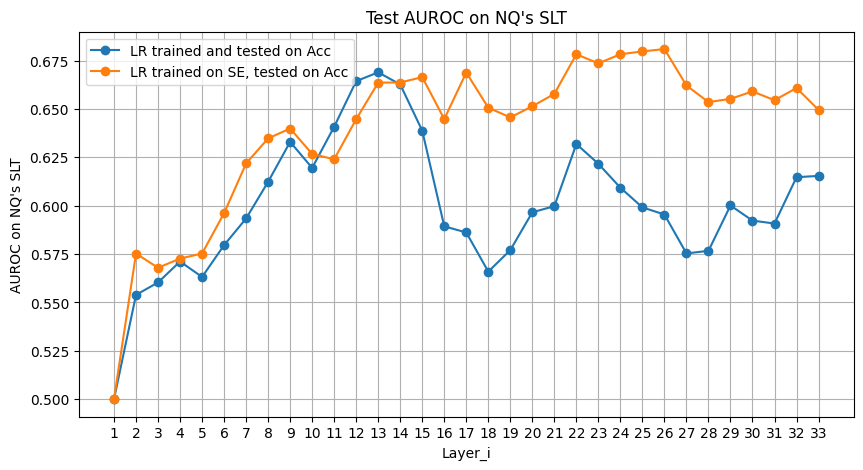

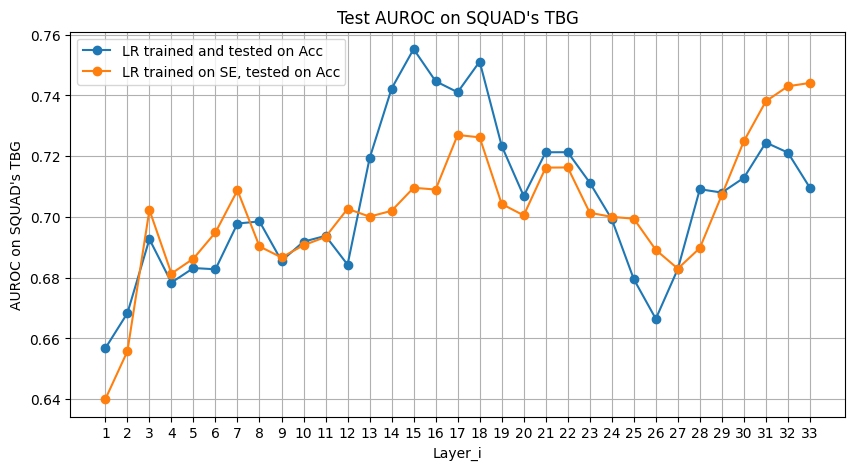

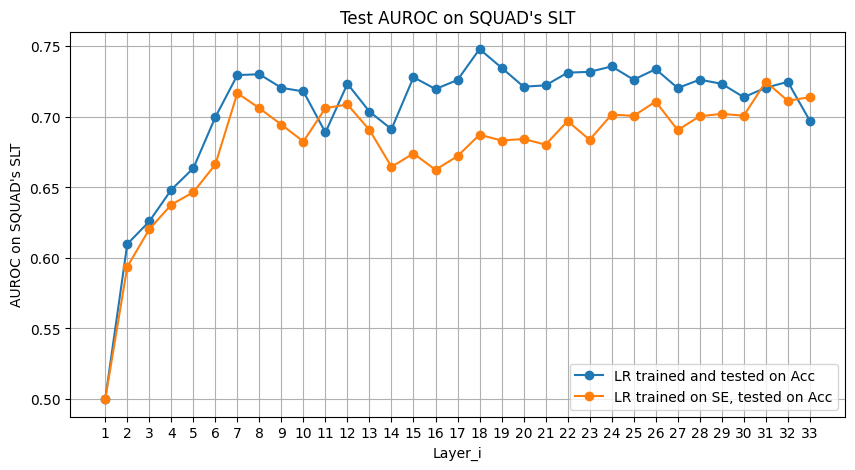

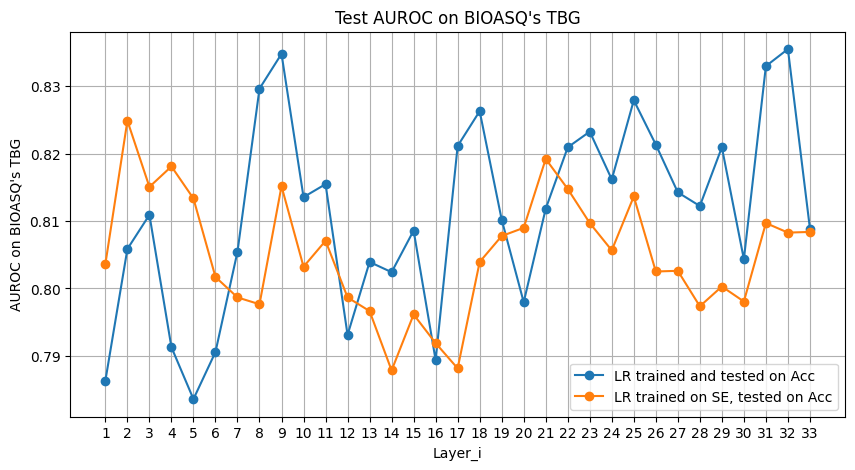

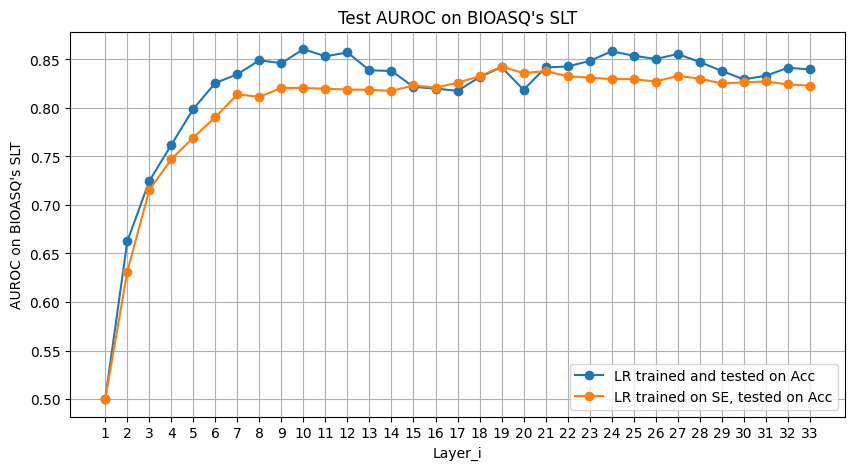

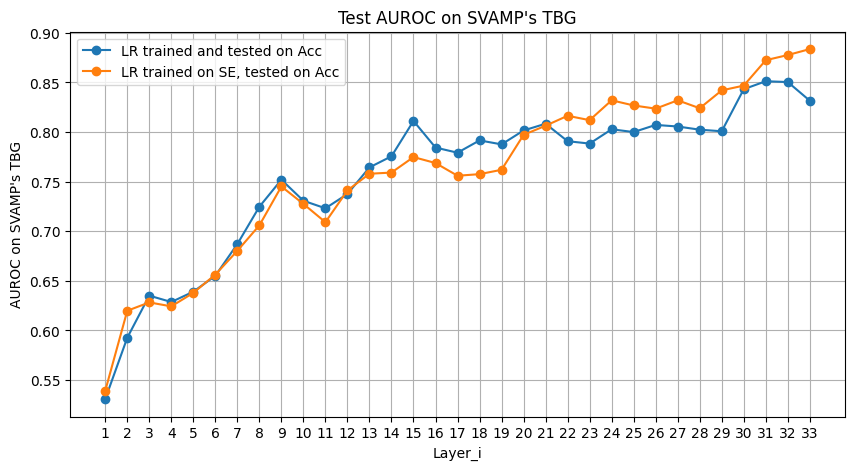

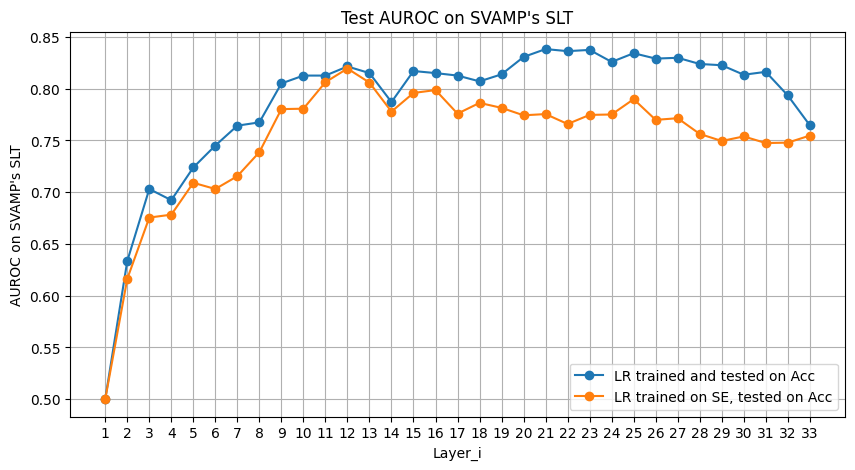

In [92]:
for D in Ds:
    plot_metrics([D.ta_aucs, D.tab_aucs], ["LR trained and tested on Acc", "LR trained on SE, tested on Acc"], f"AUROC on {D.name.upper()}'s TBG")
    plot_metrics([D.sa_aucs, D.sab_aucs], ["LR trained and tested on Acc", "LR trained on SE, tested on Acc"], f"AUROC on {D.name.upper()}'s SLT")

In [93]:
for D in Ds:
    print(f"On {D.name.upper()}:")
    best_metric([D.tab_aucs], token="TBG", train="SE", test="Accuracy", ds=[[D.name.upper()]*2])
    best_metric([D.ta_aucs], token="TBG", train="Accuracy", test="Accuracy", ds=[[D.name.upper()]*2])
    best_metric([D.sab_aucs], token="SLT", train="SE", test="Accuracy", ds=[[D.name.upper()]*2])
    best_metric([D.sa_aucs], token="SLT", train="Accuracy", test="Accuracy", ds=[[D.name.upper()]*2])

On TRIVIA_QA:
TBG: max AUROC for LR trained on TRIVIA_QA's SE and
	 tested on TRIVIA_QA's Accuracy:
		 - 0.7459 at 18 layer
TBG: max AUROC for LR trained on TRIVIA_QA's Accuracy and
	 tested on TRIVIA_QA's Accuracy:
		 - 0.8013 at 20 layer
SLT: max AUROC for LR trained on TRIVIA_QA's SE and
	 tested on TRIVIA_QA's Accuracy:
		 - 0.7459 at 16 layer
SLT: max AUROC for LR trained on TRIVIA_QA's Accuracy and
	 tested on TRIVIA_QA's Accuracy:
		 - 0.7886 at 18 layer
On NQ:
TBG: max AUROC for LR trained on NQ's SE and
	 tested on NQ's Accuracy:
		 - 0.6774 at 27 layer
TBG: max AUROC for LR trained on NQ's Accuracy and
	 tested on NQ's Accuracy:
		 - 0.6824 at 13 layer
SLT: max AUROC for LR trained on NQ's SE and
	 tested on NQ's Accuracy:
		 - 0.6809 at 26 layer
SLT: max AUROC for LR trained on NQ's Accuracy and
	 tested on NQ's Accuracy:
		 - 0.6689 at 13 layer
On SQUAD:
TBG: max AUROC for LR trained on SQUAD's SE and
	 tested on SQUAD's Accuracy:
		 - 0.7441 at 33 layer
TBG: max AUROC for 

## Generalize probes trained on 4 datasets' SE to the other's SE/Acc prediction

We will test probes **trained** on the union of different D's SLT SE.

In [1]:
# Utility to merge X's and y's (assume SLT)
def merge_Xs_and_ys(Ds, other_ids, attribute='b_entropy'):
    """Ds are the collection of dataset instances; other_ids are the other four datasets"""
    print("Merging datasets")
    all_Xs_and_ys = ()
    for id_ in other_ids:
        D = Ds[id_]
        # X_trains, X_vals, X_tests, y_trains, y_vals, y_tests
        Xs_and_ys = create_Xs_and_ys(D.slt_dataset, getattr(D, attribute), D.total_size)
        all_Xs_and_ys += (Xs_and_ys,)
    
    # merge xs and ys by splits
    all_splits = list(zip(*all_Xs_and_ys))
    results = ()
    for splits in all_splits:
        all_layers = [[] for _ in range(len(splits[0]))]
        for split in splits:
            for i, layer in enumerate(split):
                all_layers[i].append(layer)
        results += ([np.concatenate(l, axis=0) for l in all_layers],)

    print(f"Dummy test accuracy: {max(np.mean(results[-1]), 1-np.mean(results[-1])):.4f}")
    return results            

In [141]:
# Test merge_Xs_and_ys
# results = merge_Xs_and_ys(Ds, [0,1,2])
# len(results), len(results[0]), results[5][0].shape

Training on datasets [1, 2, 3, 4]'s SLT-Acc to predict trivia_qa's SLT-Acc
Merging datasets
Dummy test accuracy: 0.6563307344913483
Training on SLT-Acc 1/33 - ['nq', 'squad', 'bioasq', 'svamp']
Validation Accuracy: 0.6651, AUROC: 0.5000
Training Loss: 0.6349, Validation Loss: 0.6376
Test Loss: 0.6438, Test Accuracy: 0.6563, AUROC: 0.5000
Training on SLT-Acc 2/33 - ['nq', 'squad', 'bioasq', 'svamp']
Validation Accuracy: 0.6646, AUROC: 0.6163
Training Loss: 0.6170, Validation Loss: 0.6210
Test Loss: 0.6226, Test Accuracy: 0.6563, AUROC: 0.6339
Training on SLT-Acc 3/33 - ['nq', 'squad', 'bioasq', 'svamp']
Validation Accuracy: 0.6656, AUROC: 0.6261
Training Loss: 0.6115, Validation Loss: 0.6161
Test Loss: 0.6141, Test Accuracy: 0.6563, AUROC: 0.6520
Training on SLT-Acc 4/33 - ['nq', 'squad', 'bioasq', 'svamp']
Validation Accuracy: 0.6852, AUROC: 0.6488
Training Loss: 0.5969, Validation Loss: 0.6066
Test Loss: 0.6012, Test Accuracy: 0.6839, AUROC: 0.6775
Training on SLT-Acc 5/33 - ['nq', 's

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6981, AUROC: 0.6696
Training Loss: 0.5821, Validation Loss: 0.5959
Test Loss: 0.5876, Test Accuracy: 0.7071, AUROC: 0.6998
Training on SLT-Acc 6/33 - ['nq', 'squad', 'bioasq', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7096, AUROC: 0.6963
Training Loss: 0.5562, Validation Loss: 0.5822
Test Loss: 0.5725, Test Accuracy: 0.7054, AUROC: 0.7242
Training on SLT-Acc 7/33 - ['nq', 'squad', 'bioasq', 'svamp']


...

Validation Accuracy: 0.6699, AUROC: 0.6804
Training Loss: 0.1100, Validation Loss: 2.7130
Test Loss: 2.6835, Test Accuracy: 0.6796, AUROC: 0.6945
Training on SLT-Acc 32/33 - ['nq', 'squad', 'bioasq', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6809, AUROC: 0.6949
Training Loss: 0.1064, Validation Loss: 2.9696
Test Loss: 3.0399, Test Accuracy: 0.6839, AUROC: 0.7012
Training on SLT-Acc 33/33 - ['nq', 'squad', 'bioasq', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6914, AUROC: 0.7082
Training Loss: 0.1999, Validation Loss: 1.3314
Test Loss: 1.4739, Test Accuracy: 0.7020, AUROC: 0.6980


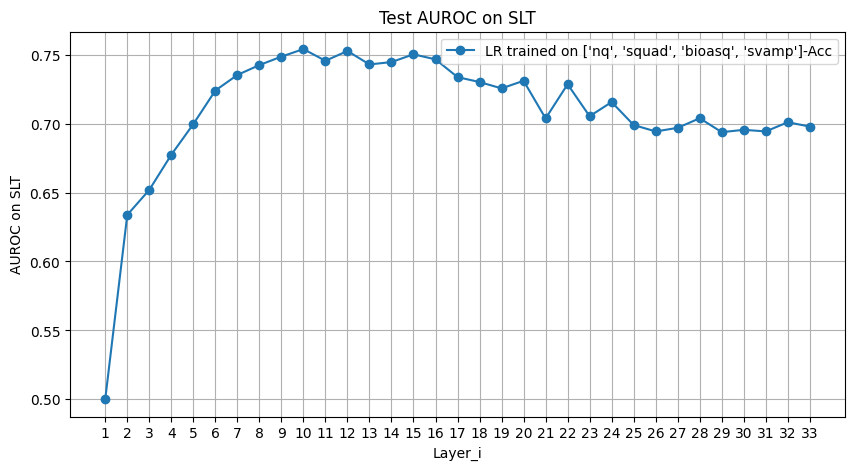

Training on datasets [0, 2, 3, 4]'s SLT-Acc to predict nq's SLT-Acc
Merging datasets
Dummy test accuracy: 0.6209999918937683
Training on SLT-Acc 1/33 - ['trivia_qa', 'squad', 'bioasq', 'svamp']
Validation Accuracy: 0.6156, AUROC: 0.5000
Training Loss: 0.6622, Validation Loss: 0.6663
Test Loss: 0.6636, Test Accuracy: 0.6210, AUROC: 0.5000
Training on SLT-Acc 2/33 - ['trivia_qa', 'squad', 'bioasq', 'svamp']
Validation Accuracy: 0.6461, AUROC: 0.6866
Training Loss: 0.6166, Validation Loss: 0.6239
Test Loss: 0.6175, Test Accuracy: 0.6530, AUROC: 0.6995
Training on SLT-Acc 3/33 - ['trivia_qa', 'squad', 'bioasq', 'svamp']
Validation Accuracy: 0.6817, AUROC: 0.7069
Training Loss: 0.5996, Validation Loss: 0.6061
Test Loss: 0.6042, Test Accuracy: 0.6580, AUROC: 0.7121
Training on SLT-Acc 4/33 - ['trivia_qa', 'squad', 'bioasq', 'svamp']
Validation Accuracy: 0.7050, AUROC: 0.7262
Training Loss: 0.5807, Validation Loss: 0.5900
Test Loss: 0.5911, Test Accuracy: 0.6890, AUROC: 0.7272
Training on SLT

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7261, AUROC: 0.7600
Training Loss: 0.5353, Validation Loss: 0.5637
Test Loss: 0.5599, Test Accuracy: 0.7180, AUROC: 0.7667
Training on SLT-Acc 7/33 - ['trivia_qa', 'squad', 'bioasq', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7250, AUROC: 0.7649
Training Loss: 0.5139, Validation Loss: 0.5603
Test Loss: 0.5439, Test Accuracy: 0.7280, AUROC: 0.7826
Training on SLT-Acc 8/33 - ['trivia_qa', 'squad', 'bioasq', 'svamp']


...

Validation Accuracy: 0.6889, AUROC: 0.7265
Training Loss: 0.0830, Validation Loss: 3.0586
Test Loss: 2.6612, Test Accuracy: 0.7180, AUROC: 0.7705
Training on SLT-Acc 32/33 - ['trivia_qa', 'squad', 'bioasq', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6922, AUROC: 0.7253
Training Loss: 0.0755, Validation Loss: 3.1612
Test Loss: 2.7324, Test Accuracy: 0.7220, AUROC: 0.7692
Training on SLT-Acc 33/33 - ['trivia_qa', 'squad', 'bioasq', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7072, AUROC: 0.7403
Training Loss: 0.1523, Validation Loss: 1.7303
Test Loss: 1.5427, Test Accuracy: 0.7140, AUROC: 0.7659


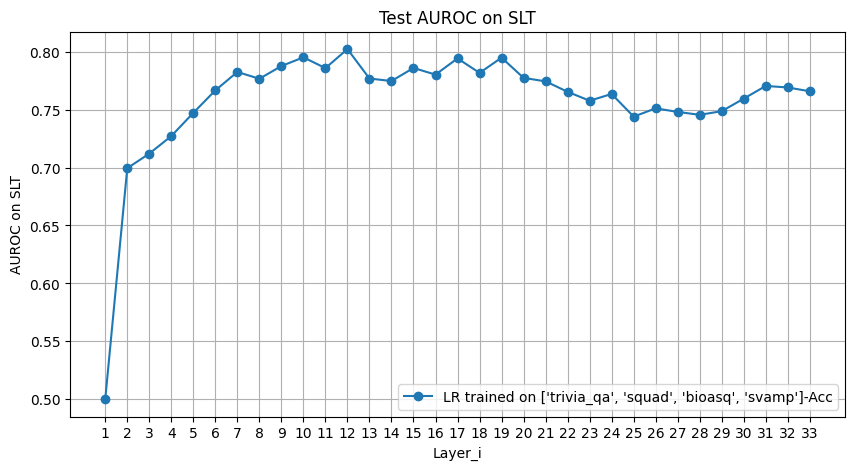

Training on datasets [0, 1, 3, 4]'s SLT-Acc to predict squad's SLT-Acc
Merging datasets
Dummy test accuracy: 0.5238095223903656
Training on SLT-Acc 1/33 - ['trivia_qa', 'nq', 'bioasq', 'svamp']
Validation Accuracy: 0.5290, AUROC: 0.5000
Training Loss: 0.6898, Validation Loss: 0.6918
Test Loss: 0.6926, Test Accuracy: 0.5238, AUROC: 0.5000
Training on SLT-Acc 2/33 - ['trivia_qa', 'nq', 'bioasq', 'svamp']
Validation Accuracy: 0.6065, AUROC: 0.6165
Training Loss: 0.6673, Validation Loss: 0.6694
Test Loss: 0.6742, Test Accuracy: 0.5796, AUROC: 0.6145
Training on SLT-Acc 3/33 - ['trivia_qa', 'nq', 'bioasq', 'svamp']
Validation Accuracy: 0.6097, AUROC: 0.6350
Training Loss: 0.6587, Validation Loss: 0.6619
Test Loss: 0.6694, Test Accuracy: 0.5854, AUROC: 0.6217
Training on SLT-Acc 4/33 - ['trivia_qa', 'nq', 'bioasq', 'svamp']
Validation Accuracy: 0.6335, AUROC: 0.6646
Training Loss: 0.6440, Validation Loss: 0.6490
Test Loss: 0.6609, Test Accuracy: 0.6167, AUROC: 0.6498
Training on SLT-Acc 5/33

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6703, AUROC: 0.7122
Training Loss: 0.5985, Validation Loss: 0.6216
Test Loss: 0.6259, Test Accuracy: 0.6562, AUROC: 0.7120
Training on SLT-Acc 7/33 - ['trivia_qa', 'nq', 'bioasq', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6626, AUROC: 0.7098
Training Loss: 0.5729, Validation Loss: 0.6221
Test Loss: 0.6114, Test Accuracy: 0.6783, AUROC: 0.7240
Training on SLT-Acc 8/33 - ['trivia_qa', 'nq', 'bioasq', 'svamp']


...

Validation Accuracy: 0.6729, AUROC: 0.7138
Training Loss: 0.0663, Validation Loss: 3.4180
Test Loss: 3.5753, Test Accuracy: 0.6609, AUROC: 0.7082
Training on SLT-Acc 32/33 - ['trivia_qa', 'nq', 'bioasq', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6594, AUROC: 0.7170
Training Loss: 0.0829, Validation Loss: 2.5596
Test Loss: 2.5874, Test Accuracy: 0.6643, AUROC: 0.7154
Training on SLT-Acc 33/33 - ['trivia_qa', 'nq', 'bioasq', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6813, AUROC: 0.7284
Training Loss: 0.1528, Validation Loss: 1.8349
Test Loss: 1.8483, Test Accuracy: 0.6655, AUROC: 0.7168


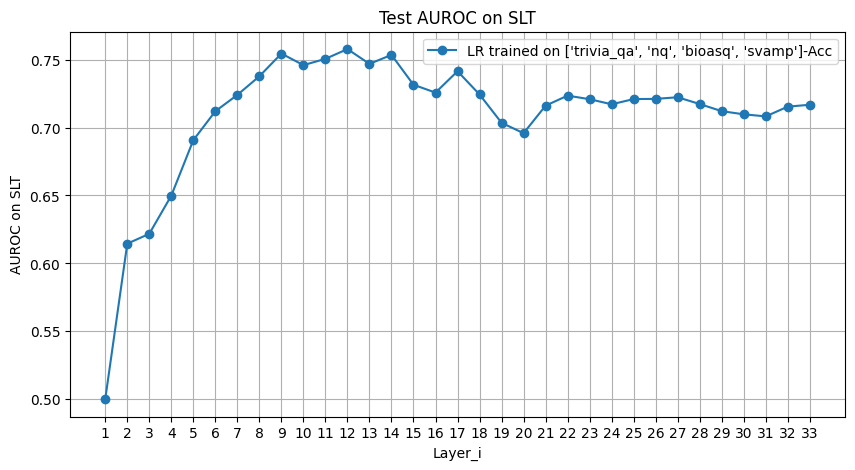

Training on datasets [0, 1, 2, 4]'s SLT-Acc to predict bioasq's SLT-Acc
Merging datasets
Dummy test accuracy: 0.6253229975700378
Training on SLT-Acc 1/33 - ['trivia_qa', 'nq', 'squad', 'svamp']
Validation Accuracy: 0.6268, AUROC: 0.5000
Training Loss: 0.6583, Validation Loss: 0.6607
Test Loss: 0.6615, Test Accuracy: 0.6253, AUROC: 0.5000
Training on SLT-Acc 2/33 - ['trivia_qa', 'nq', 'squad', 'svamp']
Validation Accuracy: 0.6598, AUROC: 0.6718
Training Loss: 0.6187, Validation Loss: 0.6233
Test Loss: 0.6216, Test Accuracy: 0.6572, AUROC: 0.6882
Training on SLT-Acc 3/33 - ['trivia_qa', 'nq', 'squad', 'svamp']
Validation Accuracy: 0.6837, AUROC: 0.6818
Training Loss: 0.6087, Validation Loss: 0.6112
Test Loss: 0.6135, Test Accuracy: 0.6581, AUROC: 0.6891
Training on SLT-Acc 4/33 - ['trivia_qa', 'nq', 'squad', 'svamp']
Validation Accuracy: 0.6847, AUROC: 0.6974
Training Loss: 0.5959, Validation Loss: 0.6002
Test Loss: 0.6026, Test Accuracy: 0.6736, AUROC: 0.7043
Training on SLT-Acc 5/33 - 

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6895, AUROC: 0.7056
Training Loss: 0.5873, Validation Loss: 0.5944
Test Loss: 0.5938, Test Accuracy: 0.6848, AUROC: 0.7156
Training on SLT-Acc 6/33 - ['trivia_qa', 'nq', 'squad', 'svamp']
Validation Accuracy: 0.7010, AUROC: 0.7238
Training Loss: 0.5616, Validation Loss: 0.5848
Test Loss: 0.5809, Test Accuracy: 0.6960, AUROC: 0.7320
Training on SLT-Acc 7/33 - ['trivia_qa', 'nq', 'squad', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6962, AUROC: 0.7210
Training Loss: 0.5432, Validation Loss: 0.5872
Test Loss: 0.5724, Test Accuracy: 0.7089, AUROC: 0.7428
Training on SLT-Acc 8/33 - ['trivia_qa', 'nq', 'squad', 'svamp']


...

Validation Accuracy: 0.6713, AUROC: 0.6975
Training Loss: 0.1029, Validation Loss: 3.5103
Test Loss: 3.5100, Test Accuracy: 0.6684, AUROC: 0.7053
Training on SLT-Acc 32/33 - ['trivia_qa', 'nq', 'squad', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6718, AUROC: 0.6962
Training Loss: 0.1152, Validation Loss: 2.6868
Test Loss: 2.5765, Test Accuracy: 0.6804, AUROC: 0.7135
Training on SLT-Acc 33/33 - ['trivia_qa', 'nq', 'squad', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6799, AUROC: 0.7104
Training Loss: 0.1864, Validation Loss: 1.5732
Test Loss: 1.5967, Test Accuracy: 0.6744, AUROC: 0.7152


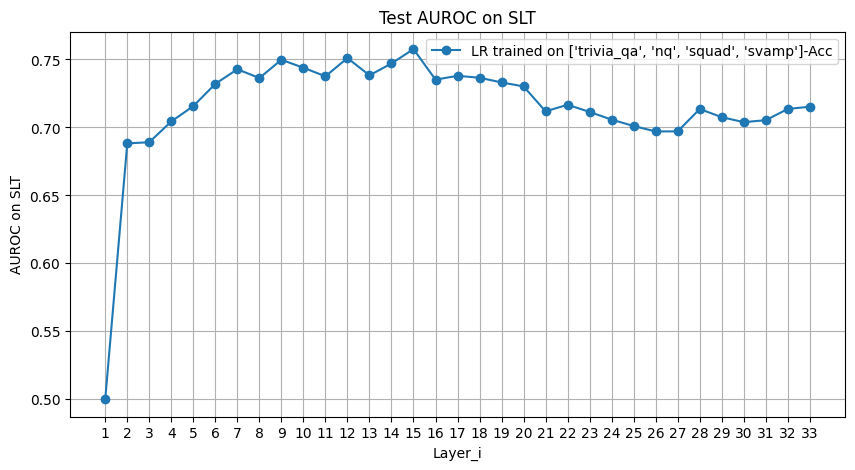

Training on datasets [0, 1, 2, 3]'s SLT-Acc to predict svamp's SLT-Acc
Merging datasets
Dummy test accuracy: 0.6249008774757385
Training on SLT-Acc 1/33 - ['trivia_qa', 'nq', 'squad', 'bioasq']
Validation Accuracy: 0.6167, AUROC: 0.5000
Training Loss: 0.6604, Validation Loss: 0.6659
Test Loss: 0.6616, Test Accuracy: 0.6249, AUROC: 0.5000
Training on SLT-Acc 2/33 - ['trivia_qa', 'nq', 'squad', 'bioasq']
Validation Accuracy: 0.6458, AUROC: 0.6645
Training Loss: 0.6231, Validation Loss: 0.6309
Test Loss: 0.6250, Test Accuracy: 0.6495, AUROC: 0.6754
Training on SLT-Acc 3/33 - ['trivia_qa', 'nq', 'squad', 'bioasq']
Validation Accuracy: 0.6630, AUROC: 0.6846
Training Loss: 0.6107, Validation Loss: 0.6166
Test Loss: 0.6137, Test Accuracy: 0.6550, AUROC: 0.6881
Training on SLT-Acc 4/33 - ['trivia_qa', 'nq', 'squad', 'bioasq']
Validation Accuracy: 0.6846, AUROC: 0.7026
Training Loss: 0.5947, Validation Loss: 0.6034
Test Loss: 0.6006, Test Accuracy: 0.6812, AUROC: 0.7079
Training on SLT-Acc 5/33

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6982, AUROC: 0.7136
Training Loss: 0.5827, Validation Loss: 0.5951
Test Loss: 0.5894, Test Accuracy: 0.6971, AUROC: 0.7234
Training on SLT-Acc 6/33 - ['trivia_qa', 'nq', 'squad', 'bioasq']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7053, AUROC: 0.7313
Training Loss: 0.5586, Validation Loss: 0.5844
Test Loss: 0.5729, Test Accuracy: 0.7050, AUROC: 0.7458
Training on SLT-Acc 7/33 - ['trivia_qa', 'nq', 'squad', 'bioasq']


...

Validation Accuracy: 0.6674, AUROC: 0.6990
Training Loss: 0.1237, Validation Loss: 3.0226
Test Loss: 2.8671, Test Accuracy: 0.6669, AUROC: 0.7205
Training on SLT-Acc 32/33 - ['trivia_qa', 'nq', 'squad', 'bioasq']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6727, AUROC: 0.7054
Training Loss: 0.1330, Validation Loss: 2.8781
Test Loss: 2.6054, Test Accuracy: 0.6907, AUROC: 0.7335
Training on SLT-Acc 33/33 - ['trivia_qa', 'nq', 'squad', 'bioasq']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6802, AUROC: 0.7129
Training Loss: 0.1827, Validation Loss: 1.7244
Test Loss: 1.6769, Test Accuracy: 0.7026, AUROC: 0.7272


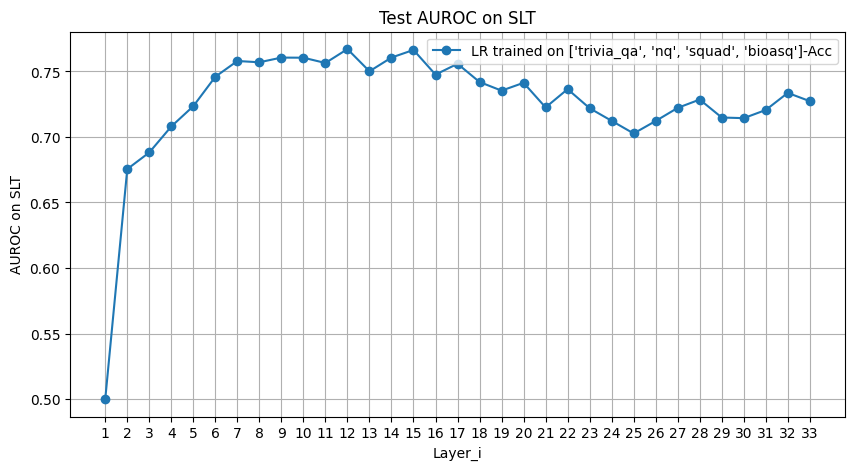

In [164]:
# Train
from sklearn.base import clone

for i, D in enumerate(Ds):
    other_ids = D.other_ids
    other_names = D.other_names
    
    print(f"Training on datasets {other_names}'s SLT-SE to predict {D.name}'s SLT-Acc")

    X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = merge_Xs_and_ys(Ds, other_ids, 'b_entropy')
    osb_accs = []
    osb_aucs = []
    osb_models = []
    
    for k, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
        print(f"Training on SLT-SE {k+1}/{len(X_trains)} - {other_names}")
        model = LogisticRegression()
        sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on {other_names}-SLT-SE {k+1} layer")
        test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
        osb_accs.append(test_acc)
        osb_aucs.append(test_auc)
        osb_models.append(model)

    plot_metrics([osb_aucs], [f'LR trained on {other_names}-SE'], f'AUROC on SLT')

    D.osb_accs = osb_accs
    D.osb_aucs = osb_aucs
    D.osb_models = osb_models

    print(f"Training on datasets {other_names}'s SLT-Acc to predict {D.name}'s SLT-Acc")

    X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = merge_Xs_and_ys(Ds, other_ids, 'accuracies')
    osa_accs = []
    osa_aucs = []
    osa_models = []
    
    for k, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
        print(f"Training on SLT-Acc {k+1}/{len(X_trains)} - {other_names}")
        model = LogisticRegression()
        sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on {other_names}-SLT-Acc {k+1} layer")
        test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
        osa_accs.append(test_acc)
        osa_aucs.append(test_auc)
        osa_models.append(model)

    D.osa_accs = osa_accs
    D.osa_aucs = osa_aucs
    D.osa_models = osa_models

    plot_metrics([osa_aucs], [f'LR trained on {other_names}-Acc'], f'AUROC on SLT')

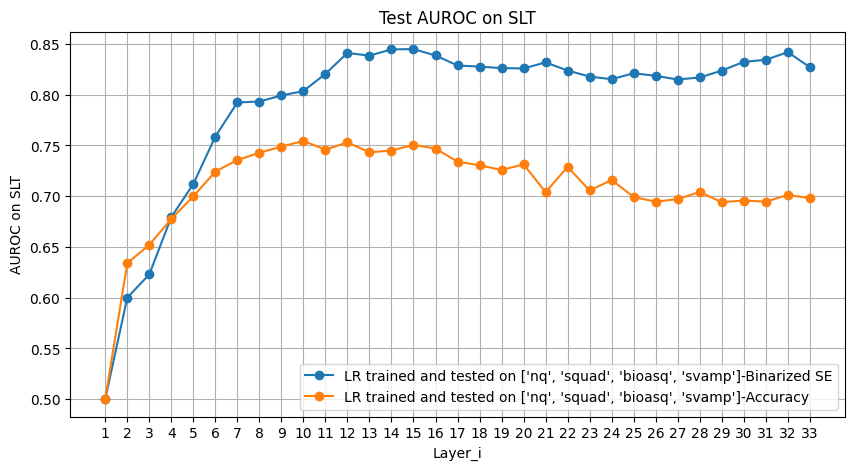

SLT: max AUROC for LR trained on ['nq', 'squad', 'bioasq', 'svamp']'s SE and tested on ['nq', 'squad', 'bioasq', 'svamp']'s SE:
	- 0.8449 at layer 15
	- 0.8446 at layer 14
	- 0.8418 at layer 32
	- 0.8410 at layer 12
	- 0.8386 at layer 16
SLT: max AUROC for LR trained on ['nq', 'squad', 'bioasq', 'svamp']'s Acc and tested on ['nq', 'squad', 'bioasq', 'svamp']'s Acc:
	- 0.7543 at layer 10
	- 0.7529 at layer 12
	- 0.7505 at layer 15
	- 0.7488 at layer 9
	- 0.7469 at layer 16


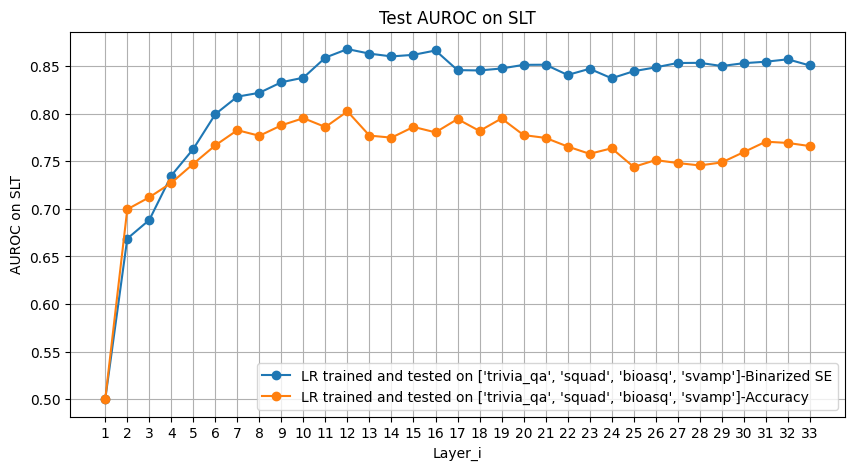

SLT: max AUROC for LR trained on ['trivia_qa', 'squad', 'bioasq', 'svamp']'s SE and tested on ['trivia_qa', 'squad', 'bioasq', 'svamp']'s SE:
	- 0.8678 at layer 12
	- 0.8664 at layer 16
	- 0.8631 at layer 13
	- 0.8618 at layer 15
	- 0.8601 at layer 14
SLT: max AUROC for LR trained on ['trivia_qa', 'squad', 'bioasq', 'svamp']'s Acc and tested on ['trivia_qa', 'squad', 'bioasq', 'svamp']'s Acc:
	- 0.8024 at layer 12
	- 0.7952 at layer 10
	- 0.7949 at layer 19
	- 0.7943 at layer 17
	- 0.7877 at layer 9


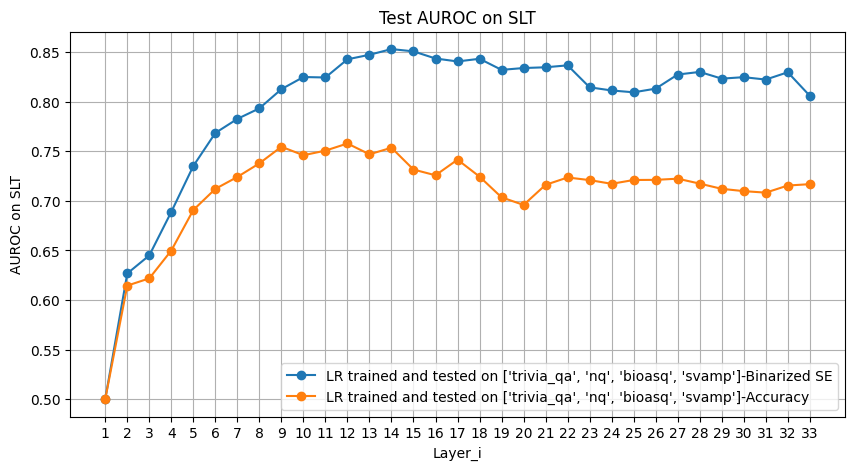

SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'bioasq', 'svamp']'s SE and tested on ['trivia_qa', 'nq', 'bioasq', 'svamp']'s SE:
	- 0.8530 at layer 14
	- 0.8507 at layer 15
	- 0.8472 at layer 13
	- 0.8435 at layer 16
	- 0.8432 at layer 18
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'bioasq', 'svamp']'s Acc and tested on ['trivia_qa', 'nq', 'bioasq', 'svamp']'s Acc:
	- 0.7578 at layer 12
	- 0.7545 at layer 9
	- 0.7535 at layer 14
	- 0.7506 at layer 11
	- 0.7469 at layer 13


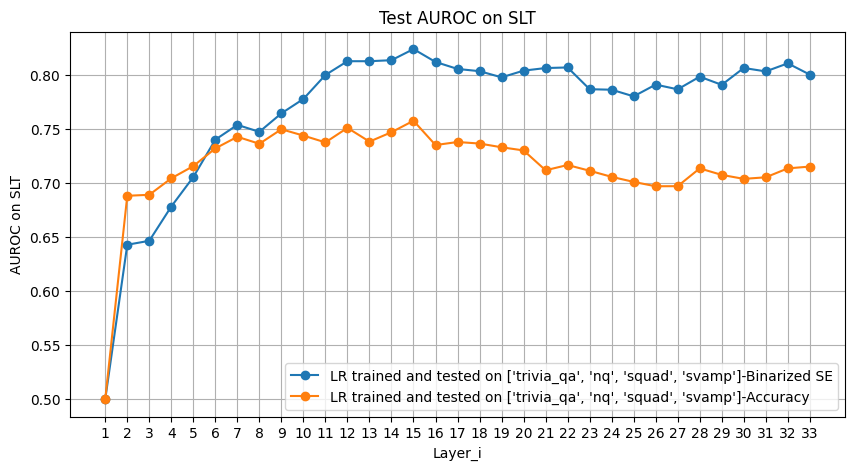

SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'svamp']'s SE and tested on ['trivia_qa', 'nq', 'squad', 'svamp']'s SE:
	- 0.8239 at layer 15
	- 0.8137 at layer 14
	- 0.8127 at layer 12
	- 0.8127 at layer 13
	- 0.8120 at layer 16
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'svamp']'s Acc and tested on ['trivia_qa', 'nq', 'squad', 'svamp']'s Acc:
	- 0.7576 at layer 15
	- 0.7510 at layer 12
	- 0.7497 at layer 9
	- 0.7470 at layer 14
	- 0.7439 at layer 10


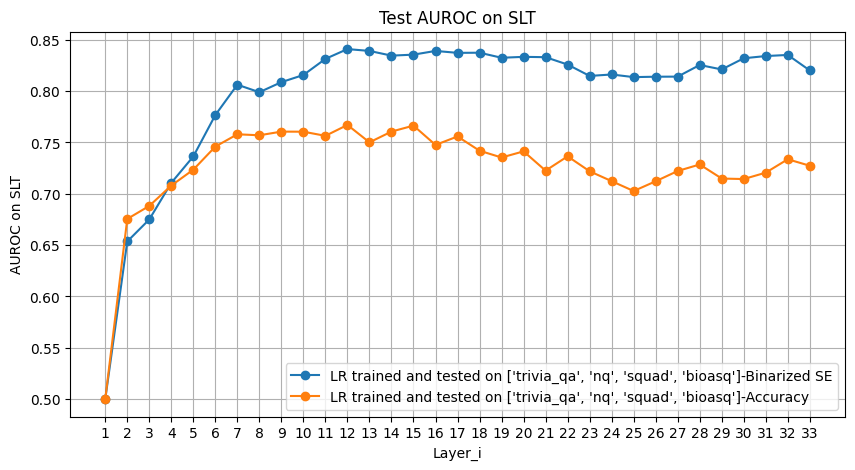

SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'bioasq']'s SE and tested on ['trivia_qa', 'nq', 'squad', 'bioasq']'s SE:
	- 0.8408 at layer 12
	- 0.8390 at layer 13
	- 0.8390 at layer 16
	- 0.8372 at layer 18
	- 0.8371 at layer 17
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'bioasq']'s Acc and tested on ['trivia_qa', 'nq', 'squad', 'bioasq']'s Acc:
	- 0.7669 at layer 12
	- 0.7663 at layer 15
	- 0.7605 at layer 14
	- 0.7604 at layer 9
	- 0.7603 at layer 10


In [183]:
for D in Ds:
    plot_metrics([D.osb_aucs, D.osa_aucs], [f'LR trained and tested on {D.other_names}-Binarized SE', f'LR trained and tested on {D.other_names}-Accuracy'], f'AUROC on SLT')
    best_metric([D.osb_aucs], token="SLT", train="SE", test="SE", ds=[[D.other_names]*2])
    best_metric([D.osa_aucs], token="SLT", train="Acc", test="Acc", ds=[[D.other_names]*2])

We see the best layers are mostly from layer `12` to `15`.

In [245]:
# Test
def test_n_on_one(D):
    other_ids = D.other_ids
    other_names = D.other_names
    osb_models = D.osb_models
    osa_models = D.osa_models
    
    print(f"Testing on {D.name}'s SE")
    _, _, X_tests, _, _, y_tests = create_Xs_and_ys(D.slt_dataset, D.b_entropy, D.total_size) 
    isb_accs = []
    isb_aucs = []
    
    for k, (X_test, y_test) in enumerate(zip(X_tests, y_tests)):
        # print(f"Testing on {D.name}-SLT-SE {k+1}/{len(X_tests)}")
        model = osb_models[k]
        test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True, silent=True)
        isb_accs.append(test_acc)
        isb_aucs.append(test_auc)

    D.isb_accs = isb_accs
    D.isb_aucs = isb_aucs
    plot_metrics([D.sb_aucs, D.isb_aucs], [f'LR trained and tested on {D.name}-SE', 
                                                       # f'LR trained and tested on \n{other_names}-SE',
                                                       f'LR trained on {other_names}-SE \n and tested on {D.name}-SE'], 
                 f'AUROC on SLT')
    best_metric([D.sb_aucs], token="SLT", train="SE", test="SE", ds=[[D.name]*2])
    best_metric([D.isb_aucs], token="SLT", train="SE", test="SE", ds=[[other_names, D.name]])

    print(f"\nTesting on {D.name}'s Acc")
    r_acc = 1 - D.accuracies
    _, _, X_tests, _, _, y_tests = create_Xs_and_ys(D.slt_dataset, r_acc, D.total_size) 
    isab_accs = []
    isab_aucs = []
    isaa_accs = []
    isaa_aucs = []

    for k, (X_test, y_test) in enumerate(zip(X_tests, y_tests)):
        # print(f"Testing on {D.name}-SLT-Acc {k+1}/{len(X_tests)}")
        b_model = osb_models[k]
        test_loss, test_acc, test_auc = sklearn_evaluate_on_test(b_model, X_test, y_test, binary_cls=True, silent=True)
        isab_accs.append(test_acc)
        isab_aucs.append(test_auc)
        
        a_model = osa_models[k]
        test_loss, test_acc, test_auc = sklearn_evaluate_on_test(a_model, X_test, y_test, binary_cls=True, silent=True)
        isaa_accs.append(test_acc)
        isaa_aucs.append(test_auc)
    
    D.isab_accs = isab_accs
    D.isab_aucs = isab_aucs
    D.isaa_accs = isaa_accs
    D.isaa_aucs = isaa_aucs

    plot_metrics([D.sa_aucs, D.sab_aucs, D.isab_aucs, D.isaa_aucs], 
                 [f'LR trained and tested on {D.name}-Acc', 
                  f'LR trained on {D.name}-SE\n and tested on {D.name}-Acc', 
                  f'LR trained on {other_names}-SE\n and tested on {D.name}-Acc', 
                  f'LR trained on {other_names}-Acc\n and tested on {D.name}-Acc ',
                 ], 
                 f'AUROC on SLT')
    best_metric([D.sa_aucs], token="SLT", train="Acc", test="Acc", ds=[[D.name]*2])
    best_metric([D.sab_aucs], token="SLT", train="SE", test="Acc", ds=[[D.name]*2])
    best_metric([D.isab_aucs], token="SLT", train="SE", test="Acc", ds=[[other_names, D.name]])
    best_metric([D.isaa_aucs], token="SLT", train="Acc", test="Acc", ds=[[other_names, D.name]])

Testing on trivia_qa's SE


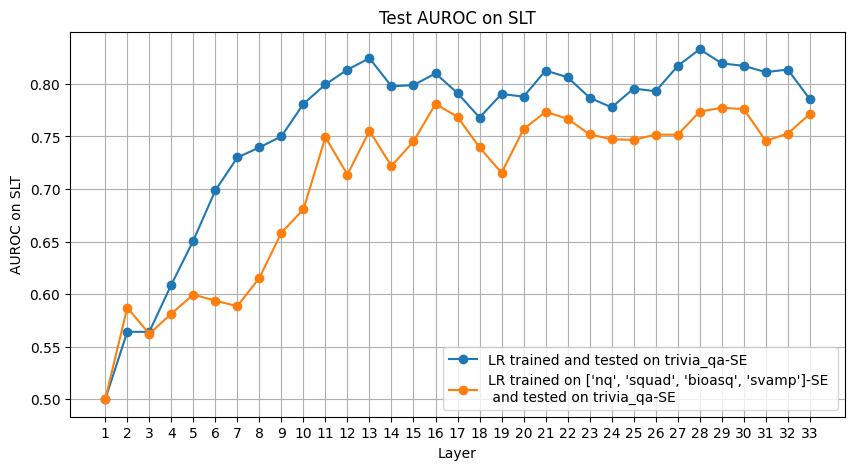

SLT: max AUROC for LR trained on trivia_qa's SE and tested on trivia_qa's SE:
	- 0.8330 at layer 28
	- 0.8245 at layer 13
	- 0.8196 at layer 29
	- 0.8172 at layer 30
	- 0.8171 at layer 27
SLT: max AUROC for LR trained on ['nq', 'squad', 'bioasq', 'svamp']'s SE and tested on trivia_qa's SE:
	- 0.7809 at layer 16
	- 0.7773 at layer 29
	- 0.7760 at layer 30
	- 0.7736 at layer 28
	- 0.7734 at layer 21

Testing on trivia_qa's Acc


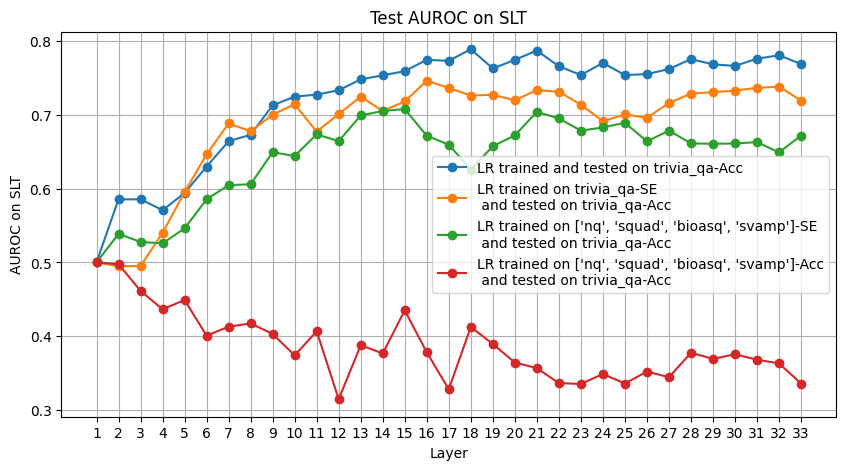

SLT: max AUROC for LR trained on trivia_qa's Acc and tested on trivia_qa's Acc:
	- 0.7886 at layer 18
	- 0.7868 at layer 21
	- 0.7804 at layer 32
	- 0.7758 at layer 31
	- 0.7751 at layer 28
SLT: max AUROC for LR trained on trivia_qa's SE and tested on trivia_qa's Acc:
	- 0.7459 at layer 16
	- 0.7379 at layer 32
	- 0.7363 at layer 31
	- 0.7361 at layer 17
	- 0.7332 at layer 21
SLT: max AUROC for LR trained on ['nq', 'squad', 'bioasq', 'svamp']'s SE and tested on trivia_qa's Acc:
	- 0.7075 at layer 15
	- 0.7051 at layer 14
	- 0.7037 at layer 21
	- 0.6989 at layer 13
	- 0.6949 at layer 22
SLT: max AUROC for LR trained on ['nq', 'squad', 'bioasq', 'svamp']'s Acc and tested on trivia_qa's Acc:
	- 0.5000 at layer 1
	- 0.4975 at layer 2
	- 0.4615 at layer 3
	- 0.4491 at layer 5
	- 0.4365 at layer 4


In [246]:
# Inspect dataset by dataset
test_n_on_one(D1)

Testing on nq's SE


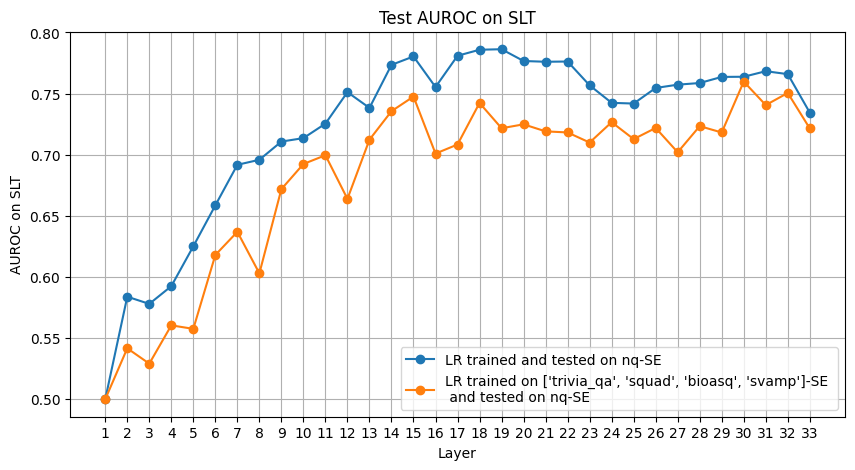

SLT: max AUROC for LR trained on nq's SE and tested on nq's SE:
	- 0.7863 at layer 19
	- 0.7859 at layer 18
	- 0.7810 at layer 17
	- 0.7804 at layer 15
	- 0.7767 at layer 20
SLT: max AUROC for LR trained on ['trivia_qa', 'squad', 'bioasq', 'svamp']'s SE and tested on nq's SE:
	- 0.7598 at layer 30
	- 0.7505 at layer 32
	- 0.7476 at layer 15
	- 0.7424 at layer 18
	- 0.7406 at layer 31

Testing on nq's Acc


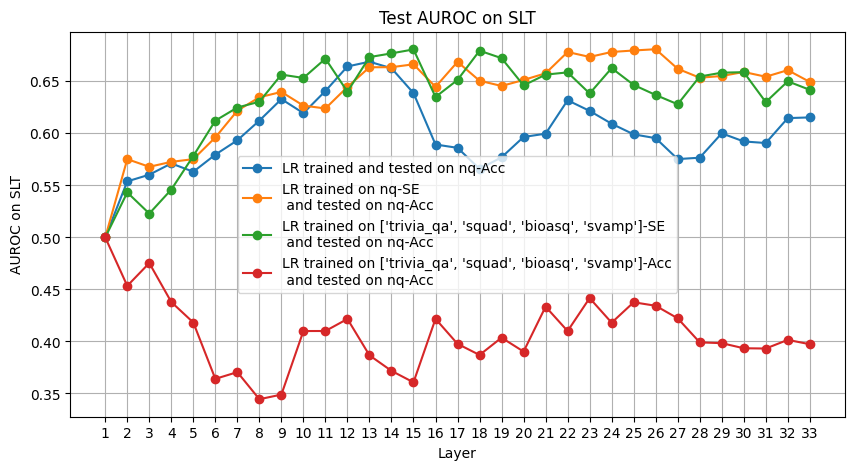

SLT: max AUROC for LR trained on nq's Acc and tested on nq's Acc:
	- 0.6689 at layer 13
	- 0.6643 at layer 12
	- 0.6626 at layer 14
	- 0.6408 at layer 11
	- 0.6387 at layer 15
SLT: max AUROC for LR trained on nq's SE and tested on nq's Acc:
	- 0.6809 at layer 26
	- 0.6797 at layer 25
	- 0.6783 at layer 24
	- 0.6782 at layer 22
	- 0.6735 at layer 23
SLT: max AUROC for LR trained on ['trivia_qa', 'squad', 'bioasq', 'svamp']'s SE and tested on nq's Acc:
	- 0.6807 at layer 15
	- 0.6795 at layer 18
	- 0.6769 at layer 14
	- 0.6733 at layer 13
	- 0.6723 at layer 19
SLT: max AUROC for LR trained on ['trivia_qa', 'squad', 'bioasq', 'svamp']'s Acc and tested on nq's Acc:
	- 0.5000 at layer 1
	- 0.4754 at layer 3
	- 0.4534 at layer 2
	- 0.4417 at layer 23
	- 0.4379 at layer 4


In [247]:
# Inspect dataset by dataset
test_n_on_one(D2)

Testing on bioasq's SE


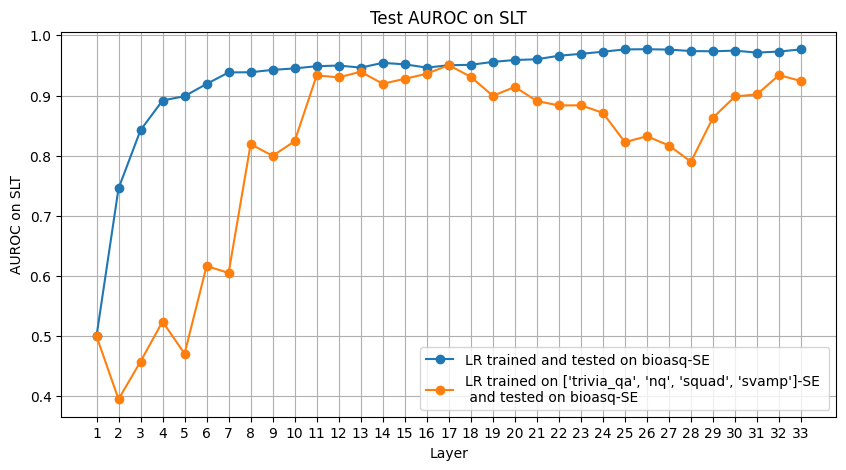

SLT: max AUROC for LR trained on bioasq's SE and tested on bioasq's SE:
	- 0.9769 at layer 26
	- 0.9766 at layer 25
	- 0.9766 at layer 33
	- 0.9763 at layer 27
	- 0.9746 at layer 30
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'svamp']'s SE and tested on bioasq's SE:
	- 0.9505 at layer 17
	- 0.9395 at layer 13
	- 0.9361 at layer 16
	- 0.9340 at layer 32
	- 0.9334 at layer 11

Testing on bioasq's Acc


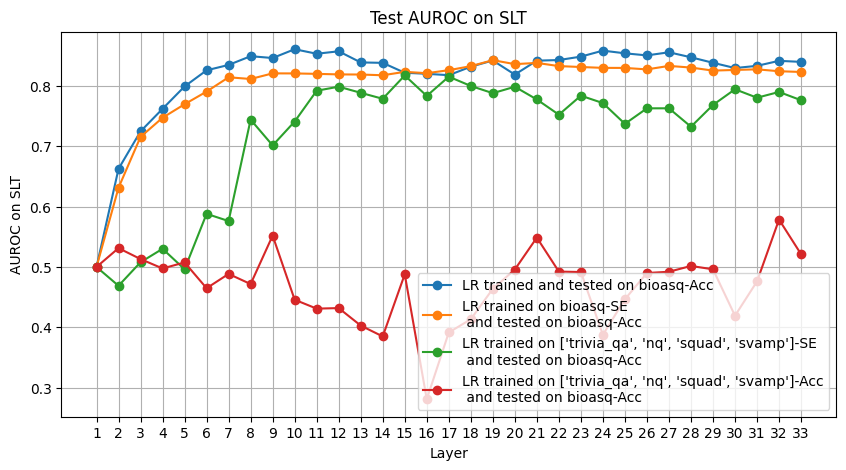

SLT: max AUROC for LR trained on bioasq's Acc and tested on bioasq's Acc:
	- 0.8606 at layer 10
	- 0.8583 at layer 24
	- 0.8572 at layer 12
	- 0.8556 at layer 27
	- 0.8538 at layer 25
SLT: max AUROC for LR trained on bioasq's SE and tested on bioasq's Acc:
	- 0.8425 at layer 19
	- 0.8379 at layer 21
	- 0.8359 at layer 20
	- 0.8330 at layer 27
	- 0.8327 at layer 22
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'svamp']'s SE and tested on bioasq's Acc:
	- 0.8172 at layer 15
	- 0.8152 at layer 17
	- 0.7998 at layer 18
	- 0.7986 at layer 12
	- 0.7985 at layer 20
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'svamp']'s Acc and tested on bioasq's Acc:
	- 0.5785 at layer 32
	- 0.5520 at layer 9
	- 0.5486 at layer 21
	- 0.5312 at layer 2
	- 0.5212 at layer 33


In [249]:
# Inspect dataset by dataset
test_n_on_one(D4)

Testing on squad's SE


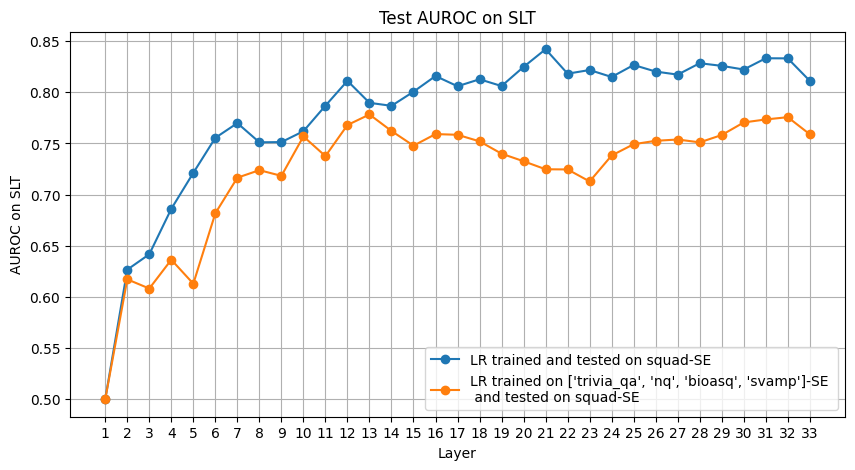

SLT: max AUROC for LR trained on squad's SE and tested on squad's SE:
	- 0.8421 at layer 21
	- 0.8332 at layer 31
	- 0.8331 at layer 32
	- 0.8284 at layer 28
	- 0.8266 at layer 25
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'bioasq', 'svamp']'s SE and tested on squad's SE:
	- 0.7783 at layer 13
	- 0.7756 at layer 32
	- 0.7734 at layer 31
	- 0.7705 at layer 30
	- 0.7680 at layer 12

Testing on squad's Acc


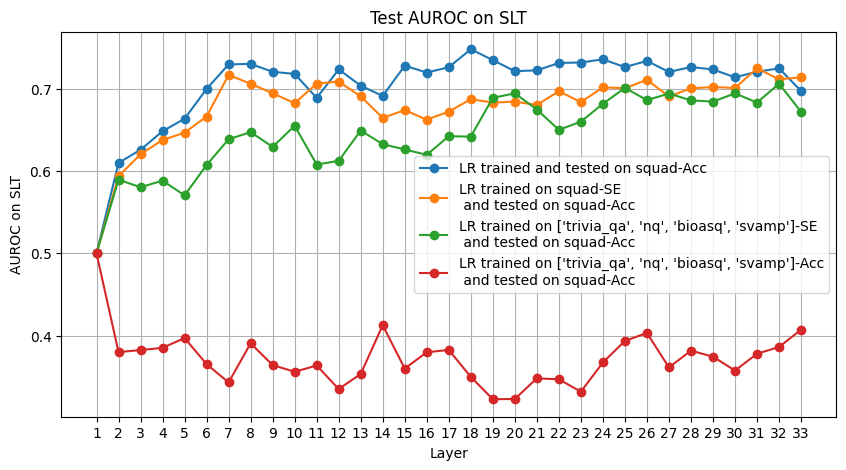

SLT: max AUROC for LR trained on squad's Acc and tested on squad's Acc:
	- 0.7479 at layer 18
	- 0.7356 at layer 24
	- 0.7347 at layer 19
	- 0.7337 at layer 26
	- 0.7318 at layer 23
SLT: max AUROC for LR trained on squad's SE and tested on squad's Acc:
	- 0.7248 at layer 31
	- 0.7167 at layer 7
	- 0.7138 at layer 33
	- 0.7113 at layer 32
	- 0.7108 at layer 26
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'bioasq', 'svamp']'s SE and tested on squad's Acc:
	- 0.7060 at layer 32
	- 0.7009 at layer 25
	- 0.6943 at layer 20
	- 0.6943 at layer 30
	- 0.6941 at layer 27
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'bioasq', 'svamp']'s Acc and tested on squad's Acc:
	- 0.5000 at layer 1
	- 0.4127 at layer 14
	- 0.4072 at layer 33
	- 0.4033 at layer 26
	- 0.3971 at layer 5


In [248]:
# Inspect dataset by dataset
test_n_on_one(D3)

Testing on svamp's SE


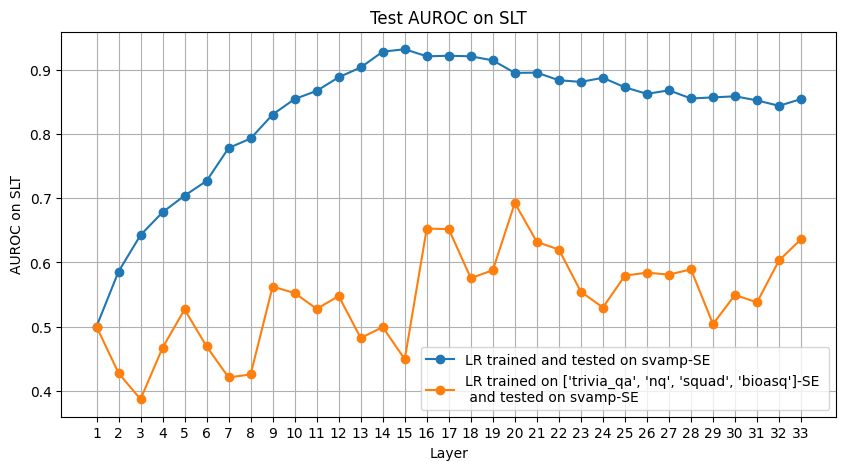

SLT: max AUROC for LR trained on svamp's SE and tested on svamp's SE:
	- 0.9325 at layer 15
	- 0.9287 at layer 14
	- 0.9223 at layer 17
	- 0.9215 at layer 16
	- 0.9215 at layer 18
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'bioasq']'s SE and tested on svamp's SE:
	- 0.6927 at layer 20
	- 0.6528 at layer 16
	- 0.6520 at layer 17
	- 0.6362 at layer 33
	- 0.6320 at layer 21

Testing on svamp's Acc


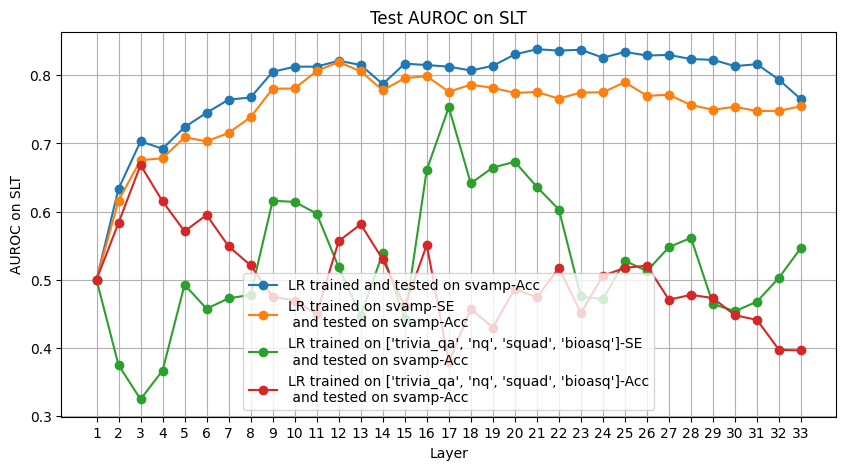

SLT: max AUROC for LR trained on svamp's Acc and tested on svamp's Acc:
	- 0.8383 at layer 21
	- 0.8375 at layer 23
	- 0.8363 at layer 22
	- 0.8343 at layer 25
	- 0.8307 at layer 20
SLT: max AUROC for LR trained on svamp's SE and tested on svamp's Acc:
	- 0.8195 at layer 12
	- 0.8063 at layer 11
	- 0.8059 at layer 13
	- 0.7987 at layer 16
	- 0.7959 at layer 15
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'bioasq']'s SE and tested on svamp's Acc:
	- 0.7531 at layer 17
	- 0.6731 at layer 20
	- 0.6647 at layer 19
	- 0.6611 at layer 16
	- 0.6415 at layer 18
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'bioasq']'s Acc and tested on svamp's Acc:
	- 0.6683 at layer 3
	- 0.6150 at layer 4
	- 0.5950 at layer 6
	- 0.5834 at layer 2
	- 0.5814 at layer 13


In [250]:
# Inspect dataset by dataset
test_n_on_one(D5)

## Generalize probes trained with one dataset's SE to predicting another's SE/Acc
Train probes on one dataset's SE and test it to other dataset's Acc prediction.

In [268]:
# Train on one's SE and test on others' SE/Acc
def test_one_on_n(D):
    other_ids = D.other_ids
    other_names = D.other_names
    sb_models = D.sb_models
    
    print(f"Using probes trained on datasets {D.name.upper()}'s SLT-SE to predict {other_names}'s SLT-SE")
    
    sbo_accs = {}
    sbo_aucs = {}
    
    for id_ in D.other_ids:
        D_id = Ds[id_]
        print(f"Testing on {D_id.name.upper()}'s SLT-SE")
        _, _, X_tests, _, _, y_tests = create_Xs_and_ys(D_id.slt_dataset, D_id.b_entropy, D_id.total_size)
        id_accs = []
        id_aucs = []
        for i, (X_test, y_test) in enumerate(zip(X_tests, y_tests)):
            model = sb_models[i]
            test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True, silent=True)
            id_accs.append(test_acc)
            id_aucs.append(test_auc)

        sbo_accs[D_id.name] = id_accs
        sbo_aucs[D_id.name] = id_aucs

        plot_metrics([D_id.sb_aucs, D_id.isb_aucs, id_aucs], [f'LR trained and tested on {D_id.name}-SE',
                                                              f'LR trained on {D_id.other_names}-SE,\n tested on {D_id.name}-SE',
                                                              f'LR trained on {D.name}-SE, tested on {D_id.name}-SE'], 
                     f'AUROC on SLT')
        best_metric([D_id.sb_aucs], token="SLT", train="SE", test="SE", ds=[[D_id.name]*2])
        best_metric([D_id.isb_aucs], token="SLT", train="SE", test="SE", ds=[[D_id.other_names, D_id.name]])
        best_metric([id_aucs], token="SLT", train="SE", test="SE", ds=[[D.name, D_id.name]])
        

    D.sbo_accs = sbo_accs
    D.sbo_aucs = sbo_aucs

    print(f"\n\nUsing probes trained on datasets {D.name.upper()}'s SLT-SE to predict {other_names}'s SLT-Acc")
    
    sao_accs = {}
    sao_aucs = {}
    
    for id_ in D.other_ids:
        D_id = Ds[id_]
        print(f"Testing on {D_id.name.upper()}'s SLT-Acc")
        _, _, X_tests, _, _, y_tests = create_Xs_and_ys(D_id.slt_dataset, 1-D_id.accuracies, D_id.total_size)
        id_accs = []
        id_aucs = []
        for i, (X_test, y_test) in enumerate(zip(X_tests, y_tests)):
            model = sb_models[i]
            test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True, silent=True)
            id_accs.append(test_acc)
            id_aucs.append(test_auc)

        sao_accs[D_id.name] = id_accs
        sao_aucs[D_id.name] = id_aucs

        plot_metrics([D_id.sa_aucs, D_id.isab_aucs, id_aucs, D_id.isaa_aucs], [f'LR trained and tested on {D_id.name}-Acc',
                                                                               f'LR trained on {D_id.other_names}-SE,\n tested on {D_id.name}-Acc',
                                                                               f'LR trained on {D.name}-SE,\n tested on {D_id.name}-Acc',
                                                                                f'LR trained on {D_id.other_names}-Acc,\n tested on {D_id.name}-Acc'], 
                     f'AUROC on SLT')

        best_metric([D_id.sa_aucs], token="SLT", train="Acc", test="Acc", ds=[[D_id.name]*2])
        best_metric([D_id.isab_aucs], token="SLT", train="SE", test="Acc", ds=[[D_id.other_names, D_id.name]])
        best_metric([id_aucs], token="SLT", train="SE", test="Acc", ds=[[D.name, D_id.name]])
        best_metric([D_id.isaa_aucs], token="SLT", train="Acc", test="Acc", ds=[[D_id.other_names, D_id.name]])
    
    D.sao_accs = sao_accs
    D.sao_aucs = sao_aucs


Using probes trained on datasets TRIVIA_QA's SLT-SE to predict ['nq', 'squad', 'bioasq', 'svamp']'s SLT-SE
Testing on NQ's SLT-SE


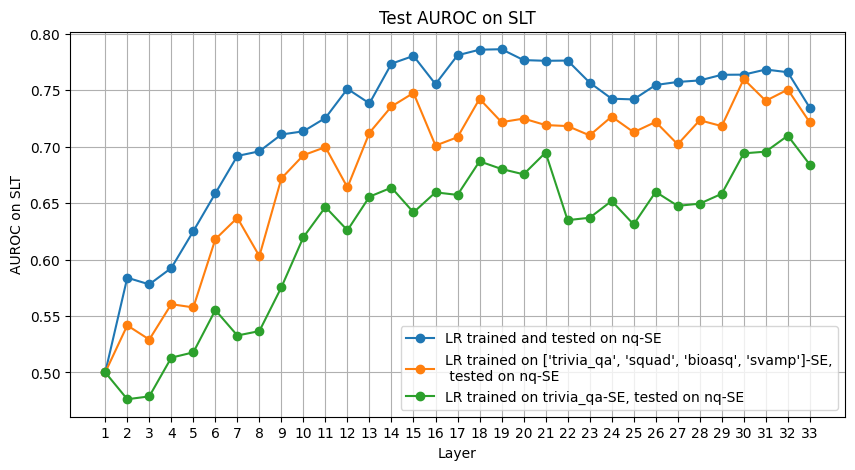

SLT: max AUROC for LR trained on nq's SE and tested on nq's SE:
	- 0.7863 at layer 19
	- 0.7859 at layer 18
	- 0.7810 at layer 17
	- 0.7804 at layer 15
	- 0.7767 at layer 20
SLT: max AUROC for LR trained on ['trivia_qa', 'squad', 'bioasq', 'svamp']'s SE and tested on nq's SE:
	- 0.7598 at layer 30
	- 0.7505 at layer 32
	- 0.7476 at layer 15
	- 0.7424 at layer 18
	- 0.7406 at layer 31
SLT: max AUROC for LR trained on trivia_qa's SE and tested on nq's SE:
	- 0.7097 at layer 32
	- 0.6956 at layer 31
	- 0.6948 at layer 21
	- 0.6941 at layer 30
	- 0.6870 at layer 18
Testing on SQUAD's SLT-SE


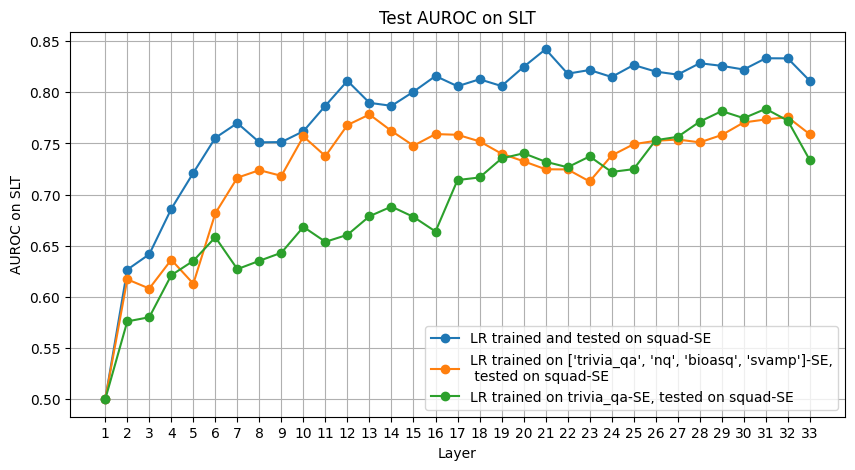

SLT: max AUROC for LR trained on squad's SE and tested on squad's SE:
	- 0.8421 at layer 21
	- 0.8332 at layer 31
	- 0.8331 at layer 32
	- 0.8284 at layer 28
	- 0.8266 at layer 25
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'bioasq', 'svamp']'s SE and tested on squad's SE:
	- 0.7783 at layer 13
	- 0.7756 at layer 32
	- 0.7734 at layer 31
	- 0.7705 at layer 30
	- 0.7680 at layer 12
SLT: max AUROC for LR trained on trivia_qa's SE and tested on squad's SE:
	- 0.7838 at layer 31
	- 0.7816 at layer 29
	- 0.7747 at layer 30
	- 0.7722 at layer 32
	- 0.7712 at layer 28
Testing on BIOASQ's SLT-SE


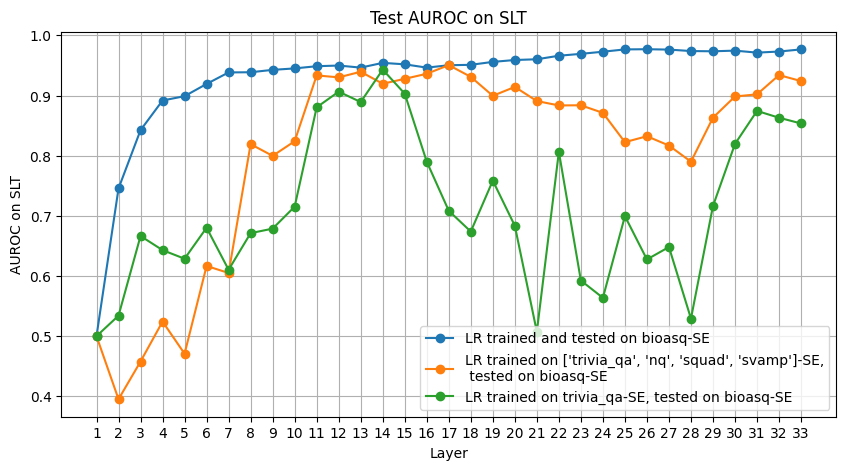

SLT: max AUROC for LR trained on bioasq's SE and tested on bioasq's SE:
	- 0.9769 at layer 26
	- 0.9766 at layer 25
	- 0.9766 at layer 33
	- 0.9763 at layer 27
	- 0.9746 at layer 30
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'svamp']'s SE and tested on bioasq's SE:
	- 0.9505 at layer 17
	- 0.9395 at layer 13
	- 0.9361 at layer 16
	- 0.9340 at layer 32
	- 0.9334 at layer 11
SLT: max AUROC for LR trained on trivia_qa's SE and tested on bioasq's SE:
	- 0.9430 at layer 14
	- 0.9064 at layer 12
	- 0.9030 at layer 15
	- 0.8892 at layer 13
	- 0.8804 at layer 11
Testing on SVAMP's SLT-SE


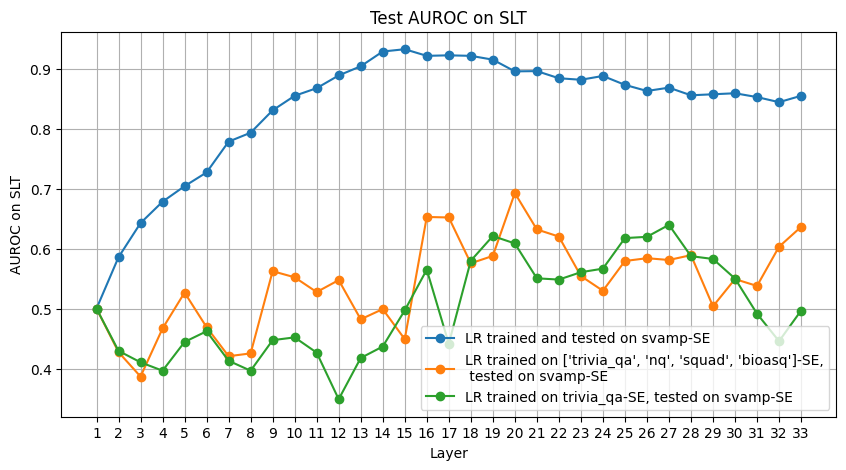

SLT: max AUROC for LR trained on svamp's SE and tested on svamp's SE:
	- 0.9325 at layer 15
	- 0.9287 at layer 14
	- 0.9223 at layer 17
	- 0.9215 at layer 16
	- 0.9215 at layer 18
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'bioasq']'s SE and tested on svamp's SE:
	- 0.6927 at layer 20
	- 0.6528 at layer 16
	- 0.6520 at layer 17
	- 0.6362 at layer 33
	- 0.6320 at layer 21
SLT: max AUROC for LR trained on trivia_qa's SE and tested on svamp's SE:
	- 0.6396 at layer 27
	- 0.6210 at layer 19
	- 0.6197 at layer 26
	- 0.6176 at layer 25
	- 0.6087 at layer 20


Using probes trained on datasets TRIVIA_QA's SLT-SE to predict ['nq', 'squad', 'bioasq', 'svamp']'s SLT-Acc
Testing on NQ's SLT-Acc


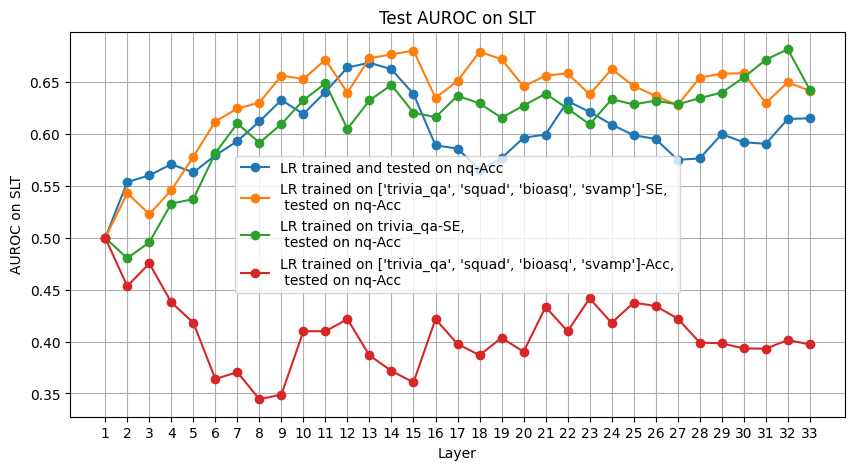

SLT: max AUROC for LR trained on nq's Acc and tested on nq's Acc:
	- 0.6689 at layer 13
	- 0.6643 at layer 12
	- 0.6626 at layer 14
	- 0.6408 at layer 11
	- 0.6387 at layer 15
SLT: max AUROC for LR trained on ['trivia_qa', 'squad', 'bioasq', 'svamp']'s SE and tested on nq's Acc:
	- 0.6807 at layer 15
	- 0.6795 at layer 18
	- 0.6769 at layer 14
	- 0.6733 at layer 13
	- 0.6723 at layer 19
SLT: max AUROC for LR trained on trivia_qa's SE and tested on nq's Acc:
	- 0.6820 at layer 32
	- 0.6718 at layer 31
	- 0.6547 at layer 30
	- 0.6491 at layer 11
	- 0.6474 at layer 14
SLT: max AUROC for LR trained on ['trivia_qa', 'squad', 'bioasq', 'svamp']'s Acc and tested on nq's Acc:
	- 0.5000 at layer 1
	- 0.4754 at layer 3
	- 0.4534 at layer 2
	- 0.4417 at layer 23
	- 0.4379 at layer 4
Testing on SQUAD's SLT-Acc


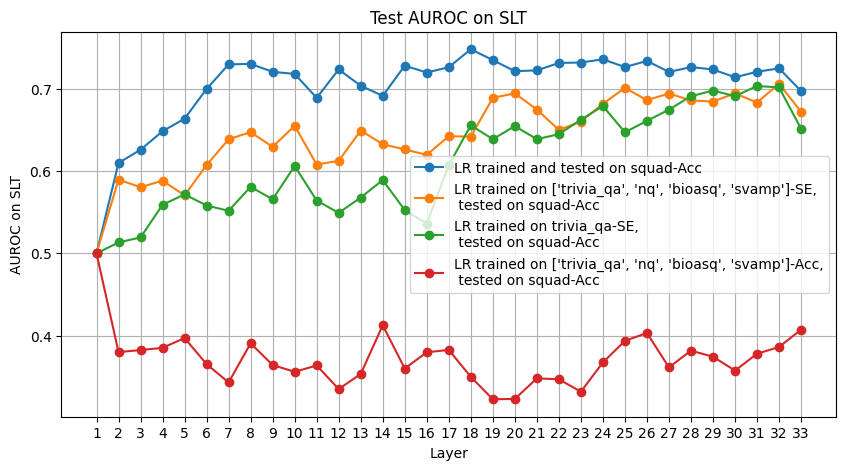

SLT: max AUROC for LR trained on squad's Acc and tested on squad's Acc:
	- 0.7479 at layer 18
	- 0.7356 at layer 24
	- 0.7347 at layer 19
	- 0.7337 at layer 26
	- 0.7318 at layer 23
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'bioasq', 'svamp']'s SE and tested on squad's Acc:
	- 0.7060 at layer 32
	- 0.7009 at layer 25
	- 0.6943 at layer 20
	- 0.6943 at layer 30
	- 0.6941 at layer 27
SLT: max AUROC for LR trained on trivia_qa's SE and tested on squad's Acc:
	- 0.7032 at layer 31
	- 0.7015 at layer 32
	- 0.6977 at layer 29
	- 0.6909 at layer 30
	- 0.6908 at layer 28
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'bioasq', 'svamp']'s Acc and tested on squad's Acc:
	- 0.5000 at layer 1
	- 0.4127 at layer 14
	- 0.4072 at layer 33
	- 0.4033 at layer 26
	- 0.3971 at layer 5
Testing on BIOASQ's SLT-Acc


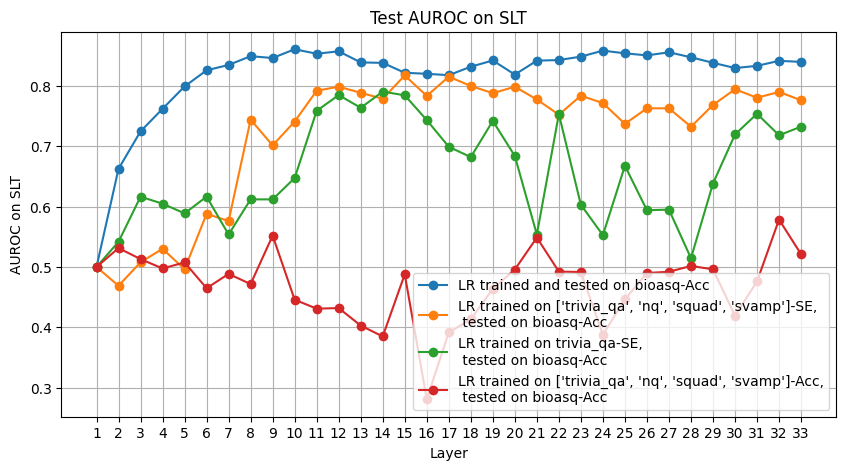

SLT: max AUROC for LR trained on bioasq's Acc and tested on bioasq's Acc:
	- 0.8606 at layer 10
	- 0.8583 at layer 24
	- 0.8572 at layer 12
	- 0.8556 at layer 27
	- 0.8538 at layer 25
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'svamp']'s SE and tested on bioasq's Acc:
	- 0.8172 at layer 15
	- 0.8152 at layer 17
	- 0.7998 at layer 18
	- 0.7986 at layer 12
	- 0.7985 at layer 20
SLT: max AUROC for LR trained on trivia_qa's SE and tested on bioasq's Acc:
	- 0.7904 at layer 14
	- 0.7847 at layer 12
	- 0.7843 at layer 15
	- 0.7636 at layer 13
	- 0.7586 at layer 11
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'svamp']'s Acc and tested on bioasq's Acc:
	- 0.5785 at layer 32
	- 0.5520 at layer 9
	- 0.5486 at layer 21
	- 0.5312 at layer 2
	- 0.5212 at layer 33
Testing on SVAMP's SLT-Acc


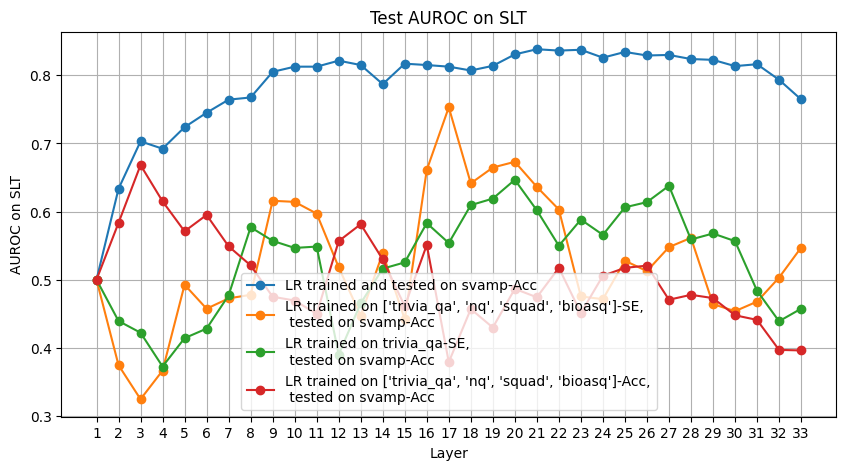

SLT: max AUROC for LR trained on svamp's Acc and tested on svamp's Acc:
	- 0.8383 at layer 21
	- 0.8375 at layer 23
	- 0.8363 at layer 22
	- 0.8343 at layer 25
	- 0.8307 at layer 20
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'bioasq']'s SE and tested on svamp's Acc:
	- 0.7531 at layer 17
	- 0.6731 at layer 20
	- 0.6647 at layer 19
	- 0.6611 at layer 16
	- 0.6415 at layer 18
SLT: max AUROC for LR trained on trivia_qa's SE and tested on svamp's Acc:
	- 0.6467 at layer 20
	- 0.6379 at layer 27
	- 0.6190 at layer 19
	- 0.6138 at layer 26
	- 0.6094 at layer 18
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'bioasq']'s Acc and tested on svamp's Acc:
	- 0.6683 at layer 3
	- 0.6150 at layer 4
	- 0.5950 at layer 6
	- 0.5834 at layer 2
	- 0.5814 at layer 13


In [266]:
test_one_on_n(D1)

Using probes trained on datasets NQ's SLT-SE to predict ['trivia_qa', 'squad', 'bioasq', 'svamp']'s SLT-SE
Testing on TRIVIA_QA's SLT-SE


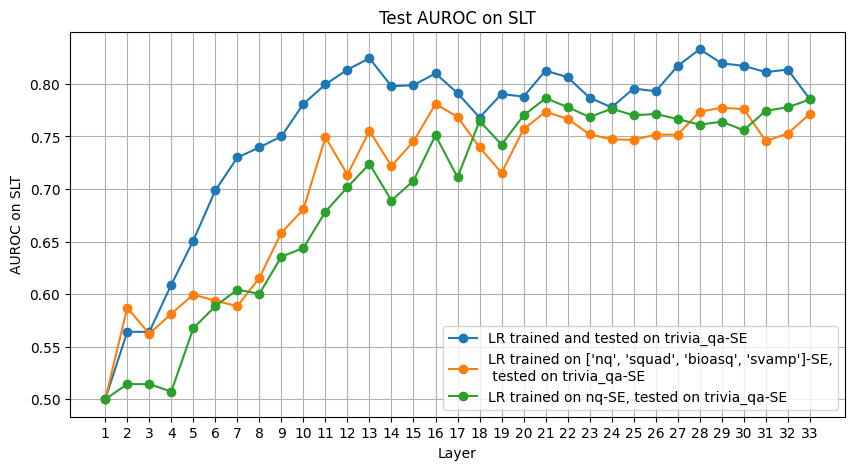

SLT: max AUROC for LR trained on trivia_qa's SE and tested on trivia_qa's SE:
	- 0.8330 at layer 28
	- 0.8245 at layer 13
	- 0.8196 at layer 29
	- 0.8172 at layer 30
	- 0.8171 at layer 27
SLT: max AUROC for LR trained on ['nq', 'squad', 'bioasq', 'svamp']'s SE and tested on trivia_qa's SE:
	- 0.7809 at layer 16
	- 0.7773 at layer 29
	- 0.7760 at layer 30
	- 0.7736 at layer 28
	- 0.7734 at layer 21
SLT: max AUROC for LR trained on nq's SE and tested on trivia_qa's SE:
	- 0.7864 at layer 21
	- 0.7852 at layer 33
	- 0.7780 at layer 22
	- 0.7778 at layer 32
	- 0.7765 at layer 24
Testing on SQUAD's SLT-SE


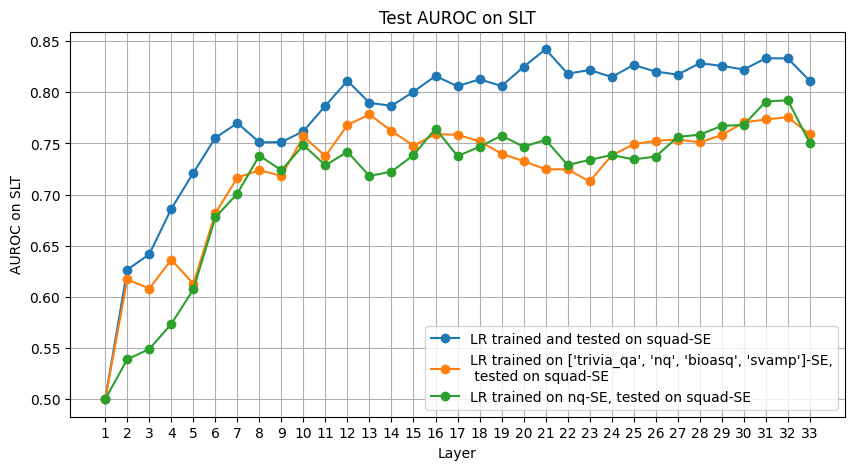

SLT: max AUROC for LR trained on squad's SE and tested on squad's SE:
	- 0.8421 at layer 21
	- 0.8332 at layer 31
	- 0.8331 at layer 32
	- 0.8284 at layer 28
	- 0.8266 at layer 25
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'bioasq', 'svamp']'s SE and tested on squad's SE:
	- 0.7783 at layer 13
	- 0.7756 at layer 32
	- 0.7734 at layer 31
	- 0.7705 at layer 30
	- 0.7680 at layer 12
SLT: max AUROC for LR trained on nq's SE and tested on squad's SE:
	- 0.7922 at layer 32
	- 0.7909 at layer 31
	- 0.7681 at layer 30
	- 0.7671 at layer 29
	- 0.7645 at layer 16
Testing on BIOASQ's SLT-SE


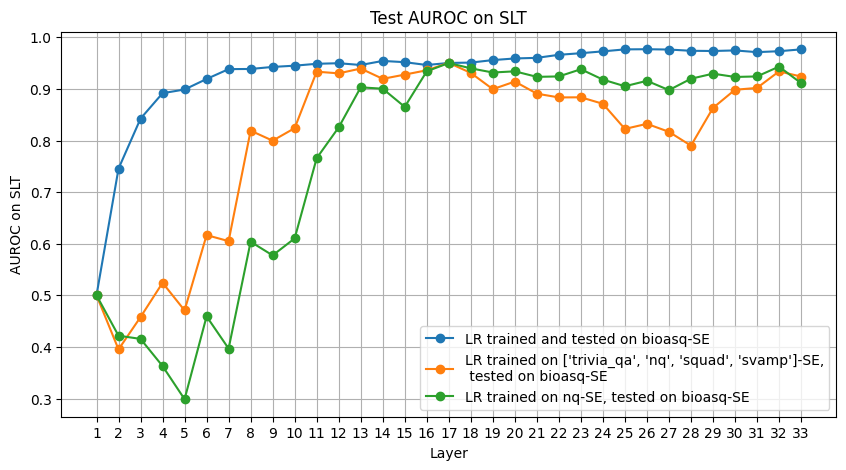

SLT: max AUROC for LR trained on bioasq's SE and tested on bioasq's SE:
	- 0.9769 at layer 26
	- 0.9766 at layer 25
	- 0.9766 at layer 33
	- 0.9763 at layer 27
	- 0.9746 at layer 30
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'svamp']'s SE and tested on bioasq's SE:
	- 0.9505 at layer 17
	- 0.9395 at layer 13
	- 0.9361 at layer 16
	- 0.9340 at layer 32
	- 0.9334 at layer 11
SLT: max AUROC for LR trained on nq's SE and tested on bioasq's SE:
	- 0.9502 at layer 17
	- 0.9432 at layer 32
	- 0.9399 at layer 18
	- 0.9382 at layer 23
	- 0.9341 at layer 16
Testing on SVAMP's SLT-SE


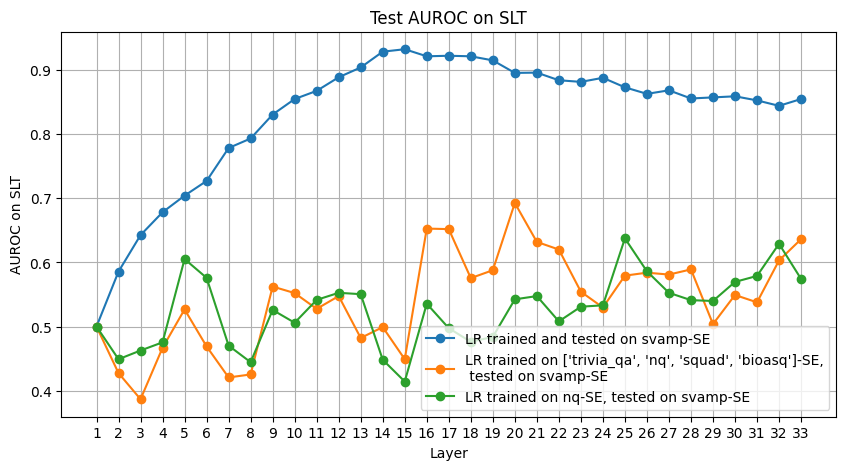

SLT: max AUROC for LR trained on svamp's SE and tested on svamp's SE:
	- 0.9325 at layer 15
	- 0.9287 at layer 14
	- 0.9223 at layer 17
	- 0.9215 at layer 16
	- 0.9215 at layer 18
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'bioasq']'s SE and tested on svamp's SE:
	- 0.6927 at layer 20
	- 0.6528 at layer 16
	- 0.6520 at layer 17
	- 0.6362 at layer 33
	- 0.6320 at layer 21
SLT: max AUROC for LR trained on nq's SE and tested on svamp's SE:
	- 0.6375 at layer 25
	- 0.6290 at layer 32
	- 0.6053 at layer 5
	- 0.5862 at layer 26
	- 0.5789 at layer 31


Using probes trained on datasets NQ's SLT-SE to predict ['trivia_qa', 'squad', 'bioasq', 'svamp']'s SLT-Acc
Testing on TRIVIA_QA's SLT-Acc


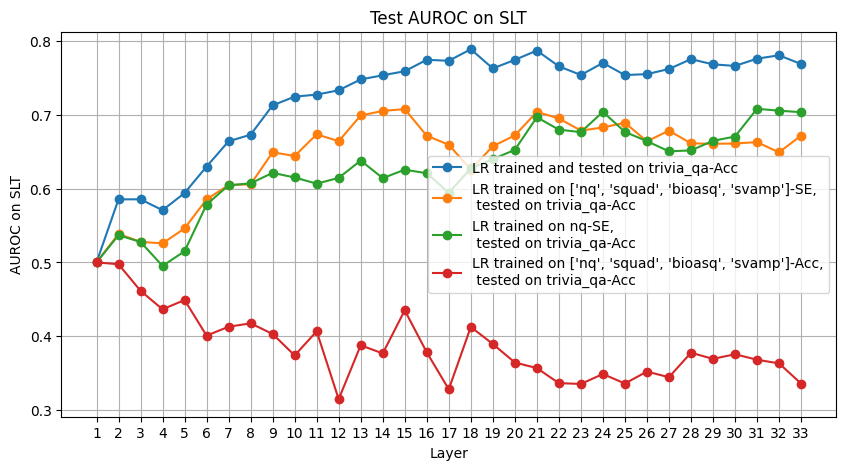

SLT: max AUROC for LR trained on trivia_qa's Acc and tested on trivia_qa's Acc:
	- 0.7886 at layer 18
	- 0.7868 at layer 21
	- 0.7804 at layer 32
	- 0.7758 at layer 31
	- 0.7751 at layer 28
SLT: max AUROC for LR trained on ['nq', 'squad', 'bioasq', 'svamp']'s SE and tested on trivia_qa's Acc:
	- 0.7075 at layer 15
	- 0.7051 at layer 14
	- 0.7037 at layer 21
	- 0.6989 at layer 13
	- 0.6949 at layer 22
SLT: max AUROC for LR trained on nq's SE and tested on trivia_qa's Acc:
	- 0.7079 at layer 31
	- 0.7054 at layer 32
	- 0.7038 at layer 24
	- 0.7034 at layer 33
	- 0.6965 at layer 21
SLT: max AUROC for LR trained on ['nq', 'squad', 'bioasq', 'svamp']'s Acc and tested on trivia_qa's Acc:
	- 0.5000 at layer 1
	- 0.4975 at layer 2
	- 0.4615 at layer 3
	- 0.4491 at layer 5
	- 0.4365 at layer 4
Testing on SQUAD's SLT-Acc


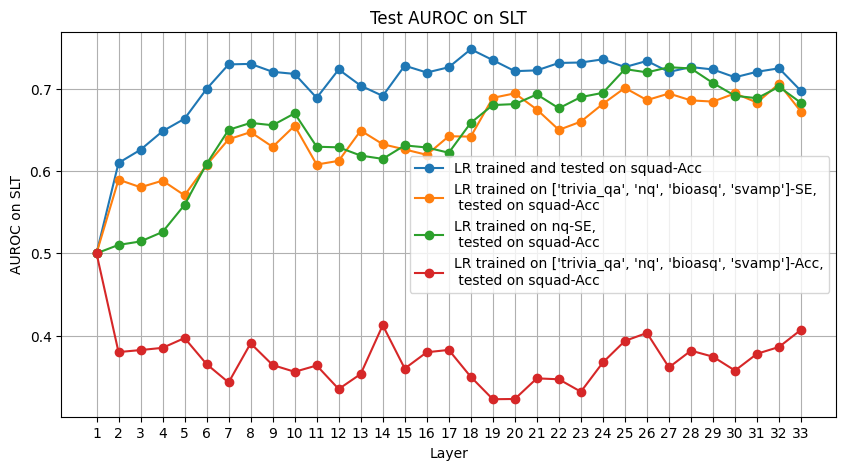

SLT: max AUROC for LR trained on squad's Acc and tested on squad's Acc:
	- 0.7479 at layer 18
	- 0.7356 at layer 24
	- 0.7347 at layer 19
	- 0.7337 at layer 26
	- 0.7318 at layer 23
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'bioasq', 'svamp']'s SE and tested on squad's Acc:
	- 0.7060 at layer 32
	- 0.7009 at layer 25
	- 0.6943 at layer 20
	- 0.6943 at layer 30
	- 0.6941 at layer 27
SLT: max AUROC for LR trained on nq's SE and tested on squad's Acc:
	- 0.7261 at layer 27
	- 0.7245 at layer 28
	- 0.7238 at layer 25
	- 0.7198 at layer 26
	- 0.7068 at layer 29
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'bioasq', 'svamp']'s Acc and tested on squad's Acc:
	- 0.5000 at layer 1
	- 0.4127 at layer 14
	- 0.4072 at layer 33
	- 0.4033 at layer 26
	- 0.3971 at layer 5
Testing on BIOASQ's SLT-Acc


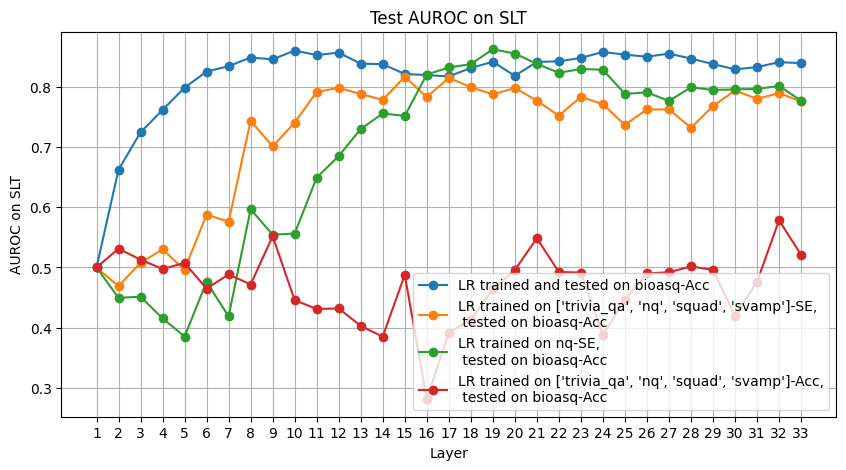

SLT: max AUROC for LR trained on bioasq's Acc and tested on bioasq's Acc:
	- 0.8606 at layer 10
	- 0.8583 at layer 24
	- 0.8572 at layer 12
	- 0.8556 at layer 27
	- 0.8538 at layer 25
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'svamp']'s SE and tested on bioasq's Acc:
	- 0.8172 at layer 15
	- 0.8152 at layer 17
	- 0.7998 at layer 18
	- 0.7986 at layer 12
	- 0.7985 at layer 20
SLT: max AUROC for LR trained on nq's SE and tested on bioasq's Acc:
	- 0.8628 at layer 19
	- 0.8557 at layer 20
	- 0.8385 at layer 21
	- 0.8379 at layer 18
	- 0.8326 at layer 17
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'svamp']'s Acc and tested on bioasq's Acc:
	- 0.5785 at layer 32
	- 0.5520 at layer 9
	- 0.5486 at layer 21
	- 0.5312 at layer 2
	- 0.5212 at layer 33
Testing on SVAMP's SLT-Acc


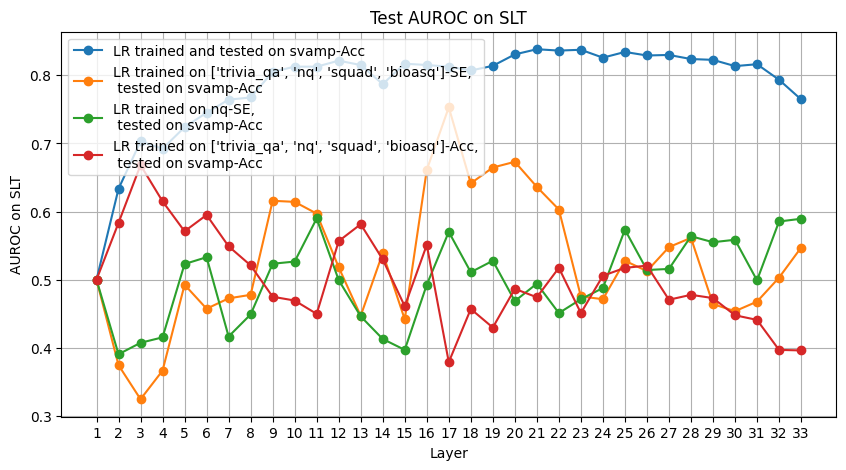

SLT: max AUROC for LR trained on svamp's Acc and tested on svamp's Acc:
	- 0.8383 at layer 21
	- 0.8375 at layer 23
	- 0.8363 at layer 22
	- 0.8343 at layer 25
	- 0.8307 at layer 20
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'bioasq']'s SE and tested on svamp's Acc:
	- 0.7531 at layer 17
	- 0.6731 at layer 20
	- 0.6647 at layer 19
	- 0.6611 at layer 16
	- 0.6415 at layer 18
SLT: max AUROC for LR trained on nq's SE and tested on svamp's Acc:
	- 0.5898 at layer 11
	- 0.5894 at layer 33
	- 0.5854 at layer 32
	- 0.5734 at layer 25
	- 0.5702 at layer 17
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'bioasq']'s Acc and tested on svamp's Acc:
	- 0.6683 at layer 3
	- 0.6150 at layer 4
	- 0.5950 at layer 6
	- 0.5834 at layer 2
	- 0.5814 at layer 13


In [269]:
test_one_on_n(D2)

Using probes trained on datasets SQUAD's SLT-SE to predict ['trivia_qa', 'nq', 'bioasq', 'svamp']'s SLT-SE
Testing on TRIVIA_QA's SLT-SE


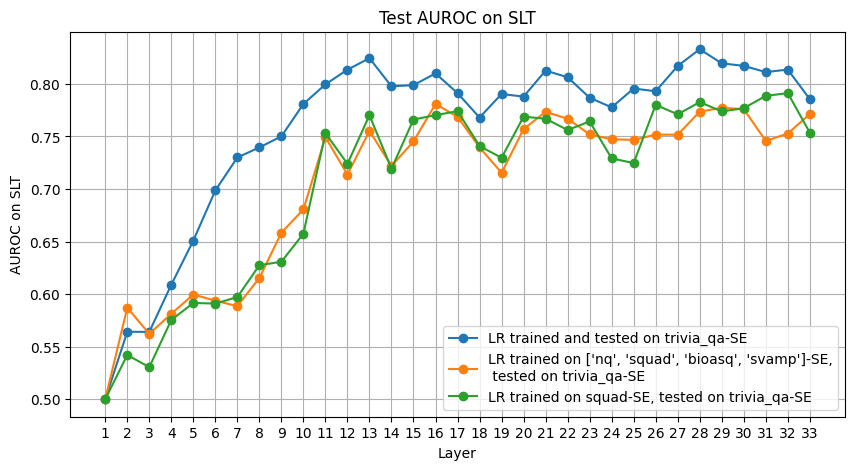

SLT: max AUROC for LR trained on trivia_qa's SE and tested on trivia_qa's SE:
	- 0.8330 at layer 28
	- 0.8245 at layer 13
	- 0.8196 at layer 29
	- 0.8172 at layer 30
	- 0.8171 at layer 27
SLT: max AUROC for LR trained on ['nq', 'squad', 'bioasq', 'svamp']'s SE and tested on trivia_qa's SE:
	- 0.7809 at layer 16
	- 0.7773 at layer 29
	- 0.7760 at layer 30
	- 0.7736 at layer 28
	- 0.7734 at layer 21
SLT: max AUROC for LR trained on squad's SE and tested on trivia_qa's SE:
	- 0.7912 at layer 32
	- 0.7886 at layer 31
	- 0.7827 at layer 28
	- 0.7801 at layer 26
	- 0.7769 at layer 30
Testing on NQ's SLT-SE


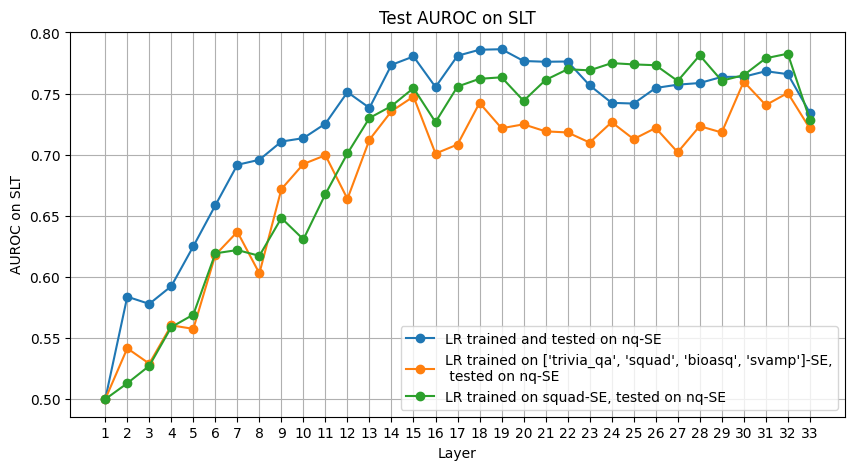

SLT: max AUROC for LR trained on nq's SE and tested on nq's SE:
	- 0.7863 at layer 19
	- 0.7859 at layer 18
	- 0.7810 at layer 17
	- 0.7804 at layer 15
	- 0.7767 at layer 20
SLT: max AUROC for LR trained on ['trivia_qa', 'squad', 'bioasq', 'svamp']'s SE and tested on nq's SE:
	- 0.7598 at layer 30
	- 0.7505 at layer 32
	- 0.7476 at layer 15
	- 0.7424 at layer 18
	- 0.7406 at layer 31
SLT: max AUROC for LR trained on squad's SE and tested on nq's SE:
	- 0.7827 at layer 32
	- 0.7813 at layer 28
	- 0.7789 at layer 31
	- 0.7749 at layer 24
	- 0.7739 at layer 25
Testing on BIOASQ's SLT-SE


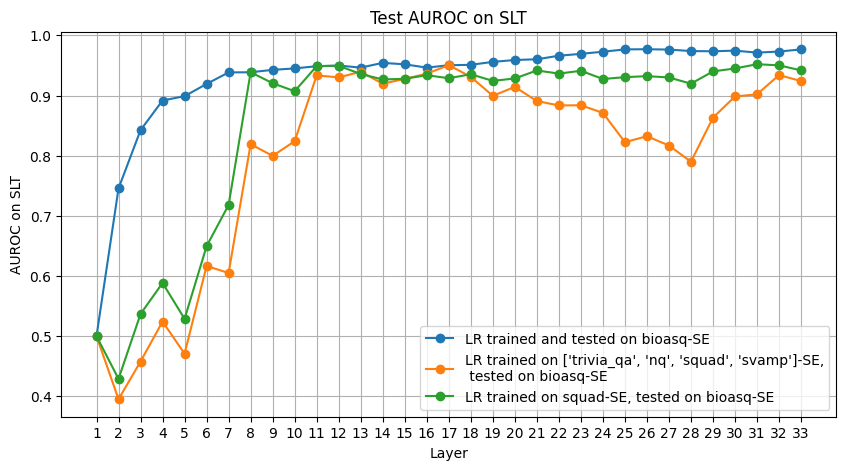

SLT: max AUROC for LR trained on bioasq's SE and tested on bioasq's SE:
	- 0.9769 at layer 26
	- 0.9766 at layer 25
	- 0.9766 at layer 33
	- 0.9763 at layer 27
	- 0.9746 at layer 30
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'svamp']'s SE and tested on bioasq's SE:
	- 0.9505 at layer 17
	- 0.9395 at layer 13
	- 0.9361 at layer 16
	- 0.9340 at layer 32
	- 0.9334 at layer 11
SLT: max AUROC for LR trained on squad's SE and tested on bioasq's SE:
	- 0.9520 at layer 31
	- 0.9501 at layer 32
	- 0.9493 at layer 12
	- 0.9489 at layer 11
	- 0.9449 at layer 30
Testing on SVAMP's SLT-SE


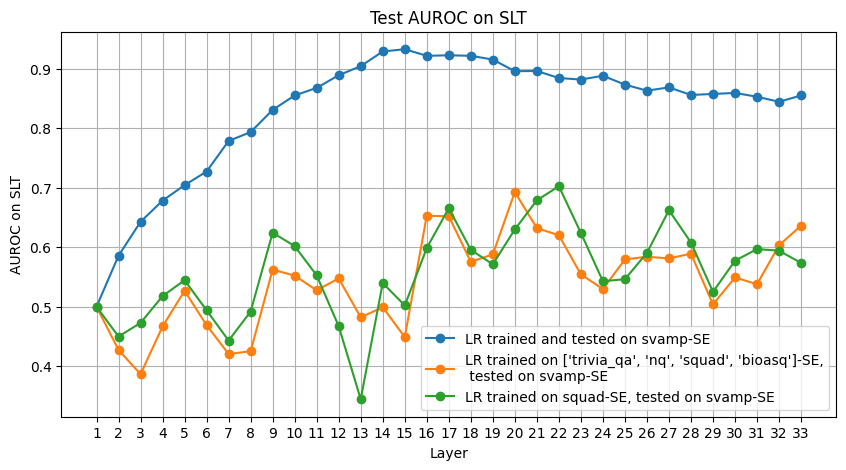

SLT: max AUROC for LR trained on svamp's SE and tested on svamp's SE:
	- 0.9325 at layer 15
	- 0.9287 at layer 14
	- 0.9223 at layer 17
	- 0.9215 at layer 16
	- 0.9215 at layer 18
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'bioasq']'s SE and tested on svamp's SE:
	- 0.6927 at layer 20
	- 0.6528 at layer 16
	- 0.6520 at layer 17
	- 0.6362 at layer 33
	- 0.6320 at layer 21
SLT: max AUROC for LR trained on squad's SE and tested on svamp's SE:
	- 0.7025 at layer 22
	- 0.6787 at layer 21
	- 0.6655 at layer 17
	- 0.6621 at layer 27
	- 0.6299 at layer 20


Using probes trained on datasets SQUAD's SLT-SE to predict ['trivia_qa', 'nq', 'bioasq', 'svamp']'s SLT-Acc
Testing on TRIVIA_QA's SLT-Acc


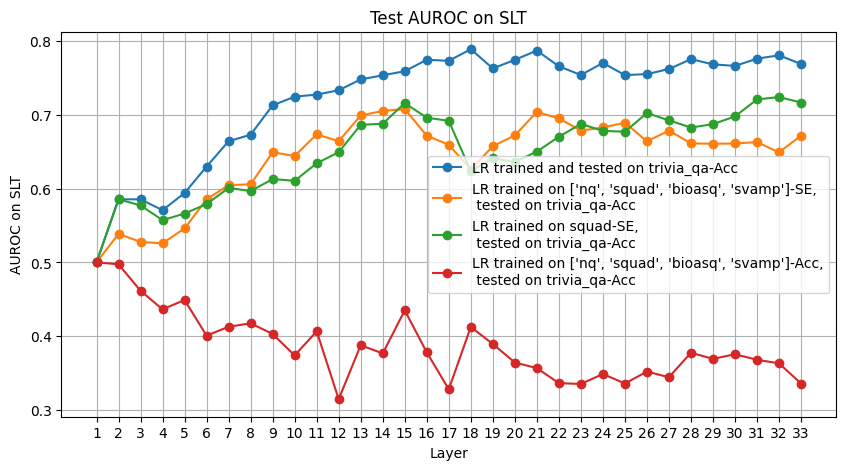

SLT: max AUROC for LR trained on trivia_qa's Acc and tested on trivia_qa's Acc:
	- 0.7886 at layer 18
	- 0.7868 at layer 21
	- 0.7804 at layer 32
	- 0.7758 at layer 31
	- 0.7751 at layer 28
SLT: max AUROC for LR trained on ['nq', 'squad', 'bioasq', 'svamp']'s SE and tested on trivia_qa's Acc:
	- 0.7075 at layer 15
	- 0.7051 at layer 14
	- 0.7037 at layer 21
	- 0.6989 at layer 13
	- 0.6949 at layer 22
SLT: max AUROC for LR trained on squad's SE and tested on trivia_qa's Acc:
	- 0.7238 at layer 32
	- 0.7206 at layer 31
	- 0.7164 at layer 33
	- 0.7156 at layer 15
	- 0.7022 at layer 26
SLT: max AUROC for LR trained on ['nq', 'squad', 'bioasq', 'svamp']'s Acc and tested on trivia_qa's Acc:
	- 0.5000 at layer 1
	- 0.4975 at layer 2
	- 0.4615 at layer 3
	- 0.4491 at layer 5
	- 0.4365 at layer 4
Testing on NQ's SLT-Acc


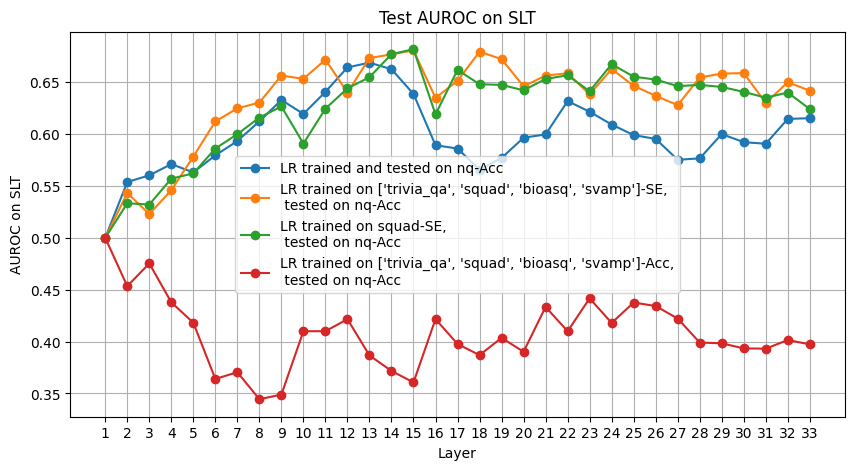

SLT: max AUROC for LR trained on nq's Acc and tested on nq's Acc:
	- 0.6689 at layer 13
	- 0.6643 at layer 12
	- 0.6626 at layer 14
	- 0.6408 at layer 11
	- 0.6387 at layer 15
SLT: max AUROC for LR trained on ['trivia_qa', 'squad', 'bioasq', 'svamp']'s SE and tested on nq's Acc:
	- 0.6807 at layer 15
	- 0.6795 at layer 18
	- 0.6769 at layer 14
	- 0.6733 at layer 13
	- 0.6723 at layer 19
SLT: max AUROC for LR trained on squad's SE and tested on nq's Acc:
	- 0.6819 at layer 15
	- 0.6771 at layer 14
	- 0.6674 at layer 24
	- 0.6619 at layer 17
	- 0.6567 at layer 22
SLT: max AUROC for LR trained on ['trivia_qa', 'squad', 'bioasq', 'svamp']'s Acc and tested on nq's Acc:
	- 0.5000 at layer 1
	- 0.4754 at layer 3
	- 0.4534 at layer 2
	- 0.4417 at layer 23
	- 0.4379 at layer 4
Testing on BIOASQ's SLT-Acc


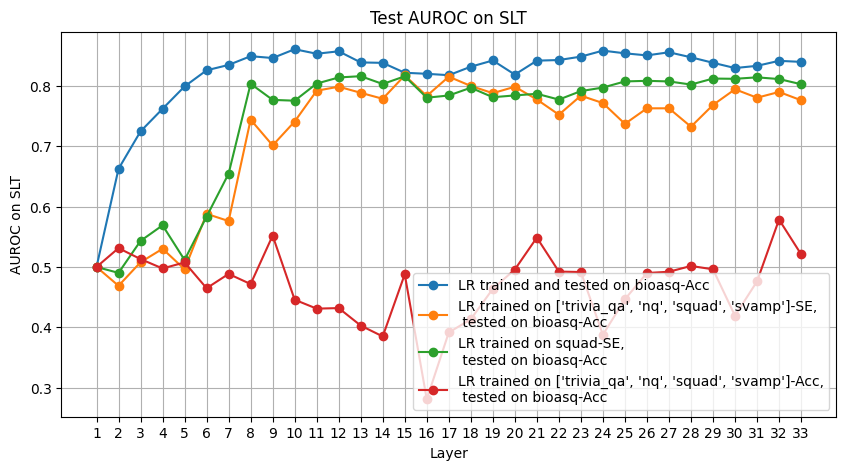

SLT: max AUROC for LR trained on bioasq's Acc and tested on bioasq's Acc:
	- 0.8606 at layer 10
	- 0.8583 at layer 24
	- 0.8572 at layer 12
	- 0.8556 at layer 27
	- 0.8538 at layer 25
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'svamp']'s SE and tested on bioasq's Acc:
	- 0.8172 at layer 15
	- 0.8152 at layer 17
	- 0.7998 at layer 18
	- 0.7986 at layer 12
	- 0.7985 at layer 20
SLT: max AUROC for LR trained on squad's SE and tested on bioasq's Acc:
	- 0.8160 at layer 13
	- 0.8158 at layer 15
	- 0.8141 at layer 31
	- 0.8138 at layer 12
	- 0.8120 at layer 29
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'svamp']'s Acc and tested on bioasq's Acc:
	- 0.5785 at layer 32
	- 0.5520 at layer 9
	- 0.5486 at layer 21
	- 0.5312 at layer 2
	- 0.5212 at layer 33
Testing on SVAMP's SLT-Acc


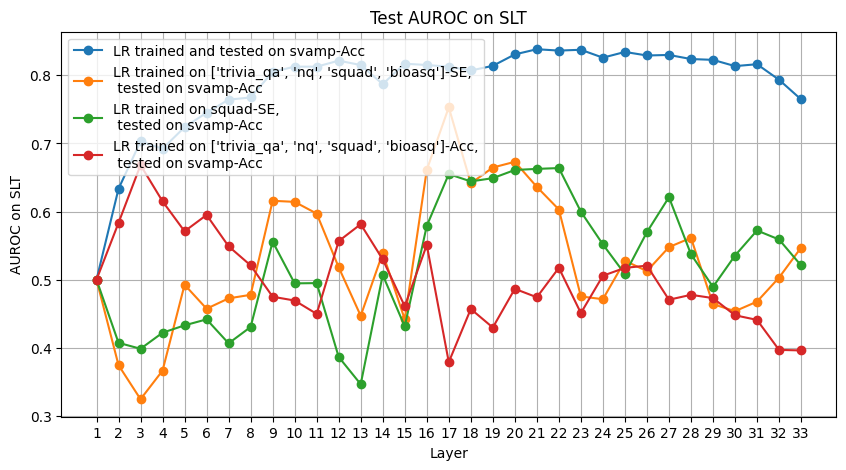

SLT: max AUROC for LR trained on svamp's Acc and tested on svamp's Acc:
	- 0.8383 at layer 21
	- 0.8375 at layer 23
	- 0.8363 at layer 22
	- 0.8343 at layer 25
	- 0.8307 at layer 20
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'bioasq']'s SE and tested on svamp's Acc:
	- 0.7531 at layer 17
	- 0.6731 at layer 20
	- 0.6647 at layer 19
	- 0.6611 at layer 16
	- 0.6415 at layer 18
SLT: max AUROC for LR trained on squad's SE and tested on svamp's Acc:
	- 0.6639 at layer 22
	- 0.6627 at layer 21
	- 0.6611 at layer 20
	- 0.6551 at layer 17
	- 0.6491 at layer 19
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'bioasq']'s Acc and tested on svamp's Acc:
	- 0.6683 at layer 3
	- 0.6150 at layer 4
	- 0.5950 at layer 6
	- 0.5834 at layer 2
	- 0.5814 at layer 13


In [270]:
test_one_on_n(D3)

Using probes trained on datasets BIOASQ's SLT-SE to predict ['trivia_qa', 'nq', 'squad', 'svamp']'s SLT-SE
Testing on TRIVIA_QA's SLT-SE


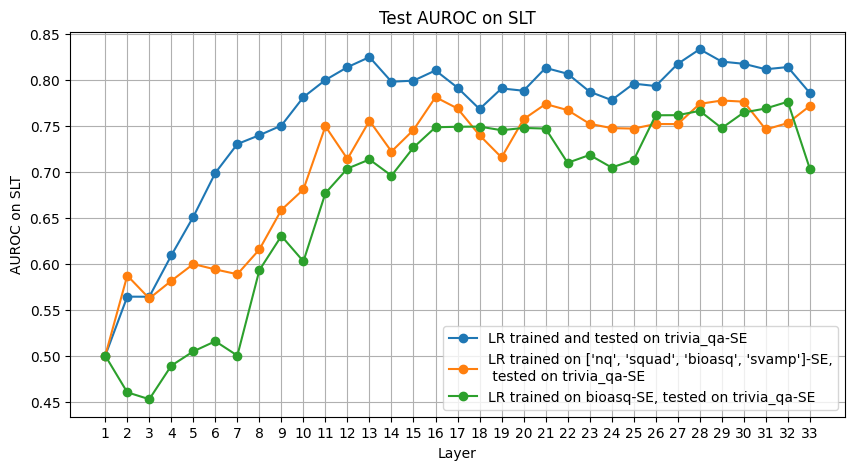

SLT: max AUROC for LR trained on trivia_qa's SE and tested on trivia_qa's SE:
	- 0.8330 at layer 28
	- 0.8245 at layer 13
	- 0.8196 at layer 29
	- 0.8172 at layer 30
	- 0.8171 at layer 27
SLT: max AUROC for LR trained on ['nq', 'squad', 'bioasq', 'svamp']'s SE and tested on trivia_qa's SE:
	- 0.7809 at layer 16
	- 0.7773 at layer 29
	- 0.7760 at layer 30
	- 0.7736 at layer 28
	- 0.7734 at layer 21
SLT: max AUROC for LR trained on bioasq's SE and tested on trivia_qa's SE:
	- 0.7759 at layer 32
	- 0.7686 at layer 31
	- 0.7660 at layer 28
	- 0.7643 at layer 30
	- 0.7614 at layer 27
Testing on NQ's SLT-SE


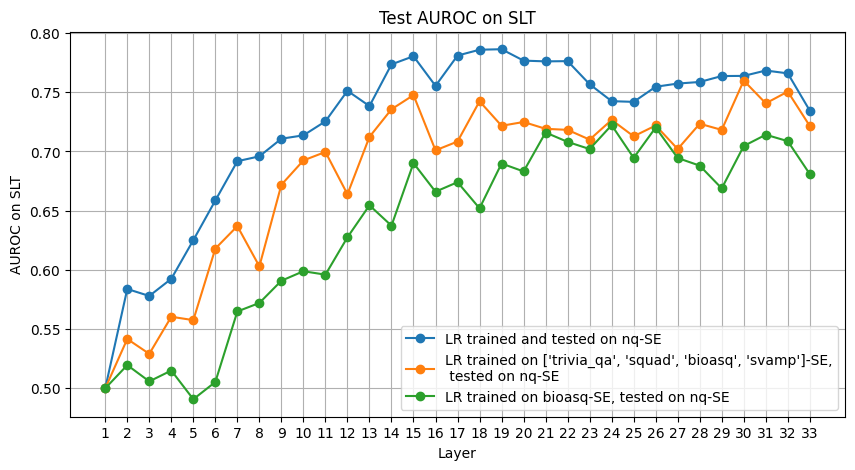

SLT: max AUROC for LR trained on nq's SE and tested on nq's SE:
	- 0.7863 at layer 19
	- 0.7859 at layer 18
	- 0.7810 at layer 17
	- 0.7804 at layer 15
	- 0.7767 at layer 20
SLT: max AUROC for LR trained on ['trivia_qa', 'squad', 'bioasq', 'svamp']'s SE and tested on nq's SE:
	- 0.7598 at layer 30
	- 0.7505 at layer 32
	- 0.7476 at layer 15
	- 0.7424 at layer 18
	- 0.7406 at layer 31
SLT: max AUROC for LR trained on bioasq's SE and tested on nq's SE:
	- 0.7222 at layer 24
	- 0.7202 at layer 26
	- 0.7160 at layer 21
	- 0.7141 at layer 31
	- 0.7087 at layer 32
Testing on SQUAD's SLT-SE


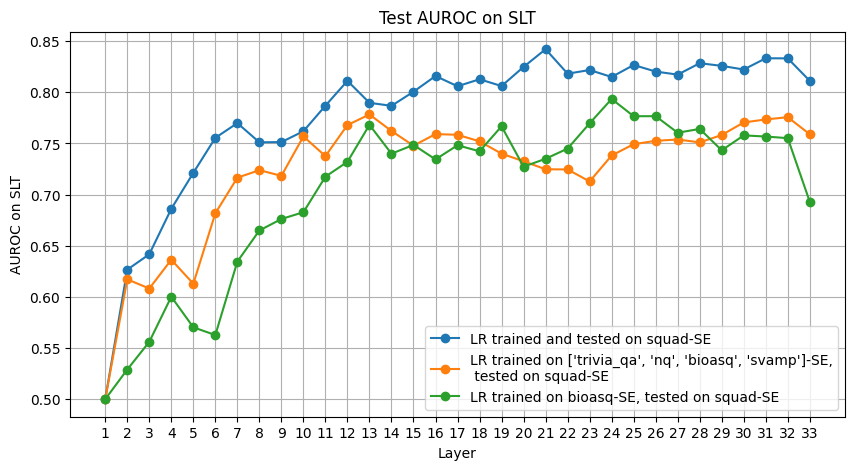

SLT: max AUROC for LR trained on squad's SE and tested on squad's SE:
	- 0.8421 at layer 21
	- 0.8332 at layer 31
	- 0.8331 at layer 32
	- 0.8284 at layer 28
	- 0.8266 at layer 25
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'bioasq', 'svamp']'s SE and tested on squad's SE:
	- 0.7783 at layer 13
	- 0.7756 at layer 32
	- 0.7734 at layer 31
	- 0.7705 at layer 30
	- 0.7680 at layer 12
SLT: max AUROC for LR trained on bioasq's SE and tested on squad's SE:
	- 0.7934 at layer 24
	- 0.7766 at layer 26
	- 0.7766 at layer 25
	- 0.7696 at layer 23
	- 0.7681 at layer 13
Testing on SVAMP's SLT-SE


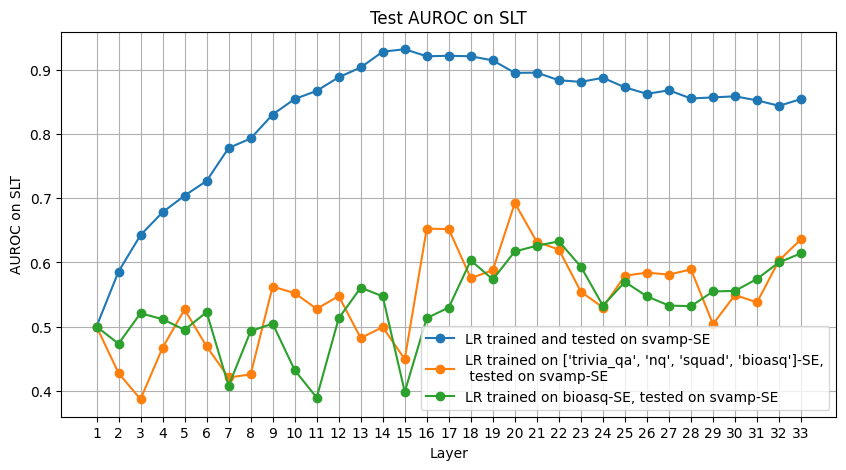

SLT: max AUROC for LR trained on svamp's SE and tested on svamp's SE:
	- 0.9325 at layer 15
	- 0.9287 at layer 14
	- 0.9223 at layer 17
	- 0.9215 at layer 16
	- 0.9215 at layer 18
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'bioasq']'s SE and tested on svamp's SE:
	- 0.6927 at layer 20
	- 0.6528 at layer 16
	- 0.6520 at layer 17
	- 0.6362 at layer 33
	- 0.6320 at layer 21
SLT: max AUROC for LR trained on bioasq's SE and tested on svamp's SE:
	- 0.6329 at layer 22
	- 0.6261 at layer 21
	- 0.6171 at layer 20
	- 0.6142 at layer 33
	- 0.6031 at layer 18


Using probes trained on datasets BIOASQ's SLT-SE to predict ['trivia_qa', 'nq', 'squad', 'svamp']'s SLT-Acc
Testing on TRIVIA_QA's SLT-Acc


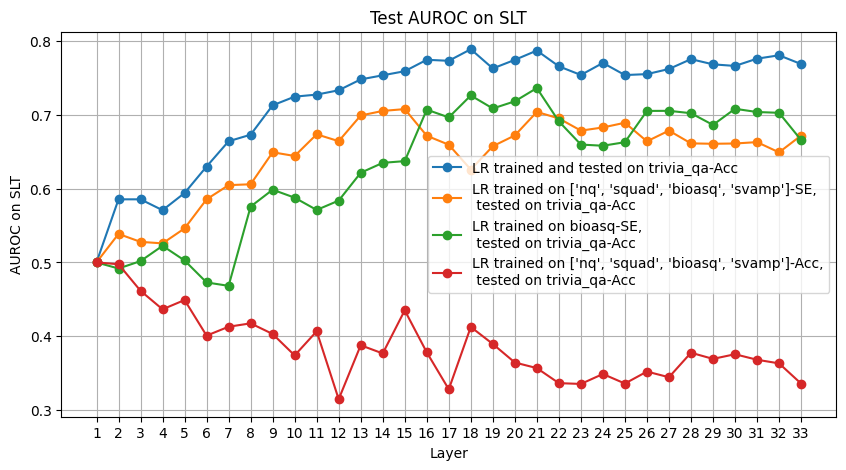

SLT: max AUROC for LR trained on trivia_qa's Acc and tested on trivia_qa's Acc:
	- 0.7886 at layer 18
	- 0.7868 at layer 21
	- 0.7804 at layer 32
	- 0.7758 at layer 31
	- 0.7751 at layer 28
SLT: max AUROC for LR trained on ['nq', 'squad', 'bioasq', 'svamp']'s SE and tested on trivia_qa's Acc:
	- 0.7075 at layer 15
	- 0.7051 at layer 14
	- 0.7037 at layer 21
	- 0.6989 at layer 13
	- 0.6949 at layer 22
SLT: max AUROC for LR trained on bioasq's SE and tested on trivia_qa's Acc:
	- 0.7360 at layer 21
	- 0.7260 at layer 18
	- 0.7181 at layer 20
	- 0.7084 at layer 19
	- 0.7079 at layer 30
SLT: max AUROC for LR trained on ['nq', 'squad', 'bioasq', 'svamp']'s Acc and tested on trivia_qa's Acc:
	- 0.5000 at layer 1
	- 0.4975 at layer 2
	- 0.4615 at layer 3
	- 0.4491 at layer 5
	- 0.4365 at layer 4
Testing on NQ's SLT-Acc


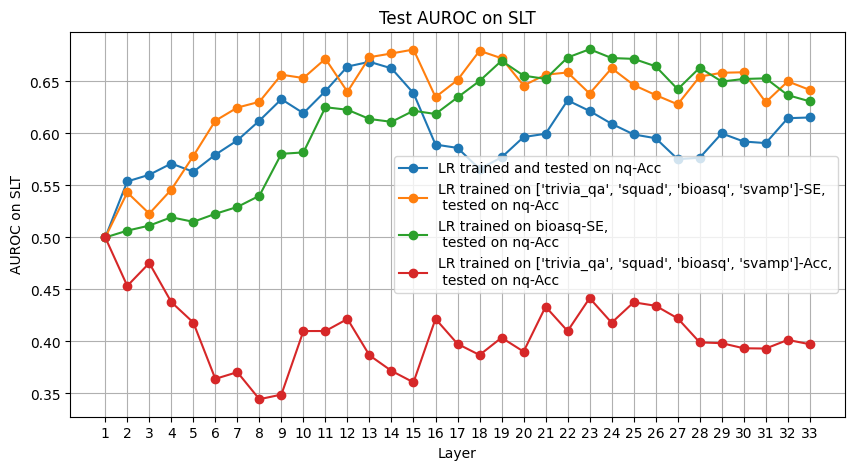

SLT: max AUROC for LR trained on nq's Acc and tested on nq's Acc:
	- 0.6689 at layer 13
	- 0.6643 at layer 12
	- 0.6626 at layer 14
	- 0.6408 at layer 11
	- 0.6387 at layer 15
SLT: max AUROC for LR trained on ['trivia_qa', 'squad', 'bioasq', 'svamp']'s SE and tested on nq's Acc:
	- 0.6807 at layer 15
	- 0.6795 at layer 18
	- 0.6769 at layer 14
	- 0.6733 at layer 13
	- 0.6723 at layer 19
SLT: max AUROC for LR trained on bioasq's SE and tested on nq's Acc:
	- 0.6810 at layer 23
	- 0.6730 at layer 22
	- 0.6725 at layer 24
	- 0.6717 at layer 25
	- 0.6699 at layer 19
SLT: max AUROC for LR trained on ['trivia_qa', 'squad', 'bioasq', 'svamp']'s Acc and tested on nq's Acc:
	- 0.5000 at layer 1
	- 0.4754 at layer 3
	- 0.4534 at layer 2
	- 0.4417 at layer 23
	- 0.4379 at layer 4
Testing on SQUAD's SLT-Acc


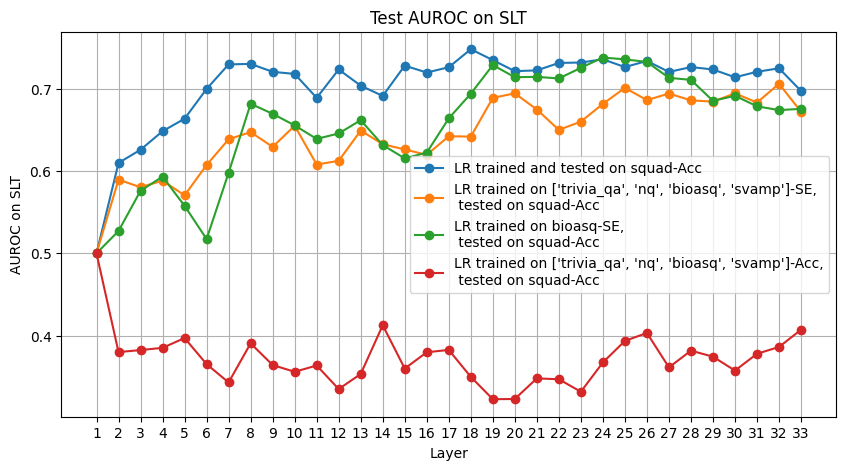

SLT: max AUROC for LR trained on squad's Acc and tested on squad's Acc:
	- 0.7479 at layer 18
	- 0.7356 at layer 24
	- 0.7347 at layer 19
	- 0.7337 at layer 26
	- 0.7318 at layer 23
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'bioasq', 'svamp']'s SE and tested on squad's Acc:
	- 0.7060 at layer 32
	- 0.7009 at layer 25
	- 0.6943 at layer 20
	- 0.6943 at layer 30
	- 0.6941 at layer 27
SLT: max AUROC for LR trained on bioasq's SE and tested on squad's Acc:
	- 0.7378 at layer 24
	- 0.7356 at layer 25
	- 0.7325 at layer 26
	- 0.7286 at layer 19
	- 0.7253 at layer 23
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'bioasq', 'svamp']'s Acc and tested on squad's Acc:
	- 0.5000 at layer 1
	- 0.4127 at layer 14
	- 0.4072 at layer 33
	- 0.4033 at layer 26
	- 0.3971 at layer 5
Testing on SVAMP's SLT-Acc


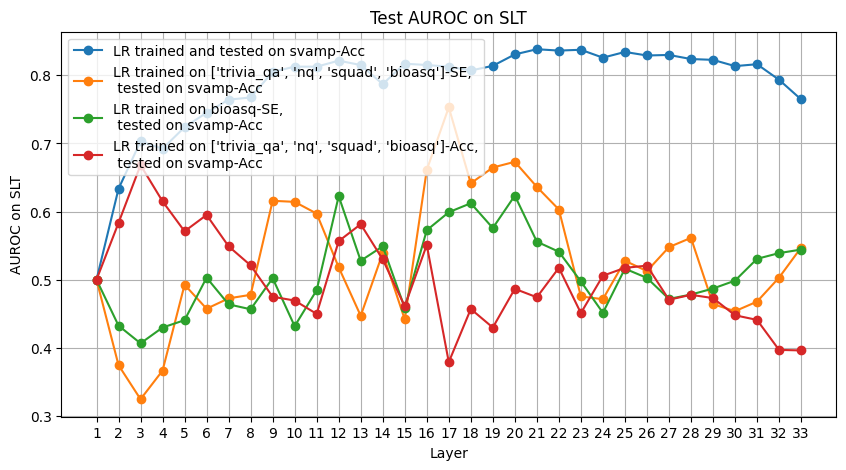

SLT: max AUROC for LR trained on svamp's Acc and tested on svamp's Acc:
	- 0.8383 at layer 21
	- 0.8375 at layer 23
	- 0.8363 at layer 22
	- 0.8343 at layer 25
	- 0.8307 at layer 20
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'bioasq']'s SE and tested on svamp's Acc:
	- 0.7531 at layer 17
	- 0.6731 at layer 20
	- 0.6647 at layer 19
	- 0.6611 at layer 16
	- 0.6415 at layer 18
SLT: max AUROC for LR trained on bioasq's SE and tested on svamp's Acc:
	- 0.6234 at layer 20
	- 0.6226 at layer 12
	- 0.6122 at layer 18
	- 0.5990 at layer 17
	- 0.5758 at layer 19
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'bioasq']'s Acc and tested on svamp's Acc:
	- 0.6683 at layer 3
	- 0.6150 at layer 4
	- 0.5950 at layer 6
	- 0.5834 at layer 2
	- 0.5814 at layer 13


In [271]:
test_one_on_n(D4)

Using probes trained on datasets SVAMP's SLT-SE to predict ['trivia_qa', 'nq', 'squad', 'bioasq']'s SLT-SE
Testing on TRIVIA_QA's SLT-SE


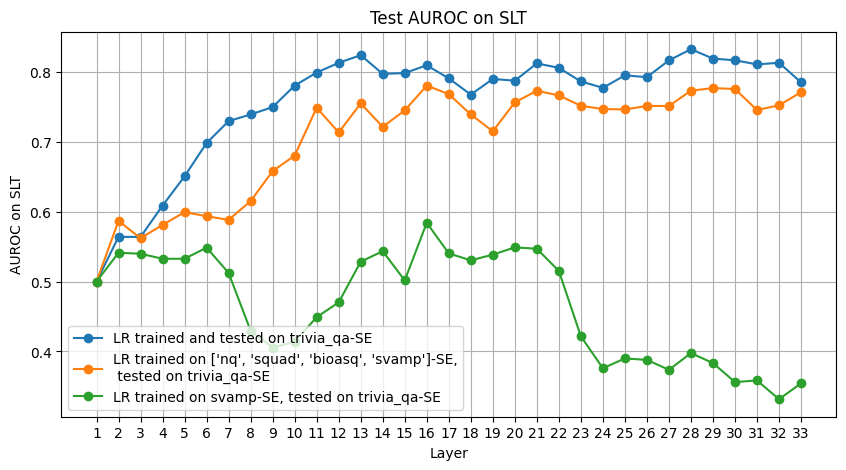

SLT: max AUROC for LR trained on trivia_qa's SE and tested on trivia_qa's SE:
	- 0.8330 at layer 28
	- 0.8245 at layer 13
	- 0.8196 at layer 29
	- 0.8172 at layer 30
	- 0.8171 at layer 27
SLT: max AUROC for LR trained on ['nq', 'squad', 'bioasq', 'svamp']'s SE and tested on trivia_qa's SE:
	- 0.7809 at layer 16
	- 0.7773 at layer 29
	- 0.7760 at layer 30
	- 0.7736 at layer 28
	- 0.7734 at layer 21
SLT: max AUROC for LR trained on svamp's SE and tested on trivia_qa's SE:
	- 0.5844 at layer 16
	- 0.5491 at layer 20
	- 0.5488 at layer 6
	- 0.5472 at layer 21
	- 0.5436 at layer 14
Testing on NQ's SLT-SE


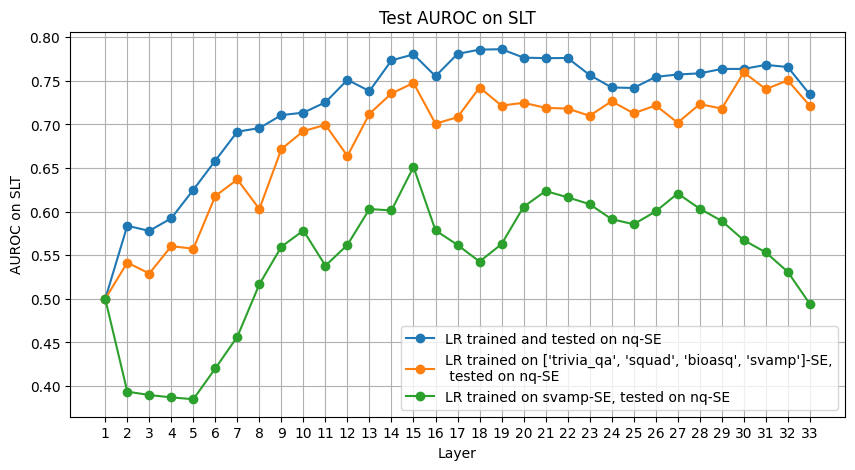

SLT: max AUROC for LR trained on nq's SE and tested on nq's SE:
	- 0.7863 at layer 19
	- 0.7859 at layer 18
	- 0.7810 at layer 17
	- 0.7804 at layer 15
	- 0.7767 at layer 20
SLT: max AUROC for LR trained on ['trivia_qa', 'squad', 'bioasq', 'svamp']'s SE and tested on nq's SE:
	- 0.7598 at layer 30
	- 0.7505 at layer 32
	- 0.7476 at layer 15
	- 0.7424 at layer 18
	- 0.7406 at layer 31
SLT: max AUROC for LR trained on svamp's SE and tested on nq's SE:
	- 0.6513 at layer 15
	- 0.6237 at layer 21
	- 0.6208 at layer 27
	- 0.6165 at layer 22
	- 0.6086 at layer 23
Testing on SQUAD's SLT-SE


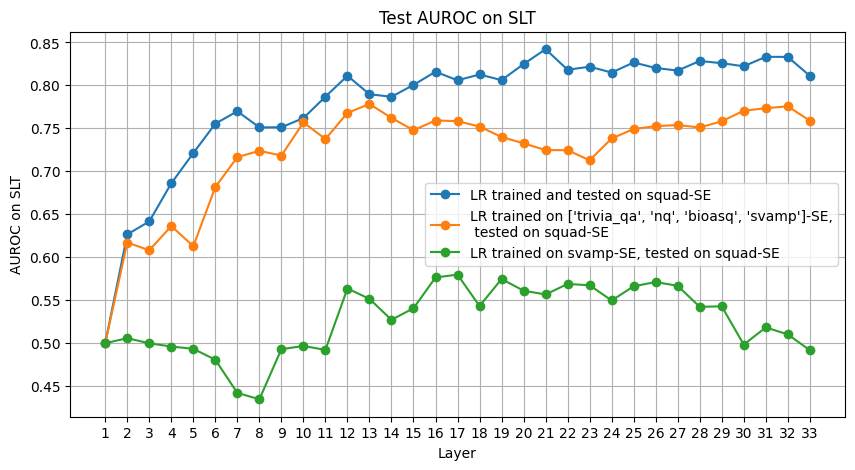

SLT: max AUROC for LR trained on squad's SE and tested on squad's SE:
	- 0.8421 at layer 21
	- 0.8332 at layer 31
	- 0.8331 at layer 32
	- 0.8284 at layer 28
	- 0.8266 at layer 25
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'bioasq', 'svamp']'s SE and tested on squad's SE:
	- 0.7783 at layer 13
	- 0.7756 at layer 32
	- 0.7734 at layer 31
	- 0.7705 at layer 30
	- 0.7680 at layer 12
SLT: max AUROC for LR trained on svamp's SE and tested on squad's SE:
	- 0.5798 at layer 17
	- 0.5765 at layer 16
	- 0.5747 at layer 19
	- 0.5712 at layer 26
	- 0.5690 at layer 22
Testing on BIOASQ's SLT-SE


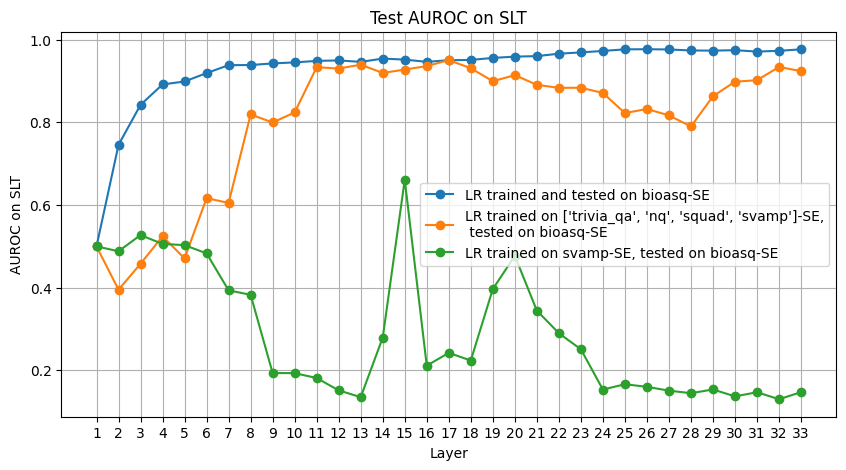

SLT: max AUROC for LR trained on bioasq's SE and tested on bioasq's SE:
	- 0.9769 at layer 26
	- 0.9766 at layer 25
	- 0.9766 at layer 33
	- 0.9763 at layer 27
	- 0.9746 at layer 30
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'svamp']'s SE and tested on bioasq's SE:
	- 0.9505 at layer 17
	- 0.9395 at layer 13
	- 0.9361 at layer 16
	- 0.9340 at layer 32
	- 0.9334 at layer 11
SLT: max AUROC for LR trained on svamp's SE and tested on bioasq's SE:
	- 0.6611 at layer 15
	- 0.5273 at layer 3
	- 0.5059 at layer 4
	- 0.5030 at layer 5
	- 0.5000 at layer 1


Using probes trained on datasets SVAMP's SLT-SE to predict ['trivia_qa', 'nq', 'squad', 'bioasq']'s SLT-Acc
Testing on TRIVIA_QA's SLT-Acc


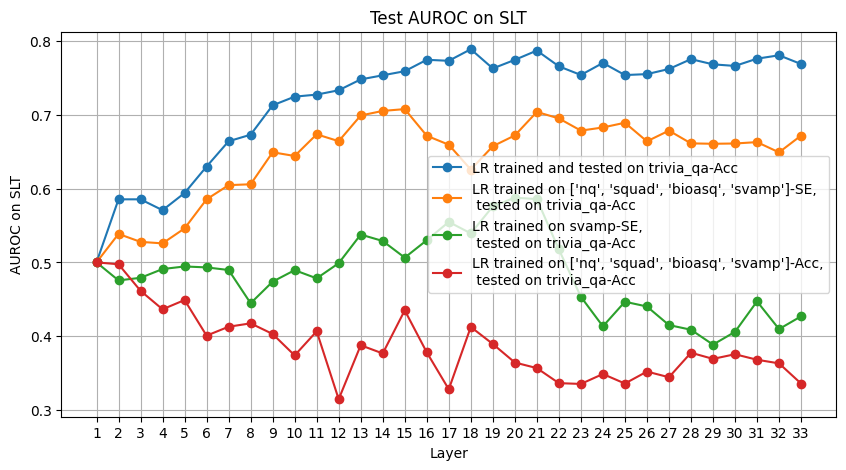

SLT: max AUROC for LR trained on trivia_qa's Acc and tested on trivia_qa's Acc:
	- 0.7886 at layer 18
	- 0.7868 at layer 21
	- 0.7804 at layer 32
	- 0.7758 at layer 31
	- 0.7751 at layer 28
SLT: max AUROC for LR trained on ['nq', 'squad', 'bioasq', 'svamp']'s SE and tested on trivia_qa's Acc:
	- 0.7075 at layer 15
	- 0.7051 at layer 14
	- 0.7037 at layer 21
	- 0.6989 at layer 13
	- 0.6949 at layer 22
SLT: max AUROC for LR trained on svamp's SE and tested on trivia_qa's Acc:
	- 0.5876 at layer 20
	- 0.5857 at layer 21
	- 0.5758 at layer 19
	- 0.5548 at layer 17
	- 0.5393 at layer 18
SLT: max AUROC for LR trained on ['nq', 'squad', 'bioasq', 'svamp']'s Acc and tested on trivia_qa's Acc:
	- 0.5000 at layer 1
	- 0.4975 at layer 2
	- 0.4615 at layer 3
	- 0.4491 at layer 5
	- 0.4365 at layer 4
Testing on NQ's SLT-Acc


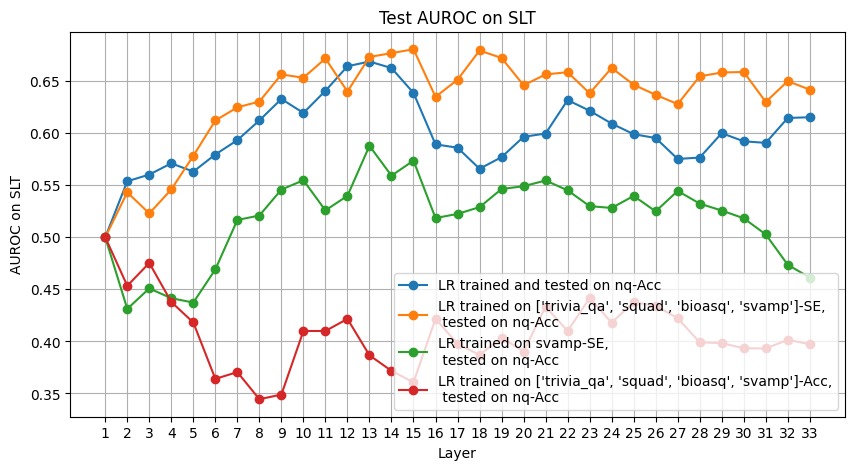

SLT: max AUROC for LR trained on nq's Acc and tested on nq's Acc:
	- 0.6689 at layer 13
	- 0.6643 at layer 12
	- 0.6626 at layer 14
	- 0.6408 at layer 11
	- 0.6387 at layer 15
SLT: max AUROC for LR trained on ['trivia_qa', 'squad', 'bioasq', 'svamp']'s SE and tested on nq's Acc:
	- 0.6807 at layer 15
	- 0.6795 at layer 18
	- 0.6769 at layer 14
	- 0.6733 at layer 13
	- 0.6723 at layer 19
SLT: max AUROC for LR trained on svamp's SE and tested on nq's Acc:
	- 0.5879 at layer 13
	- 0.5737 at layer 15
	- 0.5592 at layer 14
	- 0.5548 at layer 10
	- 0.5546 at layer 21
SLT: max AUROC for LR trained on ['trivia_qa', 'squad', 'bioasq', 'svamp']'s Acc and tested on nq's Acc:
	- 0.5000 at layer 1
	- 0.4754 at layer 3
	- 0.4534 at layer 2
	- 0.4417 at layer 23
	- 0.4379 at layer 4
Testing on SQUAD's SLT-Acc


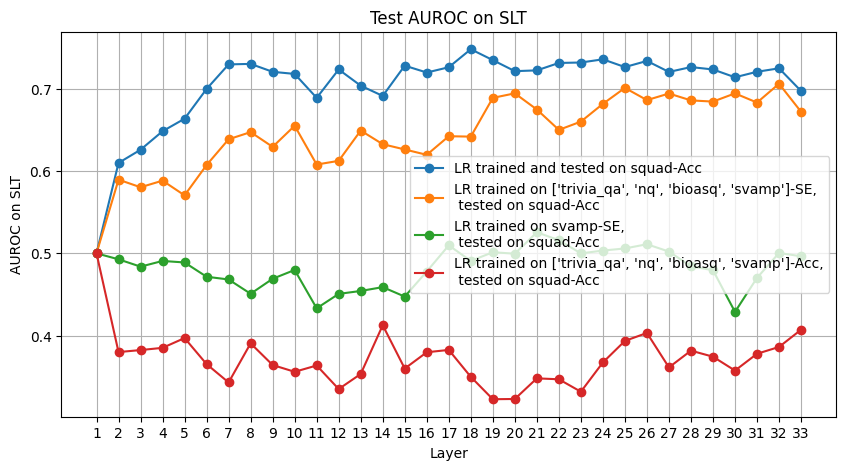

SLT: max AUROC for LR trained on squad's Acc and tested on squad's Acc:
	- 0.7479 at layer 18
	- 0.7356 at layer 24
	- 0.7347 at layer 19
	- 0.7337 at layer 26
	- 0.7318 at layer 23
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'bioasq', 'svamp']'s SE and tested on squad's Acc:
	- 0.7060 at layer 32
	- 0.7009 at layer 25
	- 0.6943 at layer 20
	- 0.6943 at layer 30
	- 0.6941 at layer 27
SLT: max AUROC for LR trained on svamp's SE and tested on squad's Acc:
	- 0.5256 at layer 21
	- 0.5160 at layer 22
	- 0.5110 at layer 26
	- 0.5097 at layer 17
	- 0.5059 at layer 25
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'bioasq', 'svamp']'s Acc and tested on squad's Acc:
	- 0.5000 at layer 1
	- 0.4127 at layer 14
	- 0.4072 at layer 33
	- 0.4033 at layer 26
	- 0.3971 at layer 5
Testing on BIOASQ's SLT-Acc


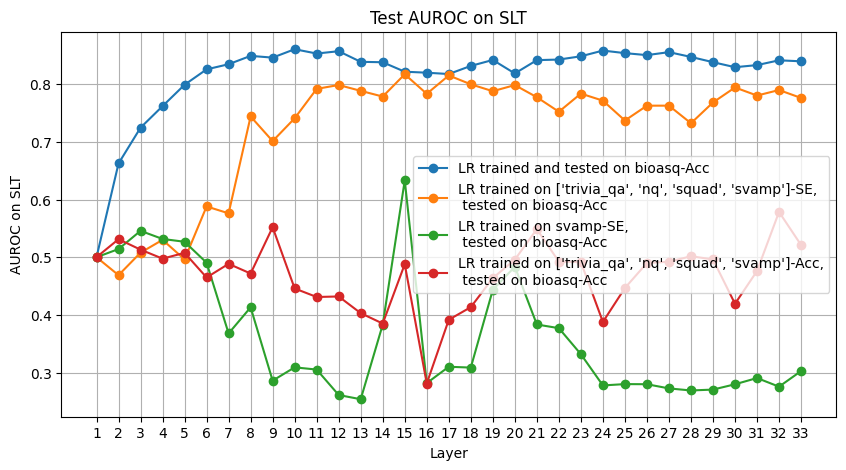

SLT: max AUROC for LR trained on bioasq's Acc and tested on bioasq's Acc:
	- 0.8606 at layer 10
	- 0.8583 at layer 24
	- 0.8572 at layer 12
	- 0.8556 at layer 27
	- 0.8538 at layer 25
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'svamp']'s SE and tested on bioasq's Acc:
	- 0.8172 at layer 15
	- 0.8152 at layer 17
	- 0.7998 at layer 18
	- 0.7986 at layer 12
	- 0.7985 at layer 20
SLT: max AUROC for LR trained on svamp's SE and tested on bioasq's Acc:
	- 0.6332 at layer 15
	- 0.5457 at layer 3
	- 0.5316 at layer 4
	- 0.5268 at layer 5
	- 0.5141 at layer 2
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'svamp']'s Acc and tested on bioasq's Acc:
	- 0.5785 at layer 32
	- 0.5520 at layer 9
	- 0.5486 at layer 21
	- 0.5312 at layer 2
	- 0.5212 at layer 33


In [272]:
test_one_on_n(D5)

SVAMP dataset is really weak in generalization.

## Save dataset metrics

In [285]:
# save dataset fields to pickle
import pickle
from datetime import datetime

Ds_save = ()
excl_attrs = ['tbg_dataset', 'slt_dataset', 'entropy', 'ca_entropy', 'accuracies', 'b_entropy'] 

for D in Ds:
    D_save = {key: value for key, value in vars(D).items() if key not in excl_attrs}
    Ds_save += (D_save,)

path = "~/Downloads/oatml/semantic_uncertainty/latent_probe_notebooks/metrics"
full_path = os.path.expanduser(path)
os.makedirs(full_path, exist_ok=True)
time_now = datetime.now().strftime("%Y%m%d-%H%M%S")

f = open(f'{full_path}/{time_now}_{"_".join([D.name + "-" + str(D.total_size) for D in Ds])}.pkl', 'wb')
pickle.dump(Ds_save, f)
f.close()